# Imports

In [1]:
import math
import datasets
import re

import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, OrderedDict

from copy import deepcopy
from string import punctuation
from random import randint
import numpy as np
from PIL import Image
from git import Repo
from pathlib import Path
from nltk.stem.snowball import SnowballStemmer
from collections.abc import MutableMapping
import collections
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from keras.utils import to_categorical
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import LSTM, Dense, GRU, Embedding
from keras.callbacks import EarlyStopping, ModelCheckpoint

import nltk
from nltk.lm.preprocessing import pad_both_ends
from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.lm.preprocessing import flatten
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
from nltk import ngrams
from nltk.lm import MLE
from nltk.lm import Laplace
from nltk.lm import KneserNeyInterpolated
from nltk.lm import AbsoluteDiscountingInterpolated
from nltk.lm import StupidBackoff
from nltk.lm import NgramCounter
from nltk.lm import Vocabulary
from nltk.corpus import stopwords
from nltk.util import ngrams
from nltk.util import bigrams
from nltk.util import trigrams
from nltk.util import pad_sequence

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torcheval.metrics.text import Perplexity
from torch.nn import LSTM, GRU
import torch
import torch.nn as nn
import torch.optim as optim
from torch import LongTensor

from tqdm import tqdm

import pyarrow as pa
import pyarrow.dataset as ds
from datasets import Dataset

from scipy import stats
from scipy.stats import mannwhitneyu

collections.MutableMapping = MutableMapping

nltk.download('punkt')
nltk.download('stopwords')

/Users/kylesullivan/Documents/Educational/School/Graduate/UPenn/Courses/CIS 530/Project/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/kylesullivan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kylesullivan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
cities_df = pd.read_csv('/Users/kylesullivan/Documents/Educational/School/Graduate/UPenn/Courses/CIS 530/Project/Data/names_locations/world-cities.csv')
names_df = pd.read_csv('/Users/kylesullivan/Documents/Educational/School/Graduate/UPenn/Courses/CIS 530/Project/Data/names_locations/players.csv')
states_df = pd.read_csv('/Users/kylesullivan/Documents/Educational/School/Graduate/UPenn/Courses/CIS 530/Project/Data/names_locations/states.csv')
state_names_df = pd.read_csv('/Users/kylesullivan/Documents/Educational/School/Graduate/UPenn/Courses/CIS 530/Project/Data/names_locations/StateNames.csv')
nat_names_df = pd.read_csv('/Users/kylesullivan/Documents/Educational/School/Graduate/UPenn/Courses/CIS 530/Project/Data/names_locations/NationalNames.csv')
tok_all_text = pd.read_csv('/Users/kylesullivan/Documents/Educational/School/Graduate/UPenn/Courses/CIS 530/Project/Data/tennis_data/tok_all_text.csv',
                           low_memory=False)

In [3]:
questions_df = pd.read_json('/Users/kylesullivan/Documents/Educational/School/Graduate/UPenn/Courses/CIS 530/Project/Data/tennis_data/questions_matchinfo.json', orient='index')
commentaries_df = pd.read_json('/Users/kylesullivan/Documents/Educational/School/Graduate/UPenn/Courses/CIS 530/Project/Data/tennis_data/text_commentaries.json')
transcripts_df = pd.read_json('/Users/kylesullivan/Documents/Educational/School/Graduate/UPenn/Courses/CIS 530/Project/Data/tennis_data/transcripts_matchinfo.json', orient='index')

# Helper Functions / Background Computations

In [4]:
def calc_perp(
    male_perplexities: list[float], female_perplexities: list[float]
) -> float:
    """
    Calculate the statistical significance of the difference in perplexity scores
    between male and female datasets using the Mann-Whitney U test.

    Args:
        male_perplexities (list[float]): A list of perplexity scores for the male group.
        female_perplexities (list[float]): A list of perplexity scores for the female group.

    Returns:
        float: The p-value from the Mann-Whitney U test indicating the statistical significance
               of the difference in perplexity scores.
    """
    # Perform Mann-Whitney U test
    statistic, p_value = mannwhitneyu(
        male_perplexities, female_perplexities, alternative="two-sided"
    )

    # Check for statistical significance
    alpha = 0.05
    larger_perp = (
        "(male perplexity is greater)"
        if np.mean(male_perplexities) >= np.mean(female_perplexities)
        else "(female perplexity is greater)"
    )

    # Print the results
    print("Male Perplexity:          ", round(np.mean(male_perplexities), 1))
    print("Female Perplexity:        ", round(np.mean(female_perplexities), 1))
    print("P-value:                  ", round(p_value, 3))
    print("Statistically Significant:", p_value < alpha, end=" ")

    if p_value < alpha:
        print(larger_perp)
    else:
        print()

    return p_value

In [5]:
def get_xanew(
    root: Path = Path.home() / "data/X-ANEW", 
    url: str = "https://github.com/JULIELab/X-ANEW.git"
) -> pd.DataFrame:
    """
    Downloads the X-ANEW dataset from GitHub if it does not already exist 
    in the specified directory and returns a DataFrame containing word 
    valence, arousal, and dominance scores.

    Args:
        root (Path): The directory where the dataset will be stored. 
                     Defaults to a folder named 'X-ANEW' in the user's home directory.
        url (str): The URL from which to download the dataset if it does not exist. 
                    Defaults to the GitHub repository of the X-ANEW dataset.

    Returns:
        pd.DataFrame: A pandas DataFrame containing the columns 'word', 'valence', 
                       'arousal', and 'dominance', indexed by 'word'.
    """
    
    # Check if the dataset directory exists
    if not root.is_dir():
        root.mkdir()  # Create the directory if it does not exist
        print("Downloading the dataset from github...")
        Repo.clone_from(url, str(root))  # Clone the repository from GitHub
    else:
        print("Dataset already exists. Skipping download.")

    # Load the ratings CSV file into a DataFrame
    csv = str(root / "Ratings_Warriner_et_al.csv")
    df = pd.read_csv(csv, index_col=0)
    df = df[["Word", "V.Mean.Sum", "A.Mean.Sum", "D.Mean.Sum"]]
    df.columns = ["word", "valence", "arousal", "dominance"]
    df.set_index("word", inplace=True)

    return df


# Downloads the dataset if necessary and returns a pandas DataFrame
vad_word_df = get_xanew() 
vad_word_df

Dataset already exists. Skipping download.


,valence,arousal,dominance
word,,,
aardvark,6.26,2.41,4.27
abalone,5.30,2.65,4.95
abandon,2.84,3.73,3.32
abandonment,2.63,4.95,2.64
abbey,5.85,2.20,5.00
...,...,...,...
zone,4.75,3.78,5.23
zoning,4.65,3.77,4.47
zoo,7.00,5.63,6.33


Construct list of words to remove (locations, names). We remove locations because different locations appear disproportionately with males/females.

In [6]:
# Convert city names to lowercase for uniformity
cities_df['cities'] = cities_df['name'].apply(lambda x: x.lower())
# Convert country names to lowercase
cities_df['country'] = cities_df['country'].apply(lambda x: x.lower())
# Convert subcountry names to lowercase
cities_df['subcountry'] = cities_df['subcountry'].apply(lambda x: str(x).lower())

# Convert state names to lowercase
states_df['cities'] = states_df['Cities'].apply(lambda x: str(x).lower())
states_df['states'] = states_df['States'].apply(lambda x: str(x).lower())

# Convert names in state and national datasets to lowercase
state_names_df['Name'] = state_names_df['Name'].apply(lambda x: str(x).lower())
nat_names_df['Name'] = nat_names_df['Name'].apply(lambda x: str(x).lower())

# Convert first and last names to lowercase
names_df['first_name'] = names_df['first_name'].apply(lambda x: str(x).lower())
names_df['last_name'] = names_df['last_name'].apply(lambda x: str(x).lower())

# Remove punctuation from various columns to clean the data
for p in punctuation:
    cities_df['cities'] = cities_df['cities'].apply(lambda x: str(x).replace(p, ''))
    cities_df['country'] = cities_df['country'].apply(lambda x: str(x).replace(p, ''))
    cities_df['subcountry'] = cities_df['subcountry'].apply(lambda x: str(x).replace(p, ''))
    states_df['cities'] = states_df['Cities'].apply(lambda x: str(x).replace(p, ''))
    states_df['states'] = states_df['States'].apply(lambda x: str(x).replace(p, ''))
    state_names_df['Name'] = state_names_df['Name'].apply(lambda x: str(x).replace(p, ''))
    nat_names_df['Name'] = nat_names_df['Name'].apply(lambda x: str(x).replace(p, ''))
    names_df['first_name'] = names_df['first_name'].apply(lambda x: str(x).replace(p, ''))
    names_df['last_name'] = names_df['last_name'].apply(lambda x: str(x).replace(p, ''))

# Create unique lists of cities, countries, and subcountries
cities = list(set(cities_df['cities'].to_list()))
countries = list(set(cities_df['country'].to_list()))
subcountries = list(set(cities_df['subcountry'].to_list()))
us_cities = list(set(states_df['cities'].to_list()))
us_states = list(set(states_df['states'].to_list()))
state_names = list(set(state_names_df['Name'].to_list()))
nat_names = list(set(nat_names_df['Name'].to_list()))
first_names = list(set(names_df['first_name'].to_list()))
last_names = list(set(names_df['last_name'].to_list()))

# Combine first and last names into a unique list of names
names = list(set(first_names + last_names + state_names + nat_names))

# Combine all location-related names into a unique list of locations
locations = list(set(cities + us_cities + us_states + countries + subcountries))

Get all cleaned words from all of the tennis datasets

In [7]:
# List of common contractions to handle during text processing
contractions = ["we're", "you're", "they're", "there's", "haven't", "doesn't",
                "must've", "could've", "should've", "might've", "wouldn't",
                "couldn't", "would've", "can't", "won't", "isn't", "wasn't",
                "he's", "she's", "he'll", "she'll", "he'd", "she'd", "they've",
                "they'll", "they'd"]

# Define punctuation symbols to be removed
symbols = "',.()!?\"\\/"

# Extract and split words from questions and commentary dataframes
questions_words = ' '.join(questions_df.explode(column='questions')['questions']).split()
commentary_words = ' '.join(commentaries_df.explode(column='commentary')['commentary']).split()

# Create DataFrames for questions and commentary words
my_ques_df = pd.DataFrame(questions_words, columns=['words'])
my_comm_df = pd.DataFrame(commentary_words, columns=['words'])

# Convert all words to lowercase for uniformity
my_ques_df['words'] = my_ques_df['words'].apply(lambda x: x.lower())
my_comm_df['words'] = my_comm_df['words'].apply(lambda x: x.lower())

# Remove ending punctuation from words
my_ques_df['words'] = my_ques_df['words'].apply(lambda x: x[0:-1] if x[-1] in symbols else x)
my_comm_df['words'] = my_comm_df['words'].apply(lambda x: x[0:-1] if x[-1] in symbols else x)

# Remove punctuation from words, except for contractions
for p in punctuation:
    my_ques_df['words'] = my_ques_df['words'].apply(lambda x: x.replace(p, '') if x not in contractions else x)
    my_comm_df['words'] = my_comm_df['words'].apply(lambda x: x.replace(p, '') if x not in contractions else x)

# Remove duplicate words from questions and commentary
questions_words = list(set(my_ques_df['words'].to_list()))
commentary_words = list(set(my_comm_df['words'].to_list()))

# Extract answers from transcripts and clean them
answers = []
for interview in transcripts_df['QandA'].to_list():
    for qna in interview:
        answers.append(qna[1])

# Split answers into words for further processing
split_words = [words.split() for words in answers]
answers_words = []
for words in split_words:
    for word in words:
        word = word.lower()  # Convert to lowercase
        if word[-1] in symbols:  # Remove ending punctuation if present
            word = word[0:-1]
        if word not in contractions:  # Remove punctuation if not a contraction
            for p in punctuation:
                word = word.replace(p, '')
        answers_words.append(word)

# Combine all unique words from questions, commentary, and answers
all_words = []
all_words.extend(list(set(questions_words)))
all_words.extend(list(set(commentary_words)))
all_words.extend(list(set(answers_words)))
all_words = list(set(all_words))  # Final unique list of all words

Additional cleaning / removal of words

In [8]:
# Explode the 'questions' column to create a separate row for each question
questions_df_cleaned = questions_df.explode(column='questions')

# List of words to manually remove, including gender-specific and country-related terms
manual_remove_words = ['he', 'him', 'his', 'she', 'her', 'hers', "he's", "she's",
                       "he'll", "she'll", "he'd", "she'd", 'man', 'men', 'mens',
                       'woman', 'women', 'womens', 'guy', 'girl', 'guys',
                       'girls', 'male', 'female', 'himself', 'herself',
                       'serenas', 'boris', 'agassi', 'sampras', 'del', 'potro',
                       'atp', 'wta', 'fed', 'agut', 'frenchman', 'swiss',
                       'serb', 'serbian', 'russian', 'french', 'american',
                       'australian', 'canadian', 'spanish', 'spaniard', 'scot',
                       'belarusian', 'brit', 'italian', 'german', 'english',
                       'murrays', 'one', 'two', 'three', 'four', 'five', 'six',
                       'seven', 'eight', 'nine', 'ten', 'japan', 'japanese',
                       'china', 'chinese', 'first', 'second', 'third', 'fourth',
                       'fifth', 'sixth', 'seventh', 'eighth', 'ninth', 'tenth',
                       'london', 'shanghai', 'montecarlo', 'wuhan', 'queens',
                       'melbourne', 'singapore', 'eastbourne', 'york', 'polish',
                       'israel', 'florida', 'pole', 'onetwo', 'andre', 'pete',
                       'dubai', 'istanbul', 'australia', 'vika', 'mcenroe',
                       'barcelona', 'sydney', 'madrid', 'brad', 'jo', 'doha',
                       'england', 'lendl', 'nigel', 'borg', 'gonzlez', 'steffi',
                       'america', 'bernie', 'billie', 'charleston', 'switzerland',
                       'stuttgart', 'aga', 'bestofthree', 'jimmy', 'connors',
                       'jean', 'spain', 'south', 'africa', 'russia', 'germany',
                       'flipkens', 'birmingham', 'twosetter', 'twoset',
                       'threesetter', 'threeset', 'foursetter', 'fourset',
                       'fivesetter', 'fiveset', 'graf', 'laver', 'navratilova',
                       'tony', 'moscow', 'stefan', 'italy', 'ashe', 'evert',
                       'genie', 'romania', 'goran', 'washington', 'cincinnati',
                       'belgium', 'bercy', 'sugarpova', 'montreal', 'toronto',
                       'halle', 'stanford', 'seles', 'hobart', 'san', 'diego',
                       'los', 'angeles', 'york', 'poland', 'achale', 'kooyong',
                       'sunday', 'monday', 'tuesday', 'wednesday', 'thursday',
                       'friday', 'saturday', 'georgia', 'argentina', 'hanburg',
                       'sven', 'california', 'casse', 'etienne', 'federernadal',
                       'gracialopez', 'caas', 'magnus', 'pattaya', 'courier',
                       'turkish', 'loydra', 'sasha', 'petko', 'chernobyl',
                       'rafa', 'llodra', 'knowles', 'fifthset', 'williamses',
                       'golubev', 'shell', 'hogstedt', 'allaster', 'annacone',
                       'dhabi', 'piatti', 'allwilliams', 'ncaas', 'ncaa',
                       'shoaxuan', 'swedes', 'supersaturday', 'ponte', 'gangnam',
                       'belgians', 'belgian', 'stanislas', 'puerto', 'twohour',
                       'roig', 'matsuoka', 'garcialopez', 'ukrainian', 'gstaad',
                       'frenchwoman', 'djoko', 'greek', 'belorussian', 'muzza',
                       'makarvoa', 'zealander', 'berydch', 'wellexecuted',
                       'highquality', 'delpo', 'lpez', 'portuguese', 'rola',
                       'croat', 'dutchman', 'dutchwoman', 'chinatown', 'antwerp',
                       'allrussian', 'duval', 'ghangzou', 'romanians', 'krakow',
                       'brazilian', 'swedish', "they've", "they're", "they's",
                       "they'll", "they'd", "there's", "you", "your", "you're",
                       "there", 'sandiego', 'argentinian', 'qubec', 'hungarian',
                       'iulian']

# List of partial words to remove (e.g., ordinal numbers)
partial_remove_words = ['first', 'second', 'third', 'fourth', 'fifth', 'sixth',
                        'seventh', 'eighth', 'ninth', 'tenth', 'eleventh',
                        'twelfth', 'thirteenth', 'fourteenth', 'fifteenth',
                        'two', 'three', 'four', 'five', 'six', 'seven', 'eight',
                        'nine']

# Normalize player names in the dataframes to lowercase
questions_df_cleaned['player'] = questions_df_cleaned['player'].apply(lambda x: x.lower())
transcripts_df['player'] = transcripts_df['player'].apply(lambda x: x.lower())
transcripts_df['opponent'] = transcripts_df['opponent'].apply(lambda x: x.lower())

# Remove ending punctuation from player names
questions_df_cleaned['player'] = questions_df_cleaned['player'].apply(lambda x: str(x)[0:-1] if str(x)[-1] in symbols else str(x))
transcripts_df['player'] = transcripts_df['player'].apply(lambda x: str(x)[0:-1] if str(x)[-1] in symbols else str(x))
transcripts_df['opponent'] = transcripts_df['opponent'].apply(lambda x: str(x)[0:-1] if str(x)[-1] in symbols else str(x))

# Remove punctuation from player names, except for contractions
for p in punctuation:
    questions_df_cleaned['player'] = questions_df_cleaned['player'].apply(lambda x: str(x).replace(p, '') if str(x) not in contractions else x)
    transcripts_df['player'] = transcripts_df['player'].apply(lambda x: str(x).replace(p, '') if str(x) not in contractions else x)
    transcripts_df['opponent'] = transcripts_df['opponent'].apply(lambda x: str(x).replace(p, '') if str(x) not in contractions else x)

# Remove duplicates from player names
q_players = list(set(questions_df_cleaned['player'].to_list()))
a_players = list(set(transcripts_df['player'].to_list()))
a_opp_players = list(set(transcripts_df['opponent'].to_list()))

# Extract first and last names from player names
q_first_names = [player.split()[0] if len(player.split()) > 1 else player.split()[0] for player in q_players]
q_last_names = [player.split()[1] for player in q_players]
a_first_names = [player.split()[0] for player in a_players]
a_last_names = [player.split()[1] for player in a_players]
a_opp_first_names = [player.split()[0] for player in a_opp_players]
a_opp_last_names = [player.split()[1] if len(player.split()) > 1 else player.split()[0] for player in a_opp_players]

# Remove duplicates from first and last names
q_first_names = list(set(q_first_names))
q_last_names = list(set(q_last_names))
a_first_names = list(set(a_first_names))
a_last_names = list(set(a_last_names))
a_opp_first_names = list(set(a_opp_first_names))
a_opp_last_names = list(set(a_opp_last_names))

# Combine all names and specific words into a single list for removal
remove_words = manual_remove_words + q_first_names + q_last_names + a_first_names + a_last_names + a_opp_first_names + a_opp_last_names + names + locations
remove_words.extend([word for word in set(all_words) for p_word in partial_remove_words if p_word in word])
remove_words = list(set(remove_words))

# Identify words to be removed by finding the intersection with all words
removed_words = list(set(all_words) & set(remove_words))
removed_words_df = pd.DataFrame(removed_words, columns=['words'])

# Save the list of removed words to a CSV file for future reference
removed_words_df.to_csv('removed_words.zip', index=False,
          compression=dict(method='zip', archive_name='removed_words.csv'))

Function to get words occurring disproportionately with males and females

In [9]:
def get_diff_words(male_words: list, female_words: list, n_stds: int, graph_name: str = None) -> tuple:
    """
    Analyzes the differences in word usage between male and female word lists.

    Args:
        male_words (list): A list of words associated with males.
        female_words (list): A list of words associated with females.
        n_stds (int): The number of standard deviations to use for frequency cutoffs.
        graph_name (str, optional): The name for the graph to be generated. Defaults to None.

    Returns:
        tuple: A tuple containing:
            - A tuple of male and female elements (sorted lists of words).
            - A tuple of male and female reduced counters (Counter objects).
            - A tuple of male and female difference counters (Counter objects).
    """
    
    # Count occurrences of male words
    Counter(male_words)

    # Initialize lists to hold cleaned words
    male_words_cleaned = []
    female_words_cleaned = []

    # Clean and process male words
    for pair in Counter(male_words).most_common():
        m_word = pair[0].lower()  # Convert to lowercase
        m_count = pair[1]  # Get count
        if m_word[-1] in symbols:  # Remove trailing symbols
            m_word = m_word[0:-1]
        if m_word in contractions:  # Check for contractions
            if (m_word not in removed_words) and (m_word[0:-1] not in removed_words):
                male_words_cleaned.extend([m_word for _ in range(m_count)])  # Add cleaned word
        else:
            if not set(m_word).intersection('0123456789'):  # Exclude numeric words
                for p in punctuation:  # Remove punctuation
                    m_word = m_word.replace(p, '')
                if (m_word not in removed_words) and (m_word[0:-1] not in removed_words):
                    male_words_cleaned.extend([m_word for _ in range(m_count)])  # Add cleaned word

    # Clean and process female words
    for pair in Counter(female_words).most_common():
        f_word = pair[0].lower()  # Convert to lowercase
        f_count = pair[1]  # Get count
        if f_word[-1] in symbols:  # Remove trailing symbols
            f_word = f_word[0:-1]
        if f_word in contractions:  # Check for contractions
            if (f_word not in removed_words) and (f_word[0:-1] not in removed_words):
                female_words_cleaned.extend([f_word for _ in range(f_count)])  # Add cleaned word
        else:
            if not set(f_word).intersection('0123456789'):  # Exclude numeric words
                for p in punctuation:  # Remove punctuation
                    f_word = f_word.replace(p, '')
                if (f_word not in removed_words) and (f_word[0:-1] not in removed_words):
                    female_words_cleaned.extend([f_word for _ in range(f_count)])  # Add cleaned word

    # Rename cleaned lists
    male_words = male_words_cleaned
    female_words = female_words_cleaned

    # Get word counts for males and females
    male_word_counts = list(dict(Counter(male_words)).values())
    female_word_counts = list(dict(Counter(female_words)).values())

    # Calculate frequency cutoffs based on standard deviations
    male_freq_cutoff = n_stds * np.std(male_word_counts) + np.mean(male_word_counts)
    female_freq_cutoff = n_stds * np.std(female_word_counts) + np.mean(female_word_counts)

    if graph_name:
        # Print means and standard deviations for debugging
        print('-------------------------------------------------------------------')
        print("Male Frequency Mean:", np.mean(male_word_counts))
        print("Female Frequency Mean:", np.mean(female_word_counts))
        print("Male Frequency STD:", np.std(male_word_counts))
        print("Female Frequency STD:", np.std(female_word_counts))
        print('-------------------------------------------------------------------')

    # Remove high frequency intersection words
    male_counter = Counter(male_words)
    female_counter = Counter(female_words)

    # Get word count lists
    male_word_count_list = male_counter.most_common()
    female_word_count_list = female_counter.most_common()

    # Identify high frequency intersection words
    male_top_inter_list = [i[0] for i in male_word_count_list if i[1] > male_freq_cutoff]
    female_top_inter_list = [i[0] for i in female_word_count_list if i[1] > female_freq_cutoff]

    # Find intersection of high frequency words
    top_inter_list = list(set(male_top_inter_list) & set(female_top_inter_list))

    # Create reduced lists by removing high frequency intersection words
    male_words_red = [[pair[0] for _ in range(pair[1])] for pair in male_word_count_list if pair[0] not in top_inter_list]
    female_words_red = [[pair[0] for _ in range(pair[1])] for pair in female_word_count_list if pair[0] not in top_inter_list]
    male_words_red = [word for sublst in male_words_red for word in sublst]
    female_words_red = [word for sublst in female_words_red for word in sublst]

    # Adjust lengths of the reduced lists
    length_diff = len(male_words_red) - len(female_words_red)

    # Randomly remove words from the larger list to equalize sizes
    if length_diff > 0:
        for _ in range(length_diff):
            male_words_red.pop(randint(0, len(male_words_red) - 1))
    else:
        for _ in range(-length_diff):
            female_words_red.pop(randint(0, len(female_words_red) - 1))

    # Count occurrences in the reduced lists
    male_reduced_counter = Counter(male_words_red)
    female_reduced_counter = Counter(female_words_red)

    if graph_name:
        # Print sizes of each list for verification
        print('Male Word Count:', male_reduced_counter.total())
        print('Female Word Count:', female_reduced_counter.total())
        print('-------------------------------------------------------------------')

    # Calculate differences in counts
    male_diff_counter = deepcopy(male_reduced_counter)
    female_diff_counter = deepcopy(female_reduced_counter)

    # Subtract counts to find differences
    male_diff_counter.subtract(female_reduced_counter)
    female_diff_counter.subtract(male_reduced_counter)

    # Get sorted elements associated with each gender
    male_elements = sorted(male_diff_counter.elements())
    female_elements = sorted(female_diff_counter.elements())

    # Get difference lists of tuples (word, counts)
    male_diff_list = male_diff_counter.most_common()
    female_diff_list = female_diff_counter.most_common()

    if graph_name:
        # Create word clouds for visualization
        male_mask = np.array(Image.open("/Users/kylesullivan/Documents/Educational/School/Graduate/UPenn/Courses/CIS 530/Project/Images/male_symbol.jpg"))
        male_wordcloud = WordCloud(width=10, height=15, mask=male_mask,
                                   background_color='navy').fit_words(dict(male_diff_list))

        female_mask = np.array(Image.open("/Users/kylesullivan/Documents/Educational/School/Graduate/UPenn/Courses/CIS 530/Project/Images/female_symbol.jpg"))
        female_wordcloud = WordCloud(width=10, height=15, mask=female_mask,
                                     background_color='pink').fit_words(dict(female_diff_list))

        # Display the generated word clouds using matplotlib
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 10))
        ax1.imshow(male_wordcloud.recolor(color_func=male_color_func, random_state=3), interpolation='bilinear')
        ax2.imshow(female_wordcloud.recolor(color_func=female_color_func, random_state=3), interpolation='bilinear')
        ax1.axis('off')
        ax2.axis('off')
        ax1.set_title("Disproportionately Male-Occurring Words", fontsize=12)
        ax2.set_title("Disproportionately Female-Occurring Words", fontsize=12)
        if n_stds:
            fig.suptitle(str(graph_name) + " Word Clouds by Gender\n(removed intersection words with freq above {} stds)".format(n_stds), fontsize=22)
        else:
            fig.suptitle(str(graph_name) + " Word Clouds by Gender\n(removed intersection words with freq above the mean)", fontsize=22)

    return (male_elements, female_elements), (male_reduced_counter, female_reduced_counter), (male_diff_counter, female_diff_counter)

Function to get valence, arousal, dominance scores

In [10]:
def get_avg_vad(male_words, female_words, n_stds, graph_name=None):
    """
    Calculate the average valence, arousal, and dominance (VAD) scores for words 
    associated with male and female texts, and optionally visualize the results.

    Args:
        male_words (list): A list of words associated with male texts.
        female_words (list): A list of words associated with female texts.
        n_stds (int): The number of standard deviations to use for filtering words.
        graph_name (str, optional): The name of the graph for visualization. Defaults to None.

    Returns:
        list: A list containing tuples of valence, arousal, and dominance scores for male and female words.
    """
    
    # Get the difference counters for male and female words
    diff_counters = get_diff_words(male_words, female_words, n_stds)[2]
    stemmer = SnowballStemmer("english")

    output_lst = []
    print('-------------------------------------------------------------------')
    
    # Iterate through the difference counters for male and female words
    for i, lst in enumerate(diff_counters):
        lst = lst.most_common()
        valence = []
        arousal = []
        dominance = []
        words_included = []
        words_excluded = []
        
        # Process each word and its count
        for word, count in lst:
            # Check if the word is in the VAD DataFrame
            if word in vad_word_df.index:
                valence.extend([vad_word_df.loc[word]['valence'] for _ in range(count)])
                arousal.extend([vad_word_df.loc[word]['arousal'] for _ in range(count)])
                dominance.extend([vad_word_df.loc[word]['dominance'] for _ in range(count)])
                words_included.extend([word for _ in range(count)])
            # Handle various morphological forms of the word
            elif len(word) > 1 and word[-1] == 's' and word[0:-1] in vad_word_df.index:
                word = word[0:-1]
                valence.extend([vad_word_df.loc[word]['valence'] for _ in range(count)])
                arousal.extend([vad_word_df.loc[word]['arousal'] for _ in range(count)])
                dominance.extend([vad_word_df.loc[word]['dominance'] for _ in range(count)])
                words_included.extend([word for _ in range(count)])
            elif len(word) > 1 and word[-1] == 'y' and word[0:-1] in vad_word_df.index:
                word = word[0:-1]
                valence.extend([vad_word_df.loc[word]['valence'] for _ in range(count)])
                arousal.extend([vad_word_df.loc[word]['arousal'] for _ in range(count)])
                dominance.extend([vad_word_df.loc[word]['dominance'] for _ in range(count)])
                words_included.extend([word for _ in range(count)])
            elif len(word) > 2 and word[-2:] == 'ed' and word[0:-2] in vad_word_df.index:
                word = word[0:-2]
                valence.extend([vad_word_df.loc[word]['valence'] for _ in range(count)])
                arousal.extend([vad_word_df.loc[word]['arousal'] for _ in range(count)])
                dominance.extend([vad_word_df.loc[word]['dominance'] for _ in range(count)])
                words_included.extend([word for _ in range(count)])
            elif len(word) > 2 and word[-2:] == 'er' and word[0:-2] in vad_word_df.index:
                word = word[0:-2]
                valence.extend([vad_word_df.loc[word]['valence'] for _ in range(count)])
                arousal.extend([vad_word_df.loc[word]['arousal'] for _ in range(count)])
                dominance.extend([vad_word_df.loc[word]['dominance'] for _ in range(count)])
                words_included.extend([word for _ in range(count)])
            elif len(word) > 2 and word[-2:] == 'ly' and word[0:-2] in vad_word_df.index:
                word = word[0:-2]
                valence.extend([vad_word_df.loc[word]['valence'] for _ in range(count)])
                arousal.extend([vad_word_df.loc[word]['arousal'] for _ in range(count)])
                dominance.extend([vad_word_df.loc[word]['dominance'] for _ in range(count)])
                words_included.extend([word for _ in range(count)])
            elif len(word) > 2 and word[-2:] == 'es' and word[0:-2] in vad_word_df.index:
                word = word[0:-2]
                valence.extend([vad_word_df.loc[word]['valence'] for _ in range(count)])
                arousal.extend([vad_word_df.loc[word]['arousal'] for _ in range(count)])
                dominance.extend([vad_word_df.loc[word]['dominance'] for _ in range(count)])
                words_included.extend([word for _ in range(count)])
            elif len(word) > 3 and word[-3:] == 'ing' and word[0:-3] in vad_word_df.index:
                word = word[0:-3]
                valence.extend([vad_word_df.loc[word]['valence'] for _ in range(count)])
                arousal.extend([vad_word_df.loc[word]['arousal'] for _ in range(count)])
                dominance.extend([vad_word_df.loc[word]['dominance'] for _ in range(count)])
                words_included.extend([word for _ in range(count)])
            elif len(word) > 3 and word[-3:] == 'ity' and word[0:-3] in vad_word_df.index:
                word = word[0:-3]
                valence.extend([vad_word_df.loc[word]['valence'] for _ in range(count)])
                arousal.extend([vad_word_df.loc[word]['arousal'] for _ in range(count)])
                dominance.extend([vad_word_df.loc[word]['dominance'] for _ in range(count)])
                words_included.extend([word for _ in range(count)])
            elif len(word) > 3 and word[-3:] == 'ery' and word[0:-3] in vad_word_df.index:
                word = word[0:-3]
                valence.extend([vad_word_df.loc[word]['valence'] for _ in range(count)])
                arousal.extend([vad_word_df.loc[word]['arousal'] for _ in range(count)])
                dominance.extend([vad_word_df.loc[word]['dominance'] for _ in range(count)])
                words_included.extend([word for _ in range(count)])
            elif len(word) > 3 and word[-3:] == 'ant' and word[0:-3] in vad_word_df.index:
                word = word[0:-3]
                valence.extend([vad_word_df.loc[word]['valence'] for _ in range(count)])
                arousal.extend([vad_word_df.loc[word]['arousal'] for _ in range(count)])
                dominance.extend([vad_word_df.loc[word]['dominance'] for _ in range(count)])
                words_included.extend([word for _ in range(count)])
            elif len(word) > 3 and word[-3:] == 'ism' and word[0:-3] in vad_word_df.index:
                word = word[0:-3]
                valence.extend([vad_word_df.loc[word]['valence'] for _ in range(count)])
                arousal.extend([vad_word_df.loc[word]['arousal'] for _ in range(count)])
                dominance.extend([vad_word_df.loc[word]['dominance'] for _ in range(count)])
                words_included.extend([word for _ in range(count)])
            elif len(word) > 4 and word[-4:] == 'ness' and word[0:-4] in vad_word_df.index:
                word = word[0:-4]
                valence.extend([vad_word_df.loc[word]['valence'] for _ in range(count)])
                arousal.extend([vad_word_df.loc[word]['arousal'] for _ in range(count)])
                dominance.extend([vad_word_df.loc[word]['dominance'] for _ in range(count)])
                words_included.extend([word for _ in range(count)])
            elif len(word) > 4 and word[-4:] == 'ment' and word[0:-4] in vad_word_df.index:
                word = word[0:-4]
                valence.extend([vad_word_df.loc[word]['valence'] for _ in range(count)])
                arousal.extend([vad_word_df.loc[word]['arousal'] for _ in range(count)])
                dominance.extend([vad_word_df.loc[word]['dominance'] for _ in range(count)])
                words_included.extend([word for _ in range(count)])
            elif len(word) > 4 and word[-4:] == 'ship' and word[0:-4] in vad_word_df.index:
                word = word[0:-4]
                valence.extend([vad_word_df.loc[word]['valence'] for _ in range(count)])
                arousal.extend([vad_word_df.loc[word]['arousal'] for _ in range(count)])
                dominance.extend([vad_word_df.loc[word]['dominance'] for _ in range(count)])
                words_included.extend([word for _ in range(count)])
            elif stemmer.stem(word) in vad_word_df:
                word = stemmer.stem(word)
                valence.extend([vad_word_df.loc[word]['valence'] for _ in range(count)])
                arousal.extend([vad_word_df.loc[word]['arousal'] for _ in range(count)])
                dominance.extend([vad_word_df.loc[word]['dominance'] for _ in range(count)])
                words_included.extend([word for _ in range(count)])
            else:
                words_excluded.extend([word for _ in range(count)])
        
        output_lst.append((valence, arousal, dominance))

        # Print the percentage of words included for each gender
        name = "Female" if i else "Male"
        print(name + " Percentage of Words Included:", round(len(words_included) /
                                                            (len(words_included) +
                                                            len(words_excluded)), 2))
        print('-------------------------------------------------------------------')

        # Print average VAD scores if graph_name is not provided
        if not graph_name:
            print(name + " Average Valence:", round(np.mean(valence), 2))
            print(name + " Average Arousal:", round(np.mean(arousal), 2))
            print(name + " Average Dominance:", round(np.mean(dominance), 2))

    # If graph_name is provided, create a visualization
    if graph_name:
        combined_v = output_lst[0][0] + output_lst[1][0]
        combined_a = output_lst[0][1] + output_lst[1][1]
        combined_d = output_lst[0][2] + output_lst[1][2]
        combined_vad_scores = combined_v + combined_a + combined_d
        combined_vad_labels = ['valence' for _ in range(len(combined_v))] + \
                              ['arousal' for _ in range(len(combined_a))] + \
                              ['dominance' for _ in range(len(combined_d))]
        combined_g = 3 * (['M' for _ in range(len(output_lst[0][0]))] + 
                           ['F' for _ in range(len(output_lst[1][0]))])

        df = pd.DataFrame(list(zip(combined_vad_labels, combined_vad_scores, combined_g)),
                          columns=['label', 'score', 'gender'])

        # Create custom colors array and set custom color palette
        colors = ["#001ba1", "#fc90ab"]
        sns.set_palette(sns.color_palette(colors))

        # Create a bar plot for the VAD scores
        ax = sns.barplot(data=df, x='label', y='score',
                         hue='gender', dodge=True, hue_order=['M', 'F'],
                         estimator="mean", errorbar=None)

        ax.bar_label(ax.containers[0], fmt='%.2f', fontsize=10)
        ax.bar_label(ax.containers[1], fmt='%.2f', fontsize=10)

        # Adding labels and title
        plt.xlabel('Word Characteristics', fontsize=12)
        plt.ylabel('Mean Characteristic Score', fontsize=12)
        if n_stds:
            plt.title(str(graph_name) + " Mean Word Characteristic Scores by Gender\n(removed intersection words with freq above {} stds)".format(n_stds), fontsize=15)
        else:
            plt.title(str(graph_name) + " Mean Word Characteristic Scores by Gender\n(removed intersection words with freq above the mean)", fontsize=15)

        # Adding a legend
        plt.legend()

        # Display the plot
        plt.show()

    return output_lst

Functions to get male/female colors

In [11]:
def female_color_func(word: str, font_size: int, position: tuple, orientation: str, random_state: int = None, **kwargs) -> str:
    """
    Generate a color for female words in a word cloud.

    Args:
        word (str): The word for which the color is being generated.
        font_size (int): The size of the font for the word.
        position (tuple): The (x, y) position of the word in the word cloud.
        orientation (str): The orientation of the word (horizontal or vertical).
        random_state (int, optional): Seed for random number generation. Defaults to None.
        **kwargs: Additional keyword arguments.

    Returns:
        str: A string representing the color in HSL format.
    """
    return "hsl(230, 100%%, %d%%)" % randint(20, 50)

def male_color_func(word: str, font_size: int, position: tuple, orientation: str, random_state: int = None, **kwargs) -> str:
    """
    Generate a color for male words in a word cloud.

    Args:
        word (str): The word for which the color is being generated.
        font_size (int): The size of the font for the word.
        position (tuple): The (x, y) position of the word in the word cloud.
        orientation (str): The orientation of the word (horizontal or vertical).
        random_state (int, optional): Seed for random number generation. Defaults to None.
        **kwargs: Additional keyword arguments.

    Returns:
        str: A string representing the color in HSL format.
    """
    return "hsl(5, 55%%, %d%%)" % randint(70, 100)

# Exploring dataframes

Files
-----

* *questions_matchinfo.json* - a JSON file containing the press conference question snippets together with player ranking and game result.
* *transcripts_matchinfo.json* - a JSON file containing full transcripts with more complete match information.
* *text_commentaries.json* - a JSON file containing commentary data.

In [12]:
questions_df.head()

,player,gender,result,questions,ranking
0,Andy Murray,M,1,[That last set seemed like a faultless perform...,3.0
1,Kevin Anderson,M,0,"[What was it like out there, Kevin?, That was ...",17.0
2,Kevin Anderson,M,1,[You were saying courtside you haven't done an...,17.0
3,Gilles Simon,M,1,[Big serving has been sort of the theme for th...,13.0
4,Milos Raonic,M,0,"[How disappointing is that loss for you?, When...",8.0


In [13]:
commentaries_df.head()

,commentary,scoreline,gender
0,Makarova slumps back into making unforced erro...,Sharapova 6-3* Makarova,F
1,Just look in her match with Heather Watson las...,Williams 3-6 2-1* Azarenka,F
2,Sharapova saves a break point to hold her serv...,Williams *0-2 Sharapova,F
3,"Erakovic is looking superb behind her serve, a...",Robson 1-4* Erakovic,F
4,She can't save another one and Williams is now...,Williams 2-6 5-1* Lisicki,F


In [14]:
transcripts_df.head()

,QandA,ranking,tournament_type,gender,tournament,player,result,date,stage,opponent
0,[[That last set seemed like a faultless perfor...,3.0,ATP500,M,AEGON CHAMPIONSHIPS,andy murray,1,2015-06-21,The Final,kevin anderson
1,"[[What was it like out there, Kevin?, It was t...",17.0,ATP500,M,AEGON CHAMPIONSHIPS,kevin anderson,0,2015-06-21,The Final,andy murray
2,[[You were saying courtside you haven't done a...,17.0,ATP500,M,AEGON CHAMPIONSHIPS,kevin anderson,1,2015-06-20,Semifinals,gilles simon
3,[[Big serving has been sort of the theme for t...,13.0,ATP500,M,AEGON CHAMPIONSHIPS,gilles simon,1,2015-06-19,Quarterfinals,milos raonic
4,"[[How disappointing is that loss for you?, The...",8.0,ATP500,M,AEGON CHAMPIONSHIPS,milos raonic,0,2015-06-19,Quarterfinals,gilles simon


## Questions Data

Post-match press conferences in tennis take place shortly after each match. Players enter a press conference room to face a group of reporters from different news agencies and answer questions posed to them.

This file contains a slightly processed version of the transcript data which we use in our study. It covers a total of 6467 post-match press conferences. Duplicate questions from the same interview are removed.

It is in the form of a JSON file with five fields:
- 'gender': player gender
- 'player': name of the player being interviewed
- 'questions': list of question snippets asked in the press conference. Each entry represents one turn from one reporter.
- 'ranking': ranking of the player
- 'result': 1 indicates the player being interviewed is the match winner; 0 otherwise.

For the full transcript and more complete match information, refer to the transcript data described below.


In [15]:
questions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6467 entries, 0 to 6466
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   player     6467 non-null   object 
 1   gender     6467 non-null   object 
 2   result     6467 non-null   int64  
 3   questions  6467 non-null   object 
 4   ranking    6466 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 303.1+ KB


### All Question Data Word Cloud

In [16]:
commentaries_df['commentary'].iloc[0]

"Makarova slumps back into making unforced errors again as she finds the net with her first forehand of the game, while her second isn't much better as she overhits when attempting to clip the baseline. Sharapova hits an accurate serve down the 'T' to bring up three set points. Another pinpoint serves proves too difficult to return as the number two seed claims the first set."

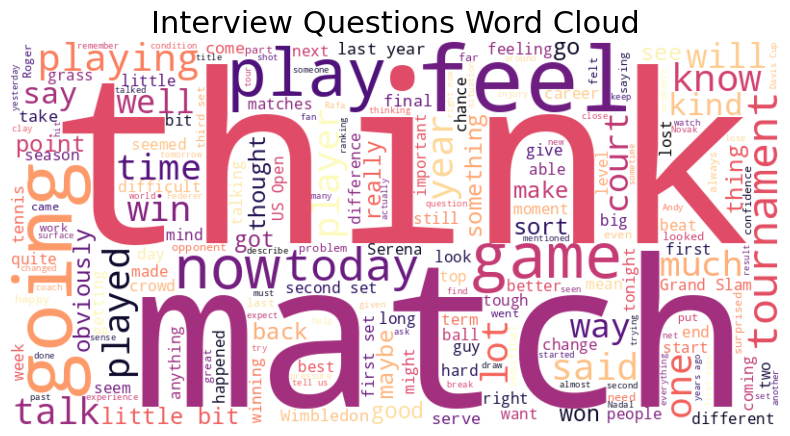

In [17]:
# All Questions Word Cloud
all_questions_text = ' '.join(questions_df_cleaned['questions'])
all_questions = all_questions_text.split()

# Create a WordCloud object
wordcloud = WordCloud(width=800, height=400,
                      colormap=sns.color_palette("magma", as_cmap=True),
                      background_color='white').generate(all_questions_text)

# Display the generated word cloud using matplotlib
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Interview Questions Word Cloud', fontsize = 22)
plt.show()

### Gender Specific Question Data Word Clouds

In [18]:
# filter into men's and women's data
questions_m_df_cleaned = questions_df_cleaned[questions_df_cleaned['gender'] == 'M']
questions_f_df_cleaned = questions_df_cleaned[questions_df_cleaned['gender'] == 'F']
male_question_text = ' '.join(questions_m_df_cleaned['questions'])
female_question_text = ' '.join(questions_f_df_cleaned['questions'])

# convert male and female words into lists
male_question_words = male_question_text.split()
female_question_words = female_question_text.split()

-------------------------------------------------------------------
Male Frequency Mean: 36.454384687402474
Female Frequency Mean: 33.96903062399263
Male Frequency STD: 274.5749864840451
Female Frequency STD: 245.2484623277925
-------------------------------------------------------------------
Male Word Count: 98110
Female Word Count: 98110
-------------------------------------------------------------------


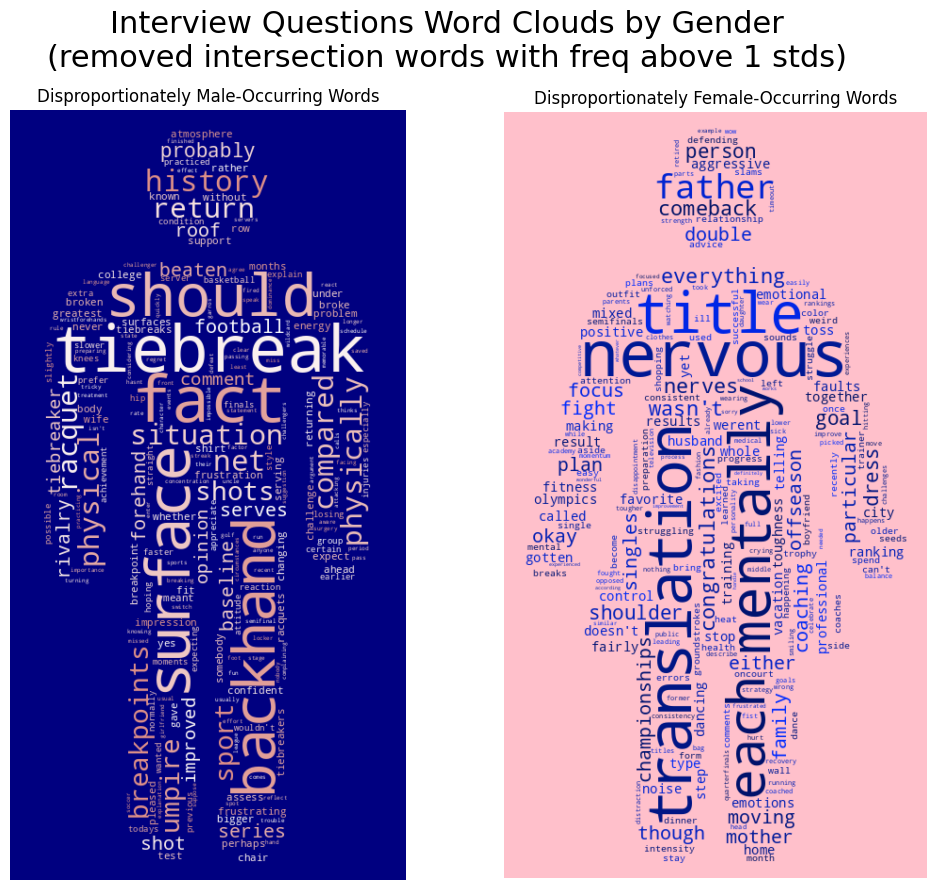

In [19]:
question_elements_1std, question_counters_1std, question_diff_lists_1std = \
get_diff_words(male_question_words, female_question_words, 1, 'Interview Questions')

-------------------------------------------------------------------
Male Frequency Mean: 36.454384687402474
Female Frequency Mean: 33.96903062399263
Male Frequency STD: 274.5749864840451
Female Frequency STD: 245.2484623277925
-------------------------------------------------------------------
Male Word Count: 36062
Female Word Count: 36062
-------------------------------------------------------------------


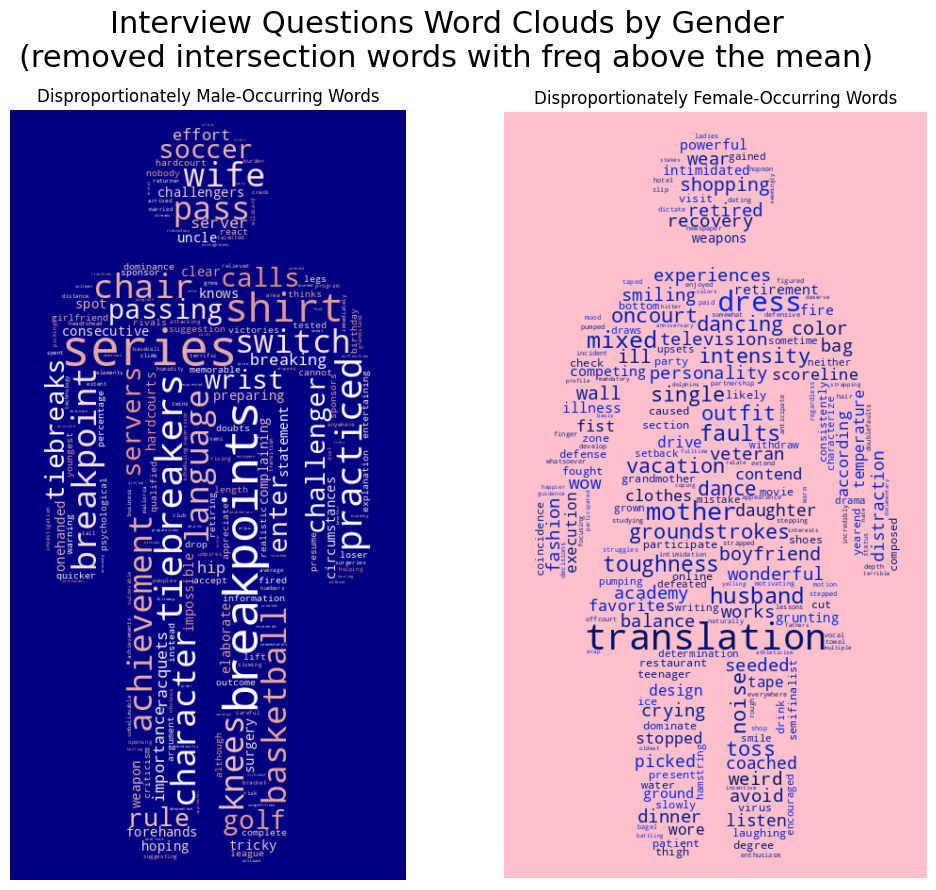

In [20]:
question_elements_0std, question_counters_0std, question_diff_lists_0std = \
get_diff_words(male_question_words, female_question_words, 0, 'Interview Questions')

-------------------------------------------------------------------
Male Frequency Mean: 36.454384687402474
Female Frequency Mean: 33.96903062399263
Male Frequency STD: 274.5749864840451
Female Frequency STD: 245.2484623277925
-------------------------------------------------------------------
Male Word Count: 3872
Female Word Count: 3872
-------------------------------------------------------------------


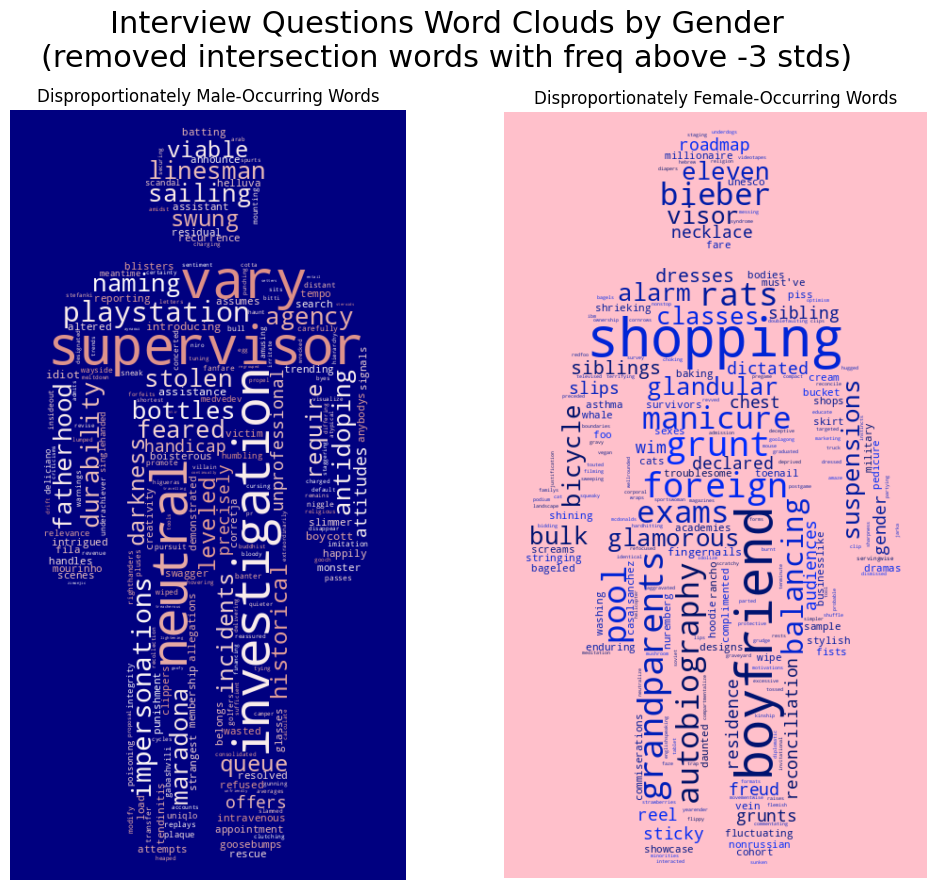

In [21]:
question_elements_neg_3std, question_counters_neg_3std, question_diff_lists_neg_3std = \
get_diff_words(male_question_words, female_question_words, -3, 'Interview Questions')

### Mean Word Characteristic Scores by Gender

After removing the intersection of words appearing more than one standard deviation from the mean in both the men's and women's questions, we take the mean word characteristic score of the difference in counts to see how words more commonly used to describe men deviate from those more commonly used to describe women.

-------------------------------------------------------------------
Male Percentage of Words Included: 0.68
-------------------------------------------------------------------
Female Percentage of Words Included: 0.72
-------------------------------------------------------------------


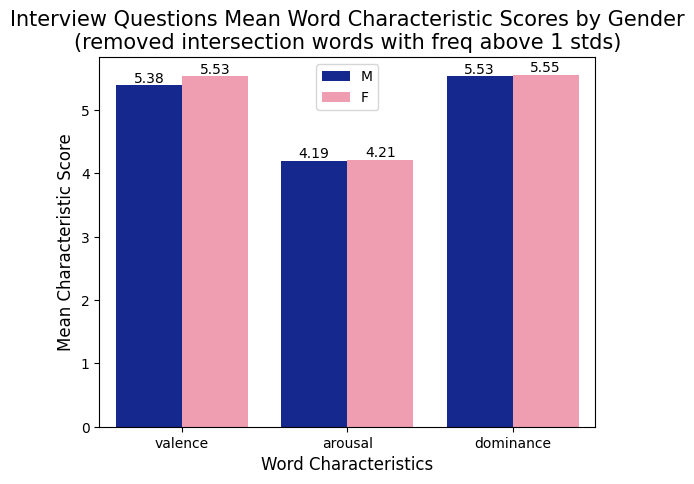

In [22]:
male_triple, female_triple = get_avg_vad(male_question_words, female_question_words, 1, 'Interview Questions')

-------------------------------------------------------------------
Male Percentage of Words Included: 0.68
-------------------------------------------------------------------
Female Percentage of Words Included: 0.7
-------------------------------------------------------------------


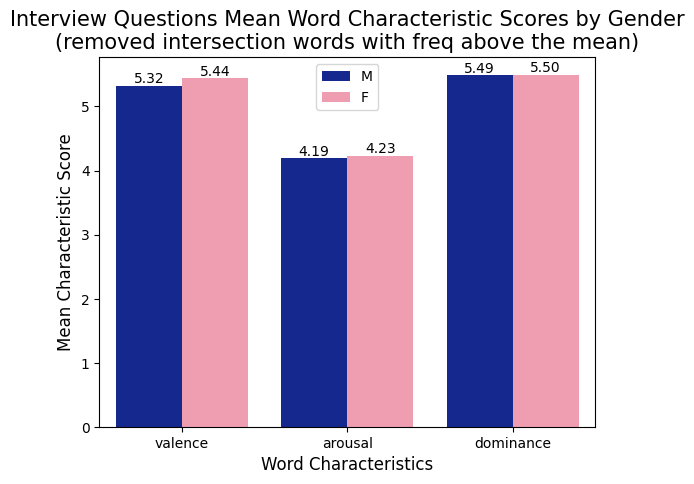

In [23]:
male_triple, female_triple = get_avg_vad(male_question_words, female_question_words, 0, 'Interview Questions')

-------------------------------------------------------------------
Male Percentage of Words Included: 0.55
-------------------------------------------------------------------
Female Percentage of Words Included: 0.57
-------------------------------------------------------------------


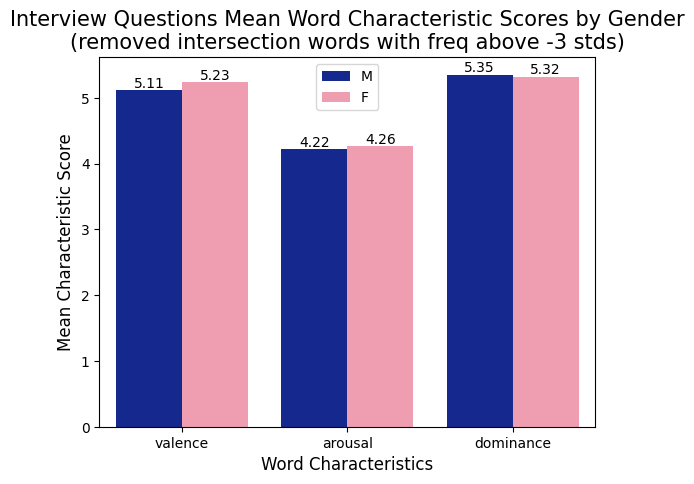

In [24]:
male_triple, female_triple = get_avg_vad(male_question_words, female_question_words, -3, 'Interview Questions')

### Number of Questions Per Ranking For Male and Female Players

/Users/kylesullivan/Documents/Educational/School/Graduate/UPenn/Courses/CIS 530/Project/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/kylesullivan/Documents/Educational/School/Graduate/UPenn/Courses/CIS 530/Project/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/kylesullivan/Documents/Educational/School/Graduate/UPenn/Courses/CIS 530/Project/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead 

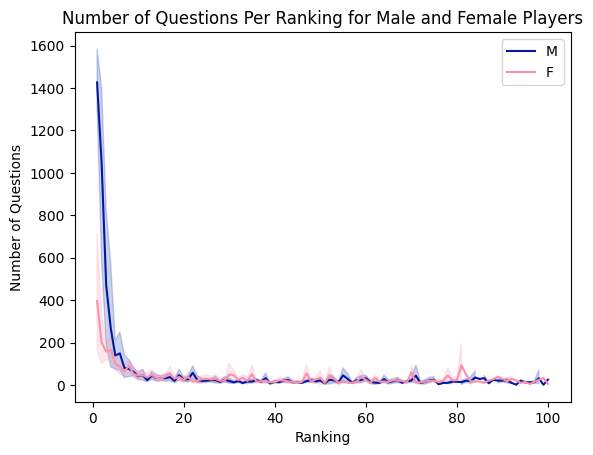

In [25]:
# Questions per rank and gender (top 100 players)
question_counts = questions_df_cleaned.groupby(by=["player", "ranking", "gender"])[['questions']].count().reset_index()
top_100 = question_counts[question_counts['ranking']<=100]
sns.lineplot(data=top_100, x='ranking', y='questions', hue='gender')

# Adding labels and title
plt.xlabel('Ranking')
plt.ylabel('Number of Questions')
plt.title('Number of Questions Per Ranking for Male and Female Players')

# Adding a legend
plt.legend()

# Display the plot
plt.show()

### Number of Questions for Male and Female Players in the Top 5

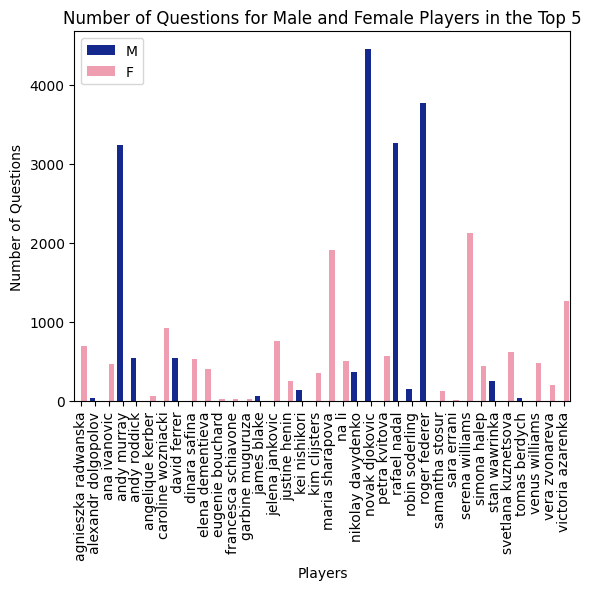

In [26]:
# Questions per rank and gender (top 100 players)
question_counts = questions_df_cleaned.groupby(by=["player", "ranking", "gender"])[['questions']].count().reset_index()
top_5 = question_counts[question_counts['ranking']<=5]
top_5 = top_5.groupby(['player', 'gender'])[['questions']].sum().reset_index()
sns.barplot(data=top_5, x='player', y='questions', hue='gender', hue_order=['M', 'F'])

# create custom colors array
colors = ["#001ba1", "#fc90ab"]
# set custom color palette
sns.set_palette(sns.color_palette(colors))

# Adding labels and title
plt.xlabel('Players')
plt.xticks(rotation=90)
plt.ylabel('Number of Questions')
plt.title('Number of Questions for Male and Female Players in the Top 5')

# Adding a legend
plt.legend()

# Display the plot
plt.show()

## Commentaries Data

The commentary data contains 3962 pieces of live-text play-by-play commentaries, split evenly between men and women singles matches. It is a JSON file with three fields:

	- 'commentary': the actual text from the live updates. It describes the process of the game.
	- 'gender': 'F' indicates the update is from a women's match; 'M' means it is from men's game.
	- 'scoreline': the score when the text update is posted. * indicates the player who is serving at the moment.

While we used Sports Mole's commentaries for our study, ByTheMinute could be another source to gather similar data.



In [27]:
commentaries_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3962 entries, 0 to 3961
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   commentary  3962 non-null   object
 1   scoreline   3962 non-null   object
 2   gender      3962 non-null   object
dtypes: object(3)
memory usage: 123.8+ KB


In [28]:
commentaries_df['commentary']

0       Makarova slumps back into making unforced erro...
1       Just look in her match with Heather Watson las...
2       Sharapova saves a break point to hold her serv...
3       Erakovic is looking superb behind her serve, a...
4       She can't save another one and Williams is now...
                              ...                        
3957    That's more promising from the Russian, who se...
3958    A sharp backhand volley hands Azarenka the ope...
3959    Azarenka is serving to stay in the set, and th...
3960    The power on show in some of these rallies wou...
3961    That could be the game that breaks the resolve...
Name: commentary, Length: 3962, dtype: object

In [29]:
commentaries_df['commentary'].explode()[0]

"Makarova slumps back into making unforced errors again as she finds the net with her first forehand of the game, while her second isn't much better as she overhits when attempting to clip the baseline. Sharapova hits an accurate serve down the 'T' to bring up three set points. Another pinpoint serves proves too difficult to return as the number two seed claims the first set."

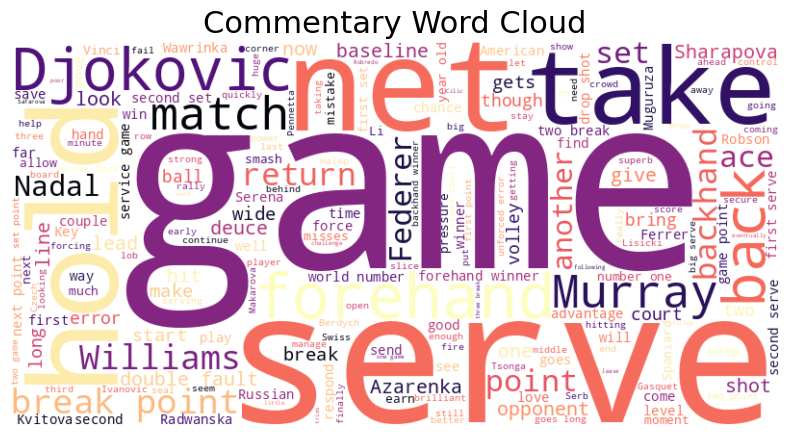

In [30]:
# All Commentary Word Cloud
all_commentary_text = ' '.join(commentaries_df['commentary'])
all_commentary = all_commentary_text.split()

# Create a WordCloud object
wordcloud = WordCloud(width=800, height=400,
                      colormap=sns.color_palette("magma", as_cmap=True),
                      background_color='white').generate(all_commentary_text)

# Display the generated word cloud using matplotlib
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Commentary Word Cloud', fontsize = 22)
plt.show()

### Gender Specific Commentary Data Word Clouds

In [31]:
# Remove gender specific words, player names, case, and punctuation

# filter into men's and women's data
commentary_m_df = commentaries_df[commentaries_df['gender'] == 'M']
commentary_f_df = commentaries_df[commentaries_df['gender'] == 'F']
male_commentary_text = ' '.join(commentary_m_df['commentary'])
female_commentary_text = ' '.join(commentary_f_df['commentary'])

# convert male and female words into lists
male_commentary_words = male_commentary_text.split()
female_commentary_words = female_commentary_text.split()

-------------------------------------------------------------------
Male Frequency Mean: 12.92087542087542
Female Frequency Mean: 13.947201689545935
Male Frequency STD: 61.39063640016673
Female Frequency STD: 66.50006836055333
-------------------------------------------------------------------
Male Word Count: 17306
Female Word Count: 17306
-------------------------------------------------------------------


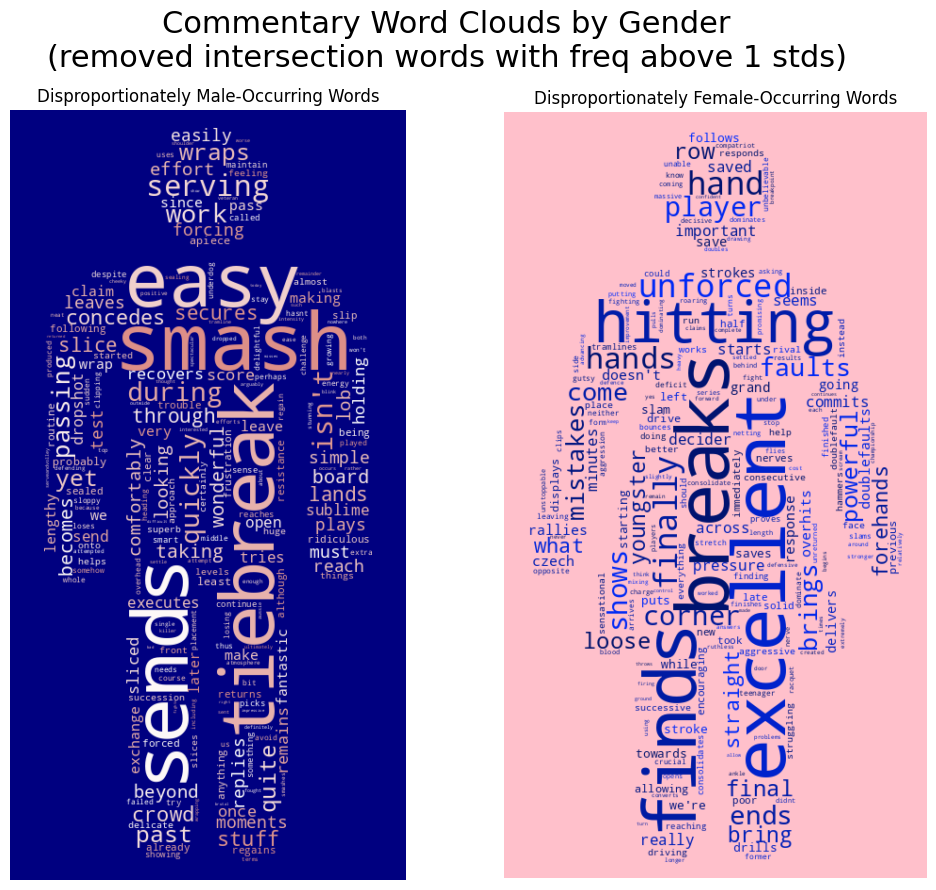

In [32]:
comm_elements_1std, comm_counters_1std, comm_diff_lists_1std = \
get_diff_words(male_commentary_words, female_commentary_words, 1, 'Commentary')

-------------------------------------------------------------------
Male Frequency Mean: 12.92087542087542
Female Frequency Mean: 13.947201689545935
Male Frequency STD: 61.39063640016673
Female Frequency STD: 66.50006836055333
-------------------------------------------------------------------
Male Word Count: 7605
Female Word Count: 7605
-------------------------------------------------------------------


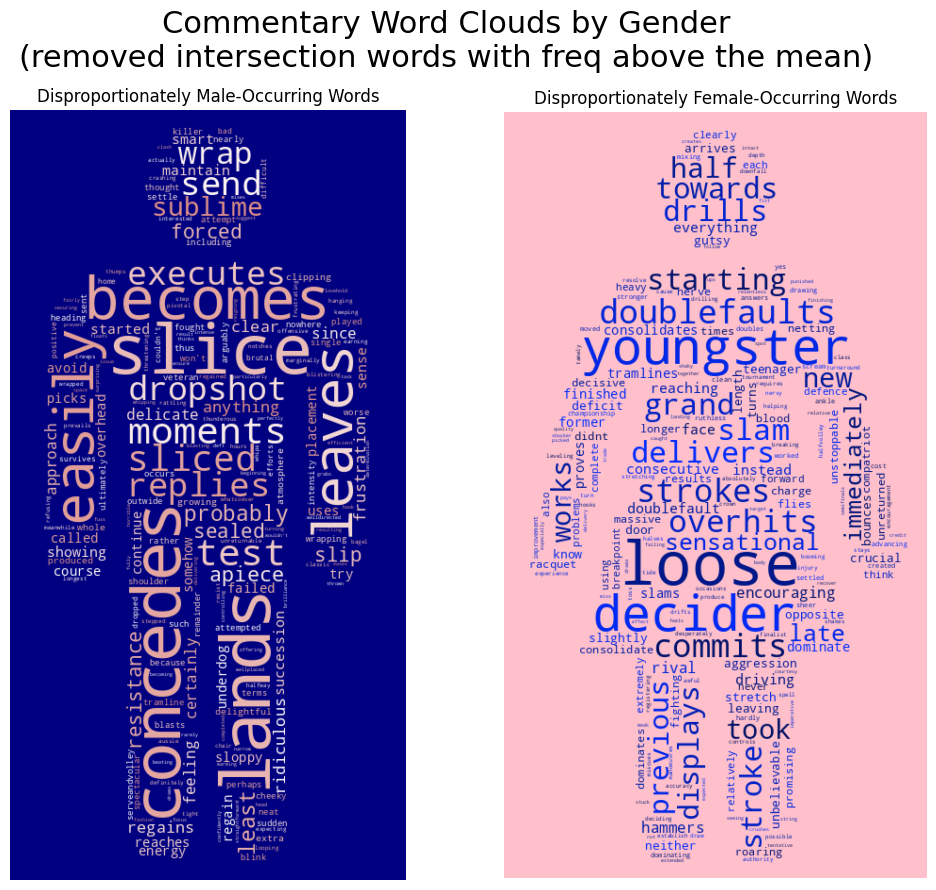

In [33]:
comm_elements_0std, comm_counters_0std, comm_diff_lists_0std = \
get_diff_words(male_commentary_words, female_commentary_words, 0, 'Commentary')

-------------------------------------------------------------------
Male Frequency Mean: 12.92087542087542
Female Frequency Mean: 13.947201689545935
Male Frequency STD: 61.39063640016673
Female Frequency STD: 66.50006836055333
-------------------------------------------------------------------
Male Word Count: 1248
Female Word Count: 1248
-------------------------------------------------------------------


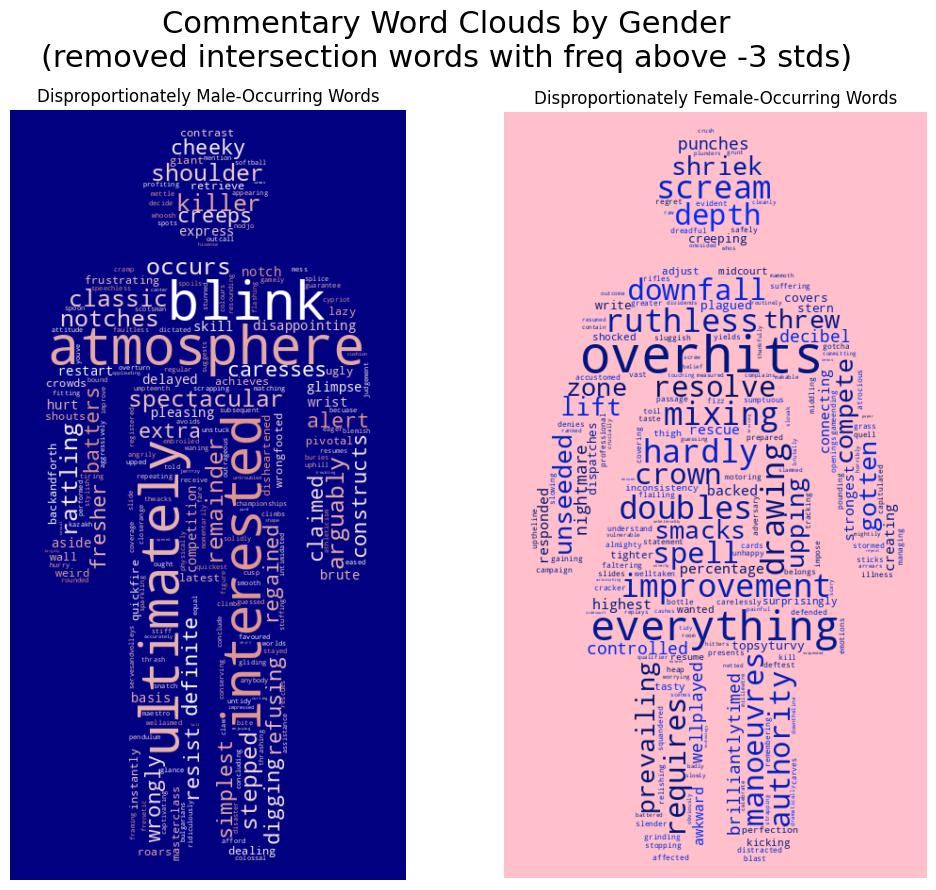

In [34]:
comm_elements_neg_3std, comm_counters_neg_3std, comm_diff_lists_neg_3std = \
get_diff_words(male_commentary_words, female_commentary_words, -3, 'Commentary')

### Mean Word Characteristic Scores by Gender

After removing the intersection of words appearing more than one standard deviation from the mean in both the men's and women's commentary, we take the mean word characteristic score of the difference in counts to see how words more commonly used to describe men deviate from those more commonly used to describe women.

-------------------------------------------------------------------
Male Percentage of Words Included: 0.67
-------------------------------------------------------------------
Female Percentage of Words Included: 0.72
-------------------------------------------------------------------


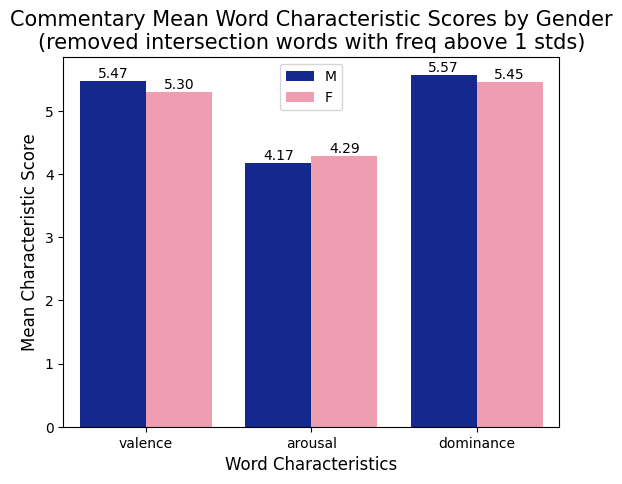

In [35]:
male_triple, female_triple = get_avg_vad(male_commentary_words, female_commentary_words, 1, 'Commentary')

-------------------------------------------------------------------
Male Percentage of Words Included: 0.68
-------------------------------------------------------------------
Female Percentage of Words Included: 0.71
-------------------------------------------------------------------


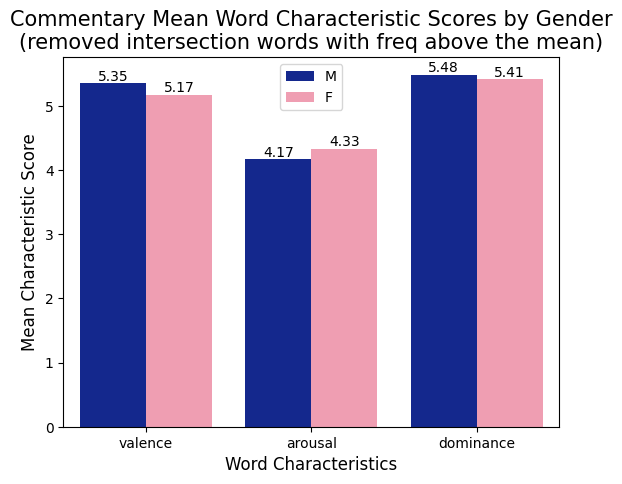

In [36]:
male_triple, female_triple = get_avg_vad(male_commentary_words, female_commentary_words, 0, 'Commentary')

-------------------------------------------------------------------
Male Percentage of Words Included: 0.66
-------------------------------------------------------------------
Female Percentage of Words Included: 0.67
-------------------------------------------------------------------


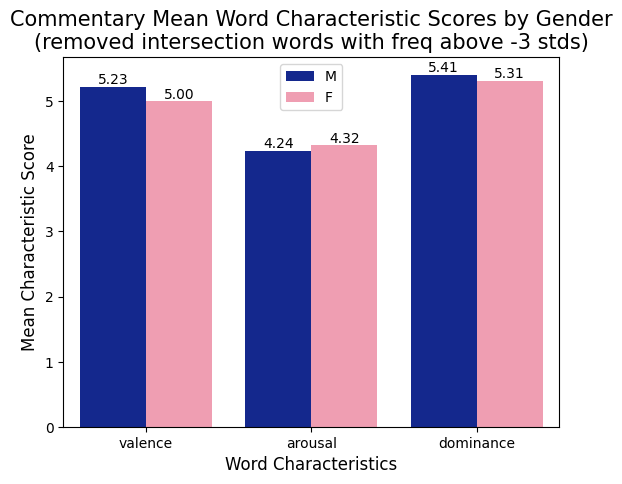

In [37]:
male_triple, female_triple = get_avg_vad(male_commentary_words, female_commentary_words, -3, 'Commentary')

### Number of Commentaries for Male and Female Players

Combine players into a single column to explore how interviews are divided up

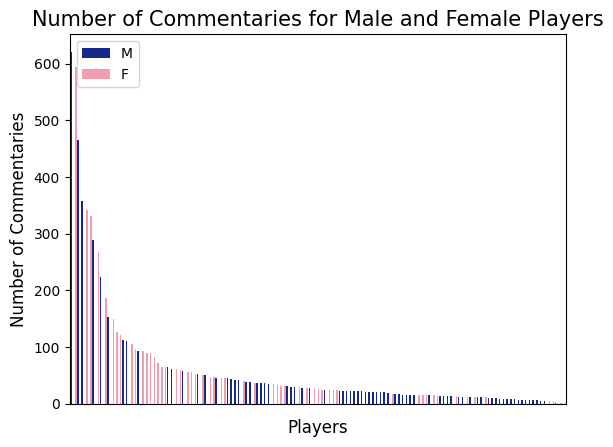

In [38]:
# get two players columns
commentaries_df['player1'] = commentaries_df['scoreline'].apply(lambda x: x.split()[0].replace('*', ''))
commentaries_df['player2'] = commentaries_df['scoreline'].apply(lambda x: x.split()[len(x.split())-1].replace('*', ''))

# concat the dataframe with itself with one combined player column
df1 = commentaries_df
df1 = df1.drop(columns='player2')
df1 = df1.rename(columns={'player1':'player'})
df2 = commentaries_df
df2 = df2.drop(columns='player1')
df2 = df2.rename(columns={'player2':'player'})
frames = [df1, df2]
combined_commentaries_df = pd.concat(frames)
player_comm_feq_df = combined_commentaries_df.groupby(by=["player", "gender"])[['commentary']].count().reset_index()
player_comm_feq_df = player_comm_feq_df.sort_values(by='commentary', ascending=False)

# Commentaries per player by gender

# create custom colors array
colors = ["#001ba1", "#fc90ab"]
# set custom color palette
sns.set_palette(sns.color_palette(colors))

g1 = sns.barplot(data=player_comm_feq_df, x='player', y='commentary',
                 hue='gender', hue_order=['M', 'F'])
g1.tick_params(bottom=False)
g1.set(xticklabels=[])

# Adding labels and title
plt.xlabel('Players', fontsize=12)
plt.ylabel('Number of Commentaries', fontsize=12)
plt.title('Number of Commentaries for Male and Female Players', fontsize = 15)

# Adding a legend
plt.legend()

# Display the plot
plt.show()

### Players with the Most Commentaries

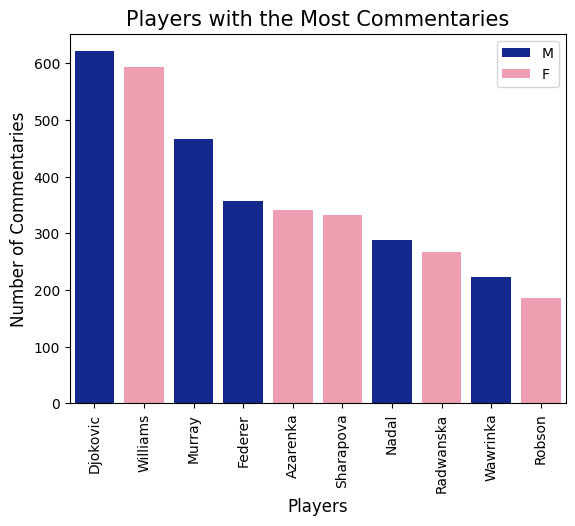

In [39]:
# The players with the most commentaries (10 most)
top_player_comm_freq_df = player_comm_feq_df[0:10]

# create custom colors array
colors = ["#001ba1", "#fc90ab"]
# set custom color palette
sns.set_palette(sns.color_palette(colors))

g1 = sns.barplot(data=top_player_comm_freq_df, x='player', y='commentary', hue='gender',
                 dodge=False, hue_order=['M', 'F'])

# Adding labels and title
plt.xlabel('Players', fontsize=12)
plt.xticks(rotation=90)
plt.ylabel('Number of Commentaries', fontsize=12)
plt.title('Players with the Most Commentaries', fontsize=15)

# Adding a legend
plt.legend()

# Display the plot
plt.show()

### Commentary Word Count Distribution by Gender

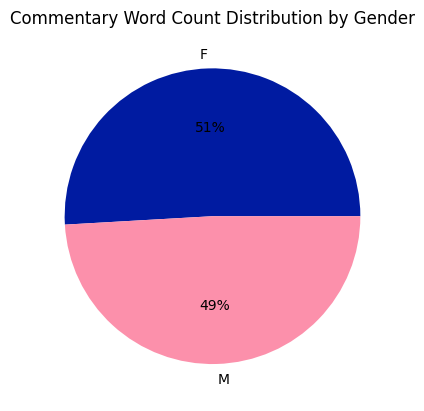

In [40]:
# explore how the number of words are divded up among male/female commentaries
commentaries_df[['commentary', 'gender']]
commentaries_df['word_length'] = commentaries_df['commentary'].apply(lambda x: len(x))
gender_comm_word_counts_df = commentaries_df.groupby(by=['gender'])[['word_length']].sum().reset_index()

# plotting data on chart

# create custom colors array
colors = ["#001ba1", "#fc90ab"]
# set custom color palette
sns.set_palette(sns.color_palette(colors))

plt.pie(data=gender_comm_word_counts_df, x= 'word_length', labels='gender',
        autopct='%.0f%%')

plt.title('Commentary Word Count Distribution by Gender')

# displaying chart
plt.show()

## Transcripts Data

The dataset provide the full transcript (i.e. both questions and player responses), in the format of a JSON file:

	>>> import json
	>>> with open("transcripts_matchinfo.json", "r") as f:
	...		interviews = json.load(f)

	The following is an example for one transcript, with each field explained:

	>>> interview = interviews['0']
	0: {
		'QandA': ...  
			# Interview transcripts in the format of a list of question answer pairs.   
		'date': '2015-06-21',  # date the match is played
		'gender': 'M', # 'F' indicates women's singles match, 'M' indicates men's.
		'opponent': 'Kevin Anderson', # opponent in the match
			(available only if the opponent has at least one interview recorded in our dataset.)
  		'player': 'Andy Murray', # player being interviewed
  		'ranking': 3, # ranking of the player
  		'result': 1,  # 1 indicates the player being interviewed has won the match; 0 otherwise.
    		'stage': 'The Final', # stage of the tournament
  		'tournament': 'AEGON CHAMPIONSHIPS' # tournament name
		'tournament_type': 'ATP500', # type of the tournament, indicating tournament prestige.
	}

Note that:

- These questions and answers are transcribed exactly the way the journalists and the players put it; they are not further edited for grammatical correctness. There are, although relatively rarely, questions that are marked as (Off microphone.), (Indiscernible) or even (Translated from X) where X is a language other than English.
- Information about which journalist asked which question is not available.
- This transcript data does not contain all singles press conference transcripts available at ASAP sports as we only included transcripts that we could find corresponding match information for. In addition, since transcripts data and match results are matched by date and player last name, and we did not manually check for every match, it is possible to have a few matching errors.



In [41]:
transcripts_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6467 entries, 0 to 6466
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   QandA            6467 non-null   object        
 1   ranking          6466 non-null   float64       
 2   tournament_type  6467 non-null   object        
 3   gender           6467 non-null   object        
 4   tournament       6467 non-null   object        
 5   player           6467 non-null   object        
 6   result           6467 non-null   int64         
 7   date             6467 non-null   datetime64[ns]
 8   stage            6467 non-null   object        
 9   opponent         6467 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(7)
memory usage: 555.8+ KB


### Interview Data by Tournament

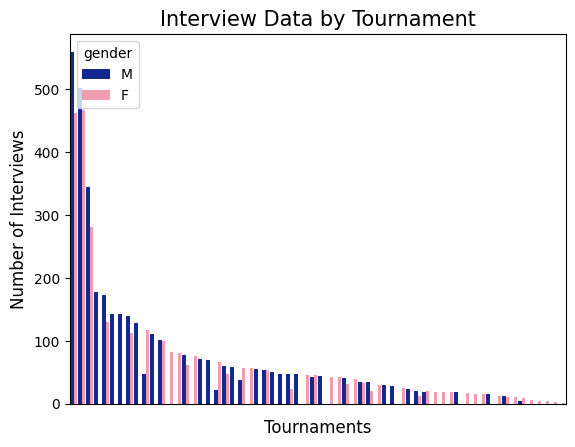

In [42]:
tournaments_df = transcripts_df.groupby(by=['tournament', 'gender'])[['QandA']].count().reset_index()
tournaments_df = tournaments_df.sort_values(by='QandA', ascending=False)

# Tournament Frequencies
g1 = sns.barplot(data=tournaments_df, x='tournament', y='QandA', hue='gender',
                 hue_order=['M', 'F'])
g1.tick_params(bottom=False)
g1.set(xticklabels=[])

# Adding labels and title
plt.xlabel('Tournaments', fontsize=12)
plt.ylabel('Number of Interviews', fontsize=12)
plt.title('Interview Data by Tournament', fontsize = 15)

# Display the plot
plt.show()

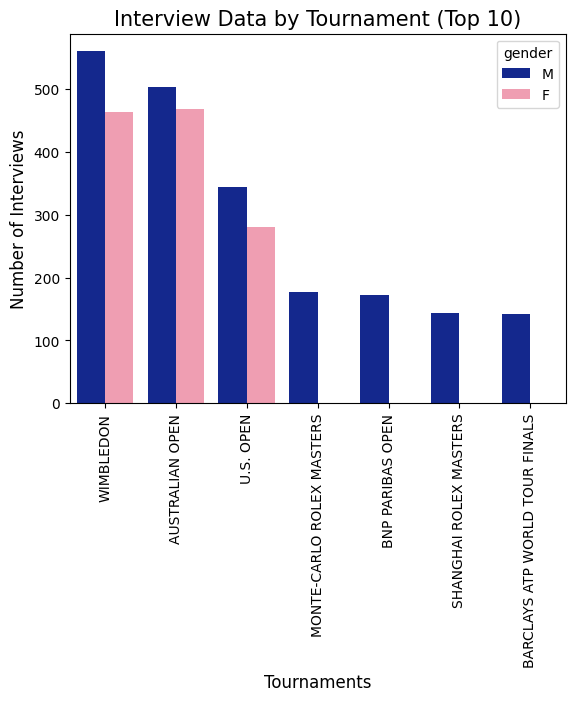

In [43]:
# The players with the most commentaries (10 most)
tournaments_df = tournaments_df[0:10]

# create custom colors array
colors = ["#001ba1", "#fc90ab"]
# set custom color palette
sns.set_palette(sns.color_palette(colors))

g1 = sns.barplot(data=tournaments_df, x='tournament', y='QandA',
                 hue='gender', hue_order=['M', 'F'])

# Adding labels and title
plt.xlabel('Tournaments', fontsize=12)
plt.xticks(rotation=90)
plt.ylabel('Number of Interviews', fontsize=12)
plt.title('Interview Data by Tournament (Top 10)', fontsize = 15)

# Display the plot
plt.show()

### Get answers in terms of gender as two lists of words

In [44]:
male_transcripts_df = transcripts_df[transcripts_df['gender'] == 'M']
female_transcripts_df = transcripts_df[transcripts_df['gender'] == 'F']

male_answers = []
for interview in male_transcripts_df['QandA'].to_list():
  for qna in interview:
    male_answers.append(qna[1])

female_answers = []
for interview in female_transcripts_df['QandA'].to_list():
  for qna in interview:
    female_answers.append(qna[1])

split_words = [words.split() for words in male_answers]
male_answers_words = [word for words in split_words for word in words]

split_words = [words.split() for words in female_answers]
female_answers_words = [word for words in split_words for word in words]

male_answers_text = ' '.join(male_answers_words)
female_answers_text = ' '.join(female_answers_words)
all_answers_text = male_answers_text + ' ' + female_answers_text

### Interview Answers Word Clouds by Gender

-------------------------------------------------------------------
Male Frequency Mean: 113.47878275570584
Female Frequency Mean: 93.21824855794442
Male Frequency STD: 1036.199686862758
Female Frequency STD: 825.5904596156403
-------------------------------------------------------------------
Male Word Count: 241449
Female Word Count: 241449
-------------------------------------------------------------------


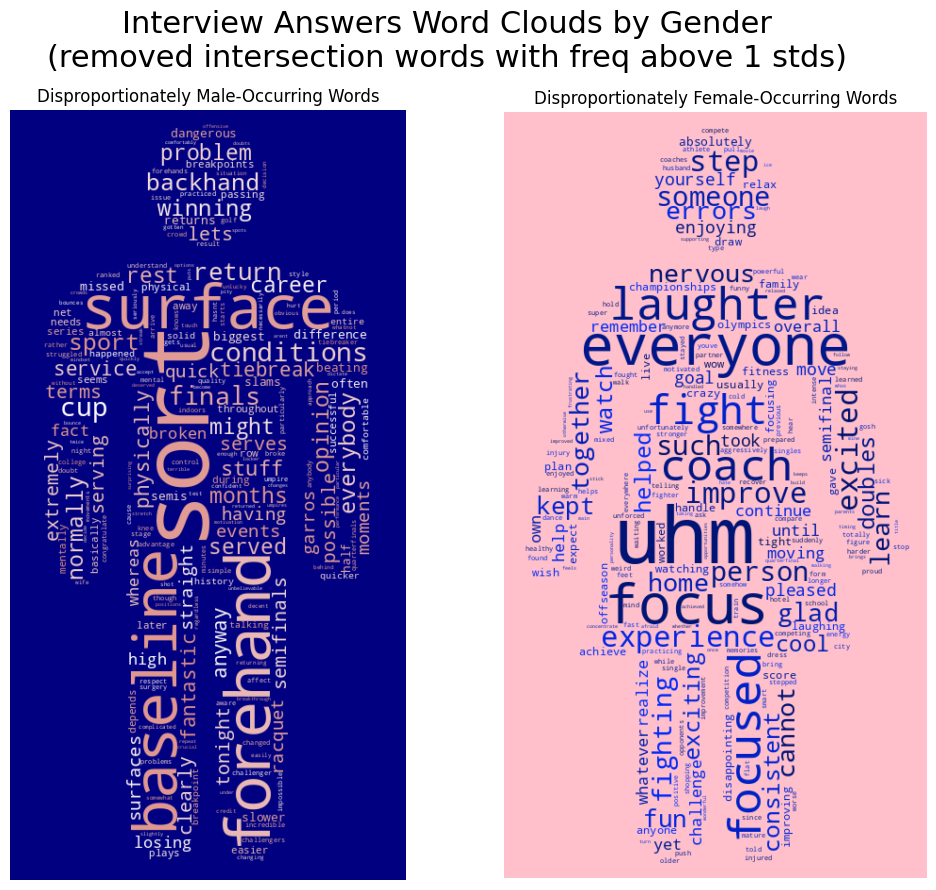

In [45]:
ans_elements_1std, ans_counters_1std, ans_diff_lists_1std = \
get_diff_words(male_answers_words, female_answers_words, 1, 'Interview Answers')

-------------------------------------------------------------------
Male Frequency Mean: 113.47878275570584
Female Frequency Mean: 93.21824855794442
Male Frequency STD: 1036.199686862758
Female Frequency STD: 825.5904596156403
-------------------------------------------------------------------
Male Word Count: 70174
Female Word Count: 70174
-------------------------------------------------------------------


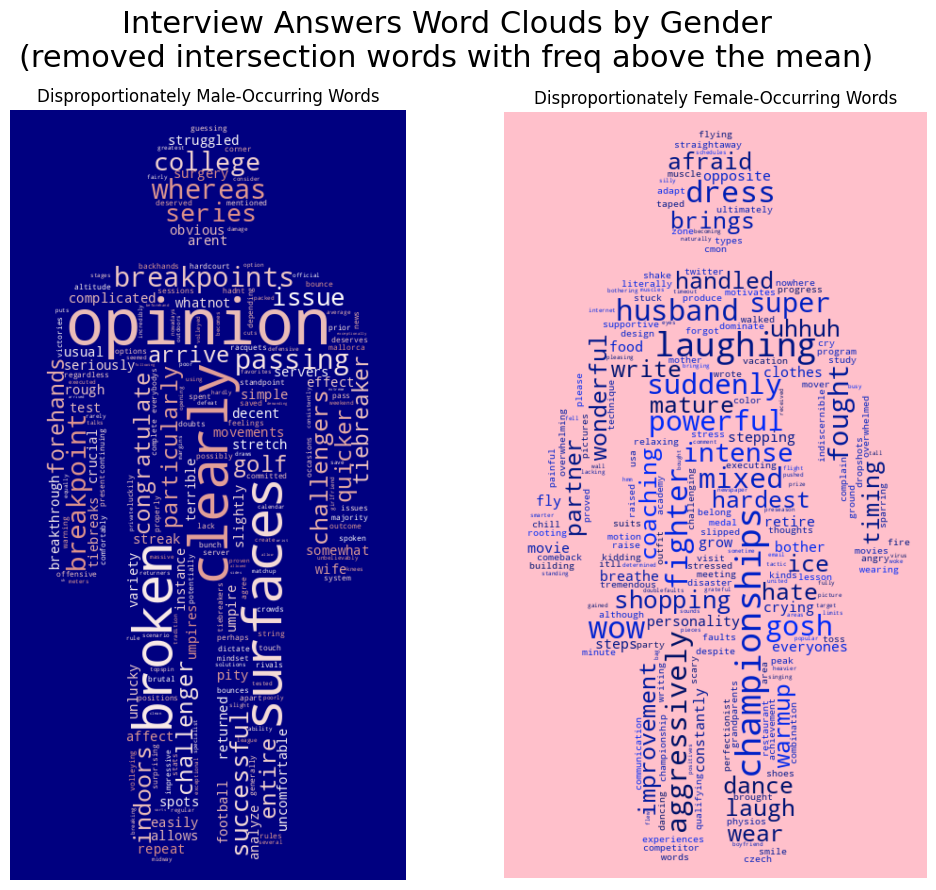

In [46]:
ans_elements_0std, ans_counters_0std, ans_diff_lists_0std = \
get_diff_words(male_answers_words, female_answers_words, 0, 'Interview Answers')

-------------------------------------------------------------------
Male Frequency Mean: 113.47878275570584
Female Frequency Mean: 93.21824855794442
Male Frequency STD: 1036.199686862758
Female Frequency STD: 825.5904596156403
-------------------------------------------------------------------
Male Word Count: 4007
Female Word Count: 4007
-------------------------------------------------------------------


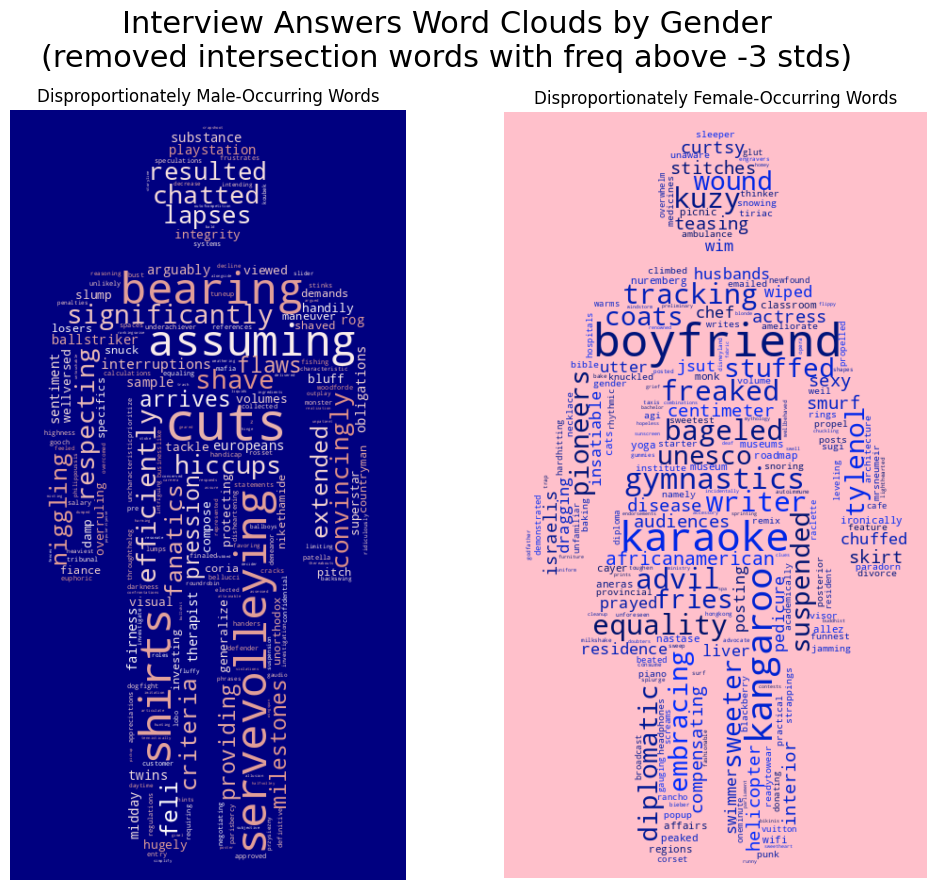

In [47]:
ans_elements_neg_3std, ans_counters_neg_3std, ans_diff_lists_neg_3std = \
get_diff_words(male_answers_words, female_answers_words, -3, 'Interview Answers')

### Interview Answers Word Characteristic Scores by Gender

After removing the intersection of words appearing more than one standard deviation from the mean in both the men's and women's commentary, we take the mean word characteristic score of the difference in counts to see how words more commonly used to describe men deviate from those more commonly used to describe women.

-------------------------------------------------------------------
Male Percentage of Words Included: 0.69
-------------------------------------------------------------------
Female Percentage of Words Included: 0.72
-------------------------------------------------------------------


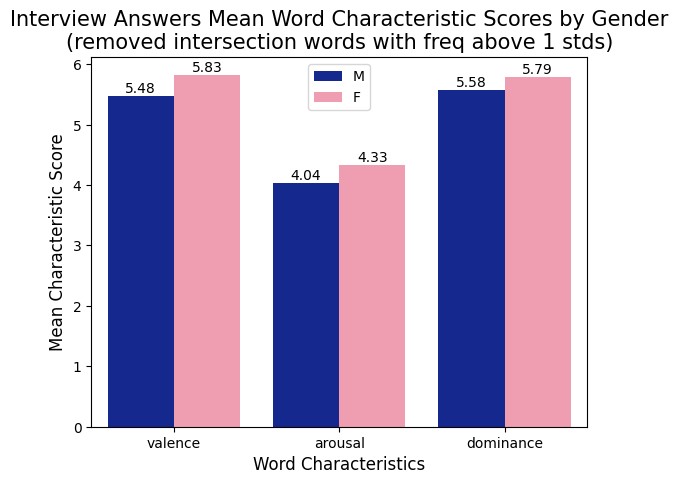

In [48]:
male_triple, female_triple = get_avg_vad(male_answers_words, female_answers_words, 1, 'Interview Answers')

-------------------------------------------------------------------
Male Percentage of Words Included: 0.72
-------------------------------------------------------------------
Female Percentage of Words Included: 0.72
-------------------------------------------------------------------


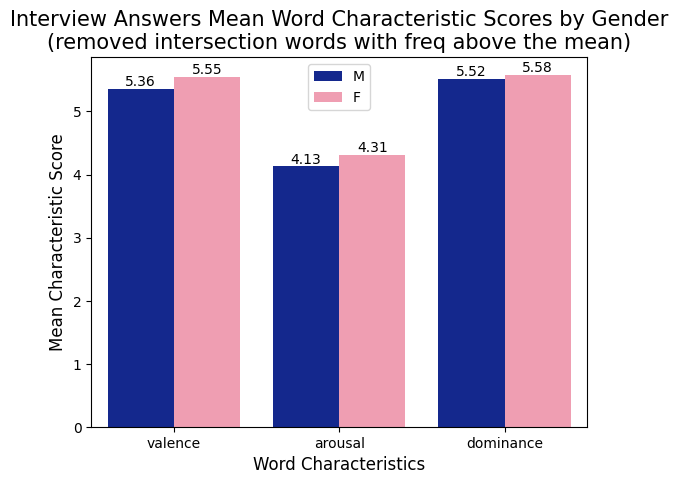

In [49]:
male_triple, female_triple = get_avg_vad(male_answers_words, female_answers_words, 0, 'Interview Answers')

-------------------------------------------------------------------
Male Percentage of Words Included: 0.54
-------------------------------------------------------------------
Female Percentage of Words Included: 0.53
-------------------------------------------------------------------


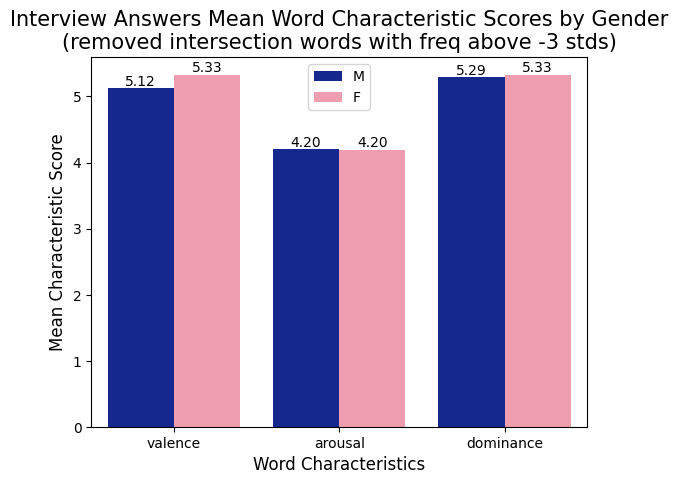

In [50]:
male_triple, female_triple = get_avg_vad(male_answers_words, female_answers_words, -3, 'Interview Answers')

# Establishing Baselines

## Simple Baseline: Similar top words for male & female tennis players.

Our simple baseline will be a similarity score between the top words for male & female tennis players. To calculate this, we will extract the 30 most common words for both groups and then compare the number of those top 30 words that are related to tennis. This is a similar simple baseline to the one established early in the paper we aim to recreate.

In [51]:
import re
from collections import Counter
from nltk import ngrams
from nltk.corpus import stopwords
import nltk

# Download the stopwords resource
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kylesullivan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [52]:
def get_top_30_sorted_tuples(diff_list):
    """
    Sorts a list of tuples based on the second element (count) in descending order 
    and returns the top 30 tuples.

    Args:
        diff_list (list of tuple): A list where each tuple contains at least two elements,
                                    with the second element being a count (int or float).

    Returns:
        list of tuple: A list containing the top 30 tuples sorted by the second element in descending order.
    """
    
    # Sort the list of tuples in descending order based on the second element (count)
    sorted_list = sorted(diff_list, key=lambda x: x[1], reverse=True)

    # Return the first 30 elements
    top_30 = sorted_list[:30]

    return top_30

Use chatGPT to first develop a list of tennis-related words. Then, manually add to this list through research from a dictionary, etc. The Paper's methodology involved actually using the commentary data to determine tennis-related words. In this simple baseline, we will use this list as our determinant of tennis-related words.

ChatGPT prompt:

```
# You are a tennis commentator for the world's most elite athletes.
# We are building a language model to understand tennis commentary better.
# Give me a list of all the words related to tennis that we should consider
# when building a model to detect tennis-related words in commentary and tennis player post-match, pre-match interviews.
```



In [53]:
tennis_related_words = [
    # Player-Specific Terms
    "player", "singles", "doubles", "opponent", "contender", "challenger", "world", "no", "1", "secures", "hands", "mistakes", "fault", "faults"

    # Match and Game Terms
    "match", "game", "set", "point", "tiebreak", "break", "serve", "volley", "rally", "net", "baseline", "advantage", "deuce", "game", "set", "match", "breaks", "hitting"

    # Tournament and Event Terms
    "grand", "slam", "atp", "wta", "major", "championship", "slam", "masters", "davis", "cup", "fed", "finals", "qualifier", "wildcard",

    # Court and Surface Terms
    "court", "surface", "clay", "grass", "hardcourt", "indoor", "outdoor", "plexicushion", "decoturf", "lands", "sends"

    # Skill and Technique Terms
    "forehand", "forehands", "backhand", "serve", "serving", "volley", "slice", "topspin", "drop", "lob", "smash", "approach", "passing", "spin", "power", "lands", "smash"

    # Equipment and Gear Terms
    "racket", "strings", "grip", "tennis", "ball", "racquet", "bag", "court", "shoes", "apparel", "gear", "kit",

    # Officials and Rules Terms
    "umpire", "chair", "umpire", "line", "judge", "hawk-eye", "challenge", "code", "violation", "let", "net", "cord", "foot", "fault", "double", "fault",

    # Ranking and Seeding Terms
    "ranking", "seed", "world", "number", "one", "top", "seed", "wildcard", "challenger", "qualifier", "round-robin", "concedes"

    # Performance and Strategy Terms
    "ace", "double", "fault", "strategy", "tactics", "mental", "toughness", "fitness", "endurance", "stamina", "speed", "precision", "decider",

    # Achievements and Records Terms
    "grand", "slam", "title", "career", "slam", "golden", "slam", "record", "milestone", "hall", "fame", "winning", "streak", "crowd",

    # Interview and Commentary Terms
    "interview", "commentator", "recap", "prediction", "post-match", "pre-match"
]

# Test print to verify the list
print(tennis_related_words)


['player', 'singles', 'doubles', 'opponent', 'contender', 'challenger', 'world', 'no', '1', 'secures', 'hands', 'mistakes', 'fault', 'faultsmatch', 'game', 'set', 'point', 'tiebreak', 'break', 'serve', 'volley', 'rally', 'net', 'baseline', 'advantage', 'deuce', 'game', 'set', 'match', 'breaks', 'hittinggrand', 'slam', 'atp', 'wta', 'major', 'championship', 'slam', 'masters', 'davis', 'cup', 'fed', 'finals', 'qualifier', 'wildcard', 'court', 'surface', 'clay', 'grass', 'hardcourt', 'indoor', 'outdoor', 'plexicushion', 'decoturf', 'lands', 'sendsforehand', 'forehands', 'backhand', 'serve', 'serving', 'volley', 'slice', 'topspin', 'drop', 'lob', 'smash', 'approach', 'passing', 'spin', 'power', 'lands', 'smashracket', 'strings', 'grip', 'tennis', 'ball', 'racquet', 'bag', 'court', 'shoes', 'apparel', 'gear', 'kit', 'umpire', 'chair', 'umpire', 'line', 'judge', 'hawk-eye', 'challenge', 'code', 'violation', 'let', 'net', 'cord', 'foot', 'fault', 'double', 'fault', 'ranking', 'seed', 'world',

In [54]:
top_30_female = get_top_30_sorted_tuples(comm_diff_lists_1std[1].most_common())

In [55]:
top_30_male = get_top_30_sorted_tuples(comm_diff_lists_1std[0].most_common())

In [56]:
def calculate_tennis_simple_percentage(diff_list, tennis_related_words):
    """
    Calculate the percentage of tennis-related words in a given list of word counts.

    Args:
        diff_list (list of tuples): A list where each tuple contains a word and its corresponding count.
                                     Example: [('word1', 5), ('word2', 3)]
        tennis_related_words (list of str): A list of words that are considered tennis-related.

    Returns:
        float: The percentage of words in diff_list that are tennis-related. 
               Returns 0 if total_words is 0 to avoid division by zero.
    """
    
    # Convert tennis_related_words to a set for faster membership testing
    tennis_related_set = set(tennis_related_words)

    # Calculate the total number of words in diff_list
    total_words = sum(count for _, count in diff_list)

    # Calculate the number of tennis-related words in diff_list
    tennis_related_count = sum(count for word, count in diff_list if word.lower() in tennis_related_set)

    # Calculate the percentage of tennis-related words
    percentage_tennis_related = (tennis_related_count / total_words) * 100 if total_words > 0 else 0

    return percentage_tennis_related

In [57]:
male_question_perc_tennis_top30 = calculate_tennis_simple_percentage(top_30_male, tennis_related_words)
male_question_perc_tennis_top30

32.37639553429027

In [58]:
female_question_perc_tennis_top_30 = calculate_tennis_simple_percentage(top_30_female, tennis_related_words)
female_question_perc_tennis_top_30

21.409921671018274

This serves as a simple baseline. We see that men have more words than women that are directly tennis related when looking at the top 30 tokens for questions asked to both women and men.

## Complex Baseline: N-Gram Perplexities

This is the baseline ultimately used by the original Paper 0. It is a calculation of perplexity where low perplexity for a question indicates a lower bias. The paper used bigrams. We go a step further, using trigrams, followed by an LSTM model.

## Language Models

N-Gram Results Dataframe

In [59]:
questions_df_cleaned = pd.read_csv('/Users/kylesullivan/Documents/Educational/School/Graduate/UPenn/Courses/CIS 530/Project/question_perplexities.csv')
questions_df_cleaned

,Unnamed: 0,player,gender,result,questions,ranking,bigram_questions,adi_bigram_perplexity,lap_bigram_perplexity,sb_bigram_perplexity,...,sb_trigram_perplexity,kni_trigram_perplexity,adi_m_trigram_perplexity,lap_m_trigram_perplexity,sb_m_trigram_perplexity,kni_m_trigram_perplexity,adi_f_trigram_perplexity,lap_f_trigram_perplexity,sb_f_trigram_perplexity,kni_f_trigram_perplexity
0,0,andy murray,M,1,That last set seemed like a faultless performa...,3.0,"[('<s>', 'that'), ('that', 'last'), ('last', '...",834.621616,982.597397,657.978210,...,466.777035,1246.481854,394.459984,1342.143033,433.251221,1073.198806,212.424843,1372.270140,220.083184,538.721953
1,1,andy murray,M,1,"Did playing the semifinal, finishing that off ...",3.0,"[('<s>', 'did'), ('did', 'playing'), ('playing...",339.545920,697.892007,214.664696,...,407.549804,1507.138443,511.317050,2023.688558,396.718501,1628.565668,501.843255,1967.753223,416.835522,1482.464043
2,2,andy murray,M,1,Is that difficult mentally as much as physical...,3.0,"[('<s>', 'is'), ('is', 'that'), ('that', 'diff...",348.509815,607.945086,283.513724,...,217.397702,434.769204,189.813086,1531.370388,184.489796,398.133021,230.052262,1468.841843,217.753710,466.955625
3,3,andy murray,M,1,You said on TV I think you said you felt bette...,3.0,"[('<s>', 'you'), ('you', 'said'), ('said', 'on...",622.622800,1265.064041,515.982747,...,976.788094,2375.957457,568.401899,2060.667135,886.078649,2025.474926,489.821124,2061.763611,760.961201,1781.254152
4,4,andy murray,M,1,The last time that you won this tournament you...,3.0,"[('<s>', 'the'), ('the', 'last'), ('last', 'ti...",313.505197,709.686402,256.044067,...,189.922261,304.966523,491.081077,1490.748952,611.932387,1242.124221,140.396543,1044.600991,152.319602,227.663567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81928,81928,victoria azarenka,F,1,"Tennis is sometimes described as a profession,...",8.0,"[('<s>', 'tennis'), ('tennis', 'is'), ('is', '...",214.605174,605.931048,159.598033,...,187.566341,457.877750,135.755005,1236.193207,162.401080,368.120262,160.692183,1279.547544,179.954153,420.574692
81929,81929,victoria azarenka,F,1,Last year's champion is really into art. Who a...,8.0,"[('<s>', 'last'), ('last', 'year'), ('year', ""...",147.161370,669.610697,102.707659,...,82.089927,199.003488,118.879540,1287.079613,100.832452,271.344642,93.430565,1105.149811,97.269899,188.905544
81930,81930,victoria azarenka,F,1,You touched on your support of Argentina. How ...,8.0,"[('<s>', 'you'), ('you', 'touched'), ('touched...",199.928943,454.441263,164.995255,...,175.976660,412.267966,99.946676,981.261926,112.939740,246.927778,196.556010,951.636935,186.289775,483.039003
81931,81931,victoria azarenka,F,1,Do you think Wimbledon does that to an extent?,8.0,"[('<s>', 'do'), ('do', 'you'), ('you', 'think'...",1510.605773,1983.842022,1089.078060,...,1272.192910,3224.944131,352.383791,1301.941880,518.881020,837.081275,972.464248,2211.207406,1274.762660,2777.292084


### Tokenize Commentary Data

In [60]:
# all commentary tokens
tok_all_commentary = [word_tokenize(sent) for sent in sent_tokenize(all_commentary_text.lower())]

# get all male commentary tokens
tok_male_commentary = [word_tokenize(sent) for sent in sent_tokenize(male_commentary_text.lower())]

# get all female commentary tokens
tok_female_commentary = [word_tokenize(sent) for sent in sent_tokenize(female_commentary_text.lower())]

### Bigrams

##### Construct Bigrams

Get bigrams for questions, where each question is a list index

In [61]:
q_lst = questions_df_cleaned['questions'].values.tolist()
bigram_q_lst = [[lst for sublst in [list(bigrams(pad_both_ends(word_tokenize(sent), n=2))) for sent in sent_tokenize(question.lower())] for lst in sublst] for question in q_lst]

bigram_q_lst_cleaned = []
grams = bigram_q_lst
for gram in grams:
    temp = []
    length = len(gram) - 1
    for index, tup in enumerate(gram):
        if gram[index][1] == '</s>':
            pass
        elif index < length and gram[index+1][1] == '</s>':
            temp.append(tuple([gram[index][0], '</s>']))
        else:
            temp.append(tuple([gram[index][0], gram[index][1]]))
    bigram_q_lst_cleaned.append(temp)

questions_df_cleaned['bigram_questions'] = bigram_q_lst_cleaned

Remove the end of sentence punctuation, since the probability of "/s" following ".", "?", and "!" are all nearly 100%. This skews short sentence perplexities towards 0.

In [62]:
tok_all_commentary_cleaned = [sent[0:-1] for sent in tok_all_commentary]
tok_male_commentary_cleaned = [sent[0:-1] for sent in tok_male_commentary]
tok_female_commentary_cleaned = [sent[0:-1] for sent in tok_female_commentary]

#### Bi-gram Model Trained on All Commentary Data

##### Construct Models

We are commenting out this code along with a few other blocks from this section which were used to run the bigram models. They take a long time to complete. Instead, we loaded in the results directly.

In [63]:
# vocab = Vocabulary(padded_everygram_pipeline(2, tok_all_commentary_cleaned)[1], unk_cutoff=2)
# adi_model2 = AbsoluteDiscountingInterpolated(2, vocabulary=vocab)
# adi_model2.fit(padded_everygram_pipeline(2, tok_all_commentary_cleaned)[0], vocab)
# print(len(adi_model2.vocab))
#
# vocab = Vocabulary(padded_everygram_pipeline(2, tok_all_commentary_cleaned)[1], unk_cutoff=2)
# lap_model2 = Laplace(2, vocabulary=vocab)
# lap_model2.fit(padded_everygram_pipeline(2, tok_all_commentary_cleaned)[0], vocab)
# print(len(lap_model2.vocab))
#
# vocab = Vocabulary(padded_everygram_pipeline(2, tok_all_commentary_cleaned)[1], unk_cutoff=2)
# kni_model2 = KneserNeyInterpolated(2, vocabulary=vocab)
# kni_model2.fit(padded_everygram_pipeline(2, tok_all_commentary_cleaned)[0], vocab)
# print(len(kni_model2.vocab))
#
# vocab = Vocabulary(padded_everygram_pipeline(2, tok_all_commentary_cleaned)[1], unk_cutoff=2)
# sb_model2 = StupidBackoff(order=2, vocabulary=vocab)
# sb_model2.fit(padded_everygram_pipeline(2, tok_all_commentary_cleaned)[0], vocab)
# print(len(sb_model2.vocab))

Get Question Perplexities

In [64]:
# questions_df_cleaned['adi_m_bigram_perplexity'] = [adi_m_model2.perplexity(q) for q in bigram_q_lst_cleaned]
# questions_df_cleaned['lap_m_bigram_perplexity'] = [lap_m_model2.perplexity(q) for q in bigram_q_lst_cleaned]
# questions_df_cleaned['sb_m_bigram_perplexity'] = [sb_m_model2.perplexity(q) for q in bigram_q_lst_cleaned]
# questions_df_cleaned['kni_m_bigram_perplexity'] = [kni_m_model2.perplexity(q) for q in bigram_q_lst_cleaned]
#
# questions_df_cleaned.to_csv('q_df.csv')

##### Bigram Mann-Whitney U Rank Test

###### All Players

In [65]:
print('LAP:')
lap_bigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M')]['lap_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F')]['lap_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('ADI:')
adi_bigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M')]['adi_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F')]['adi_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('SB:')
sb_bigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M')]['sb_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F')]['sb_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('KNI:')
kni_bigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M')]['kni_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F')]['kni_bigram_perplexity'])
print('----------------------------------------------------------------------')

LAP:
Male Perplexity:           915.8
Female Perplexity:         916.9
P-value:                   0.116
Statistically Significant: False 
----------------------------------------------------------------------
ADI:
Male Perplexity:           483.7
Female Perplexity:         486.0
P-value:                   0.72
Statistically Significant: False 
----------------------------------------------------------------------
SB:
Male Perplexity:           364.8
Female Perplexity:         365.5
P-value:                   0.921
Statistically Significant: False 
----------------------------------------------------------------------
KNI:
Male Perplexity:           925.5
Female Perplexity:         928.4
P-value:                   0.981
Statistically Significant: False 
----------------------------------------------------------------------


###### Top 10

In [66]:
print('LAP:')
lap_bigram_t10_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] <= 10)]['lap_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] <= 10)]['lap_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('ADI:')
adi_bigram_t10_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] <= 10)]['adi_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] <= 10)]['adi_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('SB:')
sb_bigram_t10_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] <= 10)]['sb_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] <= 10)]['sb_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('KNI:')
kni_bigram_t10_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] <= 10)]['kni_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] <= 10)]['kni_bigram_perplexity'])
print('----------------------------------------------------------------------')

LAP:
Male Perplexity:           907.0
Female Perplexity:         905.1
P-value:                   0.442
Statistically Significant: False 
----------------------------------------------------------------------
ADI:
Male Perplexity:           474.5
Female Perplexity:         474.8
P-value:                   0.965
Statistically Significant: False 
----------------------------------------------------------------------
SB:
Male Perplexity:           357.0
Female Perplexity:         358.0
P-value:                   0.749
Statistically Significant: False 
----------------------------------------------------------------------
KNI:
Male Perplexity:           897.5
Female Perplexity:         896.2
P-value:                   0.981
Statistically Significant: False 
----------------------------------------------------------------------


###### Not Top 10

In [67]:
print('LAP:')
lap_bigram_low_rank_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] > 10)]['lap_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] > 10)]['lap_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('ADI:')
adi_bigram_low_rank_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] > 10)]['adi_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] > 10)]['adi_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('SB:')
sb_bigram_low_rank_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] > 10)]['sb_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] > 10)]['sb_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('KNI:')
kni_bigram_low_rank_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] > 10)]['kni_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] > 10)]['kni_bigram_perplexity'])
print('----------------------------------------------------------------------')

LAP:
Male Perplexity:           925.7
Female Perplexity:         929.1
P-value:                   0.191
Statistically Significant: False 
----------------------------------------------------------------------
ADI:
Male Perplexity:           494.1
Female Perplexity:         497.4
P-value:                   0.697
Statistically Significant: False 
----------------------------------------------------------------------
SB:
Male Perplexity:           373.7
Female Perplexity:         373.1
P-value:                   0.982
Statistically Significant: False 
----------------------------------------------------------------------
KNI:
Male Perplexity:           957.2
Female Perplexity:         961.5
P-value:                   0.922
Statistically Significant: False 
----------------------------------------------------------------------


#### Bi-gram Model Trained on Male Commentary Data

##### Construct Models

In [68]:
vocab = Vocabulary(padded_everygram_pipeline(2, tok_male_commentary_cleaned)[1], unk_cutoff=2)
adi_m_model2 = AbsoluteDiscountingInterpolated(2, vocabulary = vocab)
adi_m_model2.fit(padded_everygram_pipeline(2, tok_male_commentary_cleaned)[0], vocab)
print(len(adi_m_model2.vocab))

vocab = Vocabulary(padded_everygram_pipeline(2, tok_male_commentary_cleaned)[1], unk_cutoff=2)
lap_m_model2 = Laplace(2, vocabulary = vocab)
lap_m_model2.fit(padded_everygram_pipeline(2, tok_male_commentary_cleaned)[0], vocab)
print(len(lap_m_model2.vocab))

vocab = Vocabulary(padded_everygram_pipeline(2, tok_male_commentary_cleaned)[1], unk_cutoff=2)
kni_m_model2 = KneserNeyInterpolated(2, vocabulary = vocab)
kni_m_model2.fit(padded_everygram_pipeline(2, tok_male_commentary_cleaned)[0], vocab)
print(len(kni_m_model2.vocab))

vocab = Vocabulary(padded_everygram_pipeline(2, tok_male_commentary_cleaned)[1], unk_cutoff=2)
sb_m_model2 = StupidBackoff(order=2, vocabulary = vocab)
sb_m_model2.fit(padded_everygram_pipeline(2, tok_male_commentary_cleaned)[0], vocab)
print(len(sb_m_model2.vocab))

2364
2364
2364
2364


##### Question Perplexities

In [69]:
# questions_df_cleaned['adi_m_bigram_perplexity'] = [adi_m_model2.perplexity(q) for q in bigram_q_lst_cleaned]
# questions_df_cleaned['lap_m_bigram_perplexity'] = [lap_m_model2.perplexity(q) for q in bigram_q_lst_cleaned]
# questions_df_cleaned['sb_m_bigram_perplexity'] = [sb_m_model2.perplexity(q) for q in bigram_q_lst_cleaned]
# questions_df_cleaned['kni_m_bigram_perplexity'] = [kni_m_model2.perplexity(q) for q in bigram_q_lst_cleaned]
#
# questions_df_cleaned.to_csv('q_df.csv')

##### Bigram Mann-Whitney U Rank Test

###### All Players

In [70]:
print('LAP:')
lap_m_bigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M')]['lap_m_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F')]['lap_m_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('ADI:')
adi_m_bigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M')]['adi_m_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F')]['adi_m_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('SB:')
sb_m_bigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M')]['sb_m_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F')]['sb_m_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('KNI:')
kni_m_bigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M')]['kni_m_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F')]['kni_m_bigram_perplexity'])
print('----------------------------------------------------------------------')

LAP:
Male Perplexity:           741.3
Female Perplexity:         738.3
P-value:                   0.931
Statistically Significant: False 
----------------------------------------------------------------------
ADI:
Male Perplexity:           391.7
Female Perplexity:         389.6
P-value:                   0.608
Statistically Significant: False 
----------------------------------------------------------------------
SB:
Male Perplexity:           307.3
Female Perplexity:         306.3
P-value:                   0.486
Statistically Significant: False 
----------------------------------------------------------------------
KNI:
Male Perplexity:           782.9
Female Perplexity:         770.8
P-value:                   0.268
Statistically Significant: False 
----------------------------------------------------------------------


###### Top 10

In [71]:
print('LAP:')
lap_m_bigram_t10_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] <= 10)]['lap_m_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] <= 10)]['lap_m_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('ADI:')
adi_m_bigram_t10_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] <= 10)]['adi_m_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] <= 10)]['adi_m_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('SB:')
sb_m_bigram_t10_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] <= 10)]['sb_m_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] <= 10)]['sb_m_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('KNI:')
kni_m_bigram_t10_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] <= 10)]['kni_m_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] <= 10)]['kni_m_bigram_perplexity'])
print('----------------------------------------------------------------------')

LAP:
Male Perplexity:           735.6
Female Perplexity:         732.4
P-value:                   0.98
Statistically Significant: False 
----------------------------------------------------------------------
ADI:
Male Perplexity:           387.5
Female Perplexity:         383.8
P-value:                   0.386
Statistically Significant: False 
----------------------------------------------------------------------
SB:
Male Perplexity:           303.0
Female Perplexity:         301.7
P-value:                   0.382
Statistically Significant: False 
----------------------------------------------------------------------
KNI:
Male Perplexity:           771.4
Female Perplexity:         750.5
P-value:                   0.319
Statistically Significant: False 
----------------------------------------------------------------------


###### Not Top 10

In [72]:
print('LAP:')
lap_m_bigram_low_rank_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] > 10)]['lap_m_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] > 10)]['lap_m_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('ADI:')
adi_m_bigram_low_rank_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] > 10)]['adi_m_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] > 10)]['adi_m_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('SB:')
sb_m_bigram_low_rank_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] > 10)]['sb_m_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] > 10)]['sb_m_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('KNI:')
kni_m_bigram_low_rank_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] > 10)]['kni_m_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] > 10)]['kni_m_bigram_perplexity'])
print('----------------------------------------------------------------------')

LAP:
Male Perplexity:           747.6
Female Perplexity:         744.4
P-value:                   0.962
Statistically Significant: False 
----------------------------------------------------------------------
ADI:
Male Perplexity:           396.5
Female Perplexity:         395.5
P-value:                   0.915
Statistically Significant: False 
----------------------------------------------------------------------
SB:
Male Perplexity:           312.3
Female Perplexity:         311.1
P-value:                   0.887
Statistically Significant: False 
----------------------------------------------------------------------
KNI:
Male Perplexity:           795.8
Female Perplexity:         791.6
P-value:                   0.543
Statistically Significant: False 
----------------------------------------------------------------------


#### Bi-gram Model Trained on Female Commentary Data

##### Construct Models

In [73]:
# vocab = Vocabulary(padded_everygram_pipeline(2, tok_female_commentary_cleaned)[1], unk_cutoff=2)
# adi_f_model2 = AbsoluteDiscountingInterpolated(2, vocabulary = vocab)
# adi_f_model2.fit(padded_everygram_pipeline(2, tok_female_commentary_cleaned)[0], vocab)
# print(len(adi_f_model2.vocab))
#
# vocab = Vocabulary(padded_everygram_pipeline(2, tok_female_commentary_cleaned)[1], unk_cutoff=2)
# lap_f_model2 = Laplace(2, vocabulary = vocab)
# lap_f_model2.fit(padded_everygram_pipeline(2, tok_female_commentary_cleaned)[0], vocab)
# print(len(lap_f_model2.vocab))
#
# vocab = Vocabulary(padded_everygram_pipeline(2, tok_female_commentary_cleaned)[1], unk_cutoff=2)
# kni_f_model2 = KneserNeyInterpolated(2, vocabulary = vocab)
# kni_f_model2.fit(padded_everygram_pipeline(2, tok_female_commentary_cleaned)[0], vocab)
# print(len(kni_f_model2.vocab))
#
# vocab = Vocabulary(padded_everygram_pipeline(2, tok_female_commentary_cleaned)[1], unk_cutoff=2)
# sb_f_model2 = StupidBackoff(order=2, vocabulary = vocab)
# sb_f_model2.fit(padded_everygram_pipeline(2, tok_female_commentary_cleaned)[0], vocab)
# print(len(sb_f_model2.vocab))

##### Question Perplexities

In [74]:
# questions_df_cleaned['adi_f_bigram_perplexity'] = [adi_f_model2.perplexity(q) for q in bigram_q_lst_cleaned]
# questions_df_cleaned['lap_f_bigram_perplexity'] = [lap_f_model2.perplexity(q) for q in bigram_q_lst_cleaned]
# questions_df_cleaned['sb_f_bigram_perplexity'] = [sb_f_model2.perplexity(q) for q in bigram_q_lst_cleaned]
# questions_df_cleaned['kni_f_bigram_perplexity'] = [kni_f_model2.perplexity(q) for q in bigram_q_lst_cleaned]
#
# questions_df_cleaned.to_csv('q_df.csv')

##### Bigram Mann-Whitney U Rank Test

###### All Players

In [75]:
print('LAP:')
lap_f_bigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M')]['lap_f_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F')]['lap_f_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('ADI:')
adi_f_bigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M')]['adi_f_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F')]['adi_f_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('SB:')
sb_f_bigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M')]['sb_f_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F')]['sb_f_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('KNI:')
kni_f_bigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M')]['kni_f_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F')]['kni_f_bigram_perplexity'])
print('----------------------------------------------------------------------')

LAP:
Male Perplexity:           755.5
Female Perplexity:         764.7
P-value:                   0.0
Statistically Significant: True (female perplexity is greater)
----------------------------------------------------------------------
ADI:
Male Perplexity:           458.0
Female Perplexity:         463.1
P-value:                   0.079
Statistically Significant: False 
----------------------------------------------------------------------
SB:
Male Perplexity:           353.6
Female Perplexity:         356.6
P-value:                   0.45
Statistically Significant: False 
----------------------------------------------------------------------
KNI:
Male Perplexity:           950.1
Female Perplexity:         957.6
P-value:                   0.158
Statistically Significant: False 
----------------------------------------------------------------------


###### Top 10

In [76]:
print('LAP:')
lap_f_bigram_t10_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] <= 10)]['lap_f_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] <= 10)]['lap_f_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('ADI:')
adi_f_bigram_t10_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] <= 10)]['adi_f_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] <= 10)]['adi_f_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('SB:')
sb_f_bigram_t10_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] <= 10)]['sb_f_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] <= 10)]['sb_f_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('KNI:')
kni_f_bigram_t10_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] <= 10)]['kni_f_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] <= 10)]['kni_f_bigram_perplexity'])
print('----------------------------------------------------------------------')

LAP:
Male Perplexity:           747.1
Female Perplexity:         754.0
P-value:                   0.001
Statistically Significant: True (female perplexity is greater)
----------------------------------------------------------------------
ADI:
Male Perplexity:           447.4
Female Perplexity:         449.6
P-value:                   0.631
Statistically Significant: False 
----------------------------------------------------------------------
SB:
Male Perplexity:           345.1
Female Perplexity:         347.4
P-value:                   0.776
Statistically Significant: False 
----------------------------------------------------------------------
KNI:
Male Perplexity:           914.0
Female Perplexity:         915.6
P-value:                   0.694
Statistically Significant: False 
----------------------------------------------------------------------


###### Not Top 10

In [77]:
print('LAP:')
lap_f_bigram_low_rank_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] > 10)]['lap_f_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] > 10)]['lap_f_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('ADI:')
adi_f_bigram_low_rank_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] > 10)]['adi_f_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] > 10)]['adi_f_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('SB:')
sb_f_bigram_low_rank_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] > 10)]['sb_f_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] > 10)]['sb_f_bigram_perplexity'])
print('----------------------------------------------------------------------')
print('KNI:')
kni_f_bigram_low_rank_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] > 10)]['kni_f_bigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] > 10)]['kni_f_bigram_perplexity'])
print('----------------------------------------------------------------------')

LAP:
Male Perplexity:           765.0
Female Perplexity:         775.9
P-value:                   0.0
Statistically Significant: True (female perplexity is greater)
----------------------------------------------------------------------
ADI:
Male Perplexity:           469.8
Female Perplexity:         477.1
P-value:                   0.073
Statistically Significant: False 
----------------------------------------------------------------------
SB:
Male Perplexity:           363.3
Female Perplexity:         366.2
P-value:                   0.265
Statistically Significant: False 
----------------------------------------------------------------------
KNI:
Male Perplexity:           990.9
Female Perplexity:         1000.9
P-value:                   0.18
Statistically Significant: False 
----------------------------------------------------------------------


### Trigrams

##### Construct Trigrams

Get trigrams for questions, where each question is a list index

In [78]:
q_lst = questions_df_cleaned['questions'].values.tolist()
trigram_q_lst = [[lst for sublst in [list(trigrams(pad_both_ends(word_tokenize(sent), n=3))) for sent in sent_tokenize(question.lower())] for lst in sublst] for question in q_lst]

trigram_q_lst_cleaned = []
grams = trigram_q_lst
for gram in grams:
    temp = []
    length = len(gram) - 1
    for index, tup in enumerate(gram):
        if gram[index][1] == '</s>':
            pass
        elif index < length and gram[index+1][1] == '</s>':
            temp.append(tuple([gram[index][0], '</s>', '</s>']))
        elif index < length and gram[index+1][2] == '</s>':
            temp.append(tuple([gram[index][0], gram[index][1], '</s>']))
        else:
            temp.append(tuple([gram[index][0], gram[index][1], gram[index][2]]))
    trigram_q_lst_cleaned.append(temp)

questions_df_cleaned['trigram_questions'] = trigram_q_lst_cleaned

#### Tri-gram Model Trained on All Commentary Data

##### Construct Models

We are commenting out this code along with a few other blocks from this section which were used to run the trigram models. They take a long time to complete. Instead, we loaded in the results directly.

In [79]:
# vocab = Vocabulary(padded_everygram_pipeline(3, tok_all_commentary_cleaned)[1], unk_cutoff=2)
# adi_model3 = AbsoluteDiscountingInterpolated(3, vocabulary = vocab)
# adi_model3.fit(padded_everygram_pipeline(3, tok_all_commentary_cleaned)[0], vocab)
# print(len(adi_model3.vocab))
#
# vocab = Vocabulary(padded_everygram_pipeline(3, tok_all_commentary_cleaned)[1], unk_cutoff=2)
# lap_model3 = Laplace(3, vocabulary = vocab)
# lap_model3.fit(padded_everygram_pipeline(3, tok_all_commentary_cleaned)[0], vocab)
# print(len(lap_model3.vocab))
#
# vocab = Vocabulary(padded_everygram_pipeline(3, tok_all_commentary_cleaned)[1], unk_cutoff=2)
# kni_model3 = KneserNeyInterpolated(3, vocabulary = vocab)
# kni_model3.fit(padded_everygram_pipeline(3, tok_all_commentary_cleaned)[0], vocab)
# print(len(kni_model3.vocab))
#
# vocab = Vocabulary(padded_everygram_pipeline(3, tok_all_commentary_cleaned)[1], unk_cutoff=2)
# sb_model3 = StupidBackoff(order=3, vocabulary = vocab)
# sb_model3.fit(padded_everygram_pipeline(3, tok_all_commentary_cleaned)[0], vocab)
# print(len(sb_model3.vocab))

##### Question Perplexities

In [80]:
# questions_df_cleaned['adi_trigram_perplexity'] = [adi_model3.perplexity(q) for q in trigram_q_lst_cleaned]
# questions_df_cleaned['lap_trigram_perplexity'] = [lap_model3.perplexity(q) for q in trigram_q_lst_cleaned]
# questions_df_cleaned['sb_trigram_perplexity'] = [sb_model3.perplexity(q) for q in trigram_q_lst_cleaned]
# questions_df_cleaned['kni_trigram_perplexity'] = [kni_model3.perplexity(q) for q in trigram_q_lst_cleaned]
#
# questions_df_cleaned.to_csv('q_df.csv')

##### Trigram Mann-Whitney U Rank Test

###### All Players

In [81]:
print('LAP:')
lap_trigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M')]['lap_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F')]['lap_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('ADI:')
adi_trigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M')]['adi_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F')]['adi_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('SB:')
sb_trigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M')]['sb_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F')]['sb_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('KNI:')
kni_trigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M')]['kni_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F')]['kni_trigram_perplexity'])
print('----------------------------------------------------------------------')

LAP:
Male Perplexity:           1859.0
Female Perplexity:         1852.3
P-value:                   0.633
Statistically Significant: False 
----------------------------------------------------------------------
ADI:
Male Perplexity:           349.6
Female Perplexity:         350.3
P-value:                   0.809
Statistically Significant: False 
----------------------------------------------------------------------
SB:
Male Perplexity:           395.4
Female Perplexity:         394.4
P-value:                   0.681
Statistically Significant: False 
----------------------------------------------------------------------
KNI:
Male Perplexity:           935.8
Female Perplexity:         936.6
P-value:                   0.902
Statistically Significant: False 
----------------------------------------------------------------------


###### Top 10

In [82]:
print('LAP:')
lap_trigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] <= 10)]['lap_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] <= 10)]['lap_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('ADI:')
adi_trigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] <= 10)]['adi_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] <= 10)]['adi_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('SB:')
sb_trigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] <= 10)]['sb_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] <= 10)]['sb_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('KNI:')
kni_trigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] <= 10)]['kni_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] <= 10)]['kni_trigram_perplexity'])
print('----------------------------------------------------------------------')

LAP:
Male Perplexity:           1867.4
Female Perplexity:         1856.7
P-value:                   0.366
Statistically Significant: False 
----------------------------------------------------------------------
ADI:
Male Perplexity:           347.7
Female Perplexity:         347.9
P-value:                   0.784
Statistically Significant: False 
----------------------------------------------------------------------
SB:
Male Perplexity:           393.4
Female Perplexity:         392.4
P-value:                   0.516
Statistically Significant: False 
----------------------------------------------------------------------
KNI:
Male Perplexity:           930.3
Female Perplexity:         934.6
P-value:                   0.873
Statistically Significant: False 
----------------------------------------------------------------------


###### Not Top 10

In [83]:
print('LAP:')
lap_trigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] > 10)]['lap_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] > 10)]['lap_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('ADI:')
adi_trigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] > 10)]['adi_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] > 10)]['adi_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('SB:')
sb_trigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] > 10)]['sb_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] > 10)]['sb_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('KNI:')
kni_trigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] > 10)]['kni_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] > 10)]['kni_trigram_perplexity'])
print('----------------------------------------------------------------------')

LAP:
Male Perplexity:           1849.6
Female Perplexity:         1847.8
P-value:                   0.718
Statistically Significant: False 
----------------------------------------------------------------------
ADI:
Male Perplexity:           351.6
Female Perplexity:         352.8
P-value:                   0.521
Statistically Significant: False 
----------------------------------------------------------------------
SB:
Male Perplexity:           397.7
Female Perplexity:         396.5
P-value:                   0.892
Statistically Significant: False 
----------------------------------------------------------------------
KNI:
Male Perplexity:           942.0
Female Perplexity:         938.4
P-value:                   0.968
Statistically Significant: False 
----------------------------------------------------------------------


#### Tri-gram Model Trained on Male Commentary Data

##### Construct Models

In [84]:
# vocab = Vocabulary(padded_everygram_pipeline(3, tok_male_commentary_cleaned)[1], unk_cutoff=2)
# adi_m_model3 = AbsoluteDiscountingInterpolated(3, vocabulary = vocab)
# adi_m_model3.fit(padded_everygram_pipeline(3, tok_male_commentary_cleaned)[0], vocab)
# print(len(adi_m_model3.vocab))
#
# vocab = Vocabulary(padded_everygram_pipeline(3, tok_male_commentary_cleaned)[1], unk_cutoff=2)
# lap_m_model3 = Laplace(3, vocabulary = vocab)
# lap_m_model3.fit(padded_everygram_pipeline(3, tok_male_commentary_cleaned)[0], vocab)
# print(len(lap_m_model3.vocab))
#
# vocab = Vocabulary(padded_everygram_pipeline(3, tok_male_commentary_cleaned)[1], unk_cutoff=2)
# kni_m_model3 = KneserNeyInterpolated(3, vocabulary = vocab)
# kni_m_model3.fit(padded_everygram_pipeline(3, tok_male_commentary_cleaned)[0], vocab)
# print(len(kni_m_model3.vocab))
#
# vocab = Vocabulary(padded_everygram_pipeline(3, tok_male_commentary_cleaned)[1], unk_cutoff=2)
# sb_m_model3 = StupidBackoff(order=3, vocabulary = vocab)
# sb_m_model3.fit(padded_everygram_pipeline(3, tok_male_commentary_cleaned)[0], vocab)
# print(len(sb_m_model3.vocab))

##### Question Perplexities

In [85]:
# questions_df_cleaned['adi_m_trigram_perplexity'] = [adi_m_model3.perplexity(q) for q in trigram_q_lst_cleaned]
# questions_df_cleaned['lap_m_trigram_perplexity'] = [lap_m_model3.perplexity(q) for q in trigram_q_lst_cleaned]
# questions_df_cleaned['sb_m_trigram_perplexity'] = [sb_m_model3.perplexity(q) for q in trigram_q_lst_cleaned]
# questions_df_cleaned['kni_m_trigram_perplexity'] = [kni_m_model3.perplexity(q) for q in trigram_q_lst_cleaned]
#
# questions_df_cleaned.to_csv('q_df.csv')

##### Bigram Mann-Whitney U Rank Test

###### All Players

In [86]:
print('LAP:')
lap_m_trigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M')]['lap_m_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F')]['lap_m_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('ADI:')
adi_m_trigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M')]['adi_m_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F')]['adi_m_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('SB:')
sb_m_trigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M')]['sb_m_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F')]['sb_m_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('KNI:')
kni_m_trigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M')]['kni_m_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F')]['kni_m_trigram_perplexity'])
print('----------------------------------------------------------------------')

LAP:
Male Perplexity:           1427.7
Female Perplexity:         1419.4
P-value:                   0.036
Statistically Significant: True (male perplexity is greater)
----------------------------------------------------------------------
ADI:
Male Perplexity:           285.6
Female Perplexity:         285.1
P-value:                   0.619
Statistically Significant: False 
----------------------------------------------------------------------
SB:
Male Perplexity:           349.6
Female Perplexity:         348.9
P-value:                   0.593
Statistically Significant: False 
----------------------------------------------------------------------
KNI:
Male Perplexity:           806.8
Female Perplexity:         805.4
P-value:                   0.772
Statistically Significant: False 
----------------------------------------------------------------------


###### Top 10

In [87]:
print('LAP:')
lap_m_trigram_t10_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] <= 10)]['lap_m_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] <= 10)]['lap_m_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('ADI:')
adi_m_trigram_t10_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] <= 10)]['adi_m_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] <= 10)]['adi_m_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('SB:')
sb_m_trigram_t10_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] <= 10)]['sb_m_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] <= 10)]['sb_m_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('KNI:')
kni_m_trigram_t10_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] <= 10)]['kni_m_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] <= 10)]['kni_m_trigram_perplexity'])
print('----------------------------------------------------------------------')

LAP:
Male Perplexity:           1435.4
Female Perplexity:         1426.5
P-value:                   0.101
Statistically Significant: False 
----------------------------------------------------------------------
ADI:
Male Perplexity:           286.5
Female Perplexity:         284.8
P-value:                   0.261
Statistically Significant: False 
----------------------------------------------------------------------
SB:
Male Perplexity:           350.2
Female Perplexity:         348.6
P-value:                   0.361
Statistically Significant: False 
----------------------------------------------------------------------
KNI:
Male Perplexity:           810.1
Female Perplexity:         806.8
P-value:                   0.607
Statistically Significant: False 
----------------------------------------------------------------------


###### Not Top 10

In [88]:
print('LAP:')
lap_m_trigram_low_rank_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] > 10)]['lap_m_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] > 10)]['lap_m_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('ADI:')
adi_m_trigram_low_rank_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] > 10)]['adi_m_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] > 10)]['adi_m_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('SB:')
sb_m_trigram_low_rank_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] > 10)]['sb_m_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] > 10)]['sb_m_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('KNI:')
kni_m_trigram_low_rank_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] > 10)]['kni_m_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] > 10)]['kni_m_trigram_perplexity'])
print('----------------------------------------------------------------------')

LAP:
Male Perplexity:           1419.1
Female Perplexity:         1412.1
P-value:                   0.257
Statistically Significant: False 
----------------------------------------------------------------------
ADI:
Male Perplexity:           284.6
Female Perplexity:         285.5
P-value:                   0.565
Statistically Significant: False 
----------------------------------------------------------------------
SB:
Male Perplexity:           349.0
Female Perplexity:         349.2
P-value:                   0.75
Statistically Significant: False 
----------------------------------------------------------------------
KNI:
Male Perplexity:           803.0
Female Perplexity:         804.0
P-value:                   0.792
Statistically Significant: False 
----------------------------------------------------------------------


#### Tri-gram Model Trained on Female Commentary Data

##### Construct Models

In [89]:
# vocab = Vocabulary(padded_everygram_pipeline(3, tok_female_commentary_cleaned)[1], unk_cutoff=2)
# adi_f_model3 = AbsoluteDiscountingInterpolated(3, vocabulary = vocab)
# adi_f_model3.fit(padded_everygram_pipeline(3, tok_female_commentary_cleaned)[0], vocab)
# print(len(adi_f_model3.vocab))
#
# vocab = Vocabulary(padded_everygram_pipeline(3, tok_female_commentary_cleaned)[1], unk_cutoff=2)
# lap_f_model3 = Laplace(3, vocabulary = vocab)
# lap_f_model3.fit(padded_everygram_pipeline(3, tok_female_commentary_cleaned)[0], vocab)
# print(len(lap_f_model3.vocab))
#
# vocab = Vocabulary(padded_everygram_pipeline(3, tok_female_commentary_cleaned)[1], unk_cutoff=2)
# kni_f_model3 = KneserNeyInterpolated(3, vocabulary = vocab)
# kni_f_model3.fit(padded_everygram_pipeline(3, tok_female_commentary_cleaned)[0], vocab)
# print(len(kni_f_model3.vocab))
#
# vocab = Vocabulary(padded_everygram_pipeline(3, tok_female_commentary_cleaned)[1], unk_cutoff=2)
# sb_f_model3 = StupidBackoff(order=3, vocabulary = vocab)
# sb_f_model3.fit(padded_everygram_pipeline(3, tok_female_commentary_cleaned)[0], vocab)
# print(len(sb_f_model3.vocab))

##### Question Perplexities

In [90]:
# questions_df_cleaned['adi_f_trigram_perplexity'] = [adi_f_model3.perplexity(q) for q in trigram_q_lst_cleaned]
# questions_df_cleaned['lap_f_trigram_perplexity'] = [lap_f_model3.perplexity(q) for q in trigram_q_lst_cleaned]
# questions_df_cleaned['sb_f_trigram_perplexity'] = [sb_f_model3.perplexity(q) for q in trigram_q_lst_cleaned]
# questions_df_cleaned['kni_f_trigram_perplexity'] = [kni_f_model3.perplexity(q) for q in trigram_q_lst_cleaned]
#
# questions_df_cleaned.to_csv('q_df.csv')

##### Bigram Mann-Whitney U Rank Test

###### All Players

In [91]:
print('LAP:')
lap_f_trigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M')]['lap_f_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F')]['lap_f_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('ADI:')
adi_f_trigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M')]['adi_f_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F')]['adi_f_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('SB:')
sb_f_trigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M')]['sb_f_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F')]['sb_f_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('KNI:')
kni_f_trigram_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M')]['kni_f_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F')]['kni_f_trigram_perplexity'])
print('----------------------------------------------------------------------')

LAP:
Male Perplexity:           1405.2
Female Perplexity:         1411.9
P-value:                   0.0
Statistically Significant: True (female perplexity is greater)
----------------------------------------------------------------------
ADI:
Male Perplexity:           331.5
Female Perplexity:         334.0
P-value:                   0.163
Statistically Significant: False 
----------------------------------------------------------------------
SB:
Male Perplexity:           399.2
Female Perplexity:         400.9
P-value:                   0.566
Statistically Significant: False 
----------------------------------------------------------------------
KNI:
Male Perplexity:           913.1
Female Perplexity:         919.3
P-value:                   0.243
Statistically Significant: False 
----------------------------------------------------------------------


###### Top 10

In [92]:
print('LAP:')
lap_f_trigram_t10_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] <= 10)]['lap_f_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] <= 10)]['lap_f_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('ADI:')
adi_f_trigram_t10_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] <= 10)]['adi_f_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] <= 10)]['adi_f_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('SB:')
sb_f_trigram_t10_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] <= 10)]['sb_f_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] <= 10)]['sb_f_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('KNI:')
adi_f_trigram_t10_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] <= 10)]['kni_f_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] <= 10)]['kni_f_trigram_perplexity'])
print('----------------------------------------------------------------------')

LAP:
Male Perplexity:           1408.9
Female Perplexity:         1412.7
P-value:                   0.018
Statistically Significant: True (female perplexity is greater)
----------------------------------------------------------------------
ADI:
Male Perplexity:           328.3
Female Perplexity:         328.8
P-value:                   0.979
Statistically Significant: False 
----------------------------------------------------------------------
SB:
Male Perplexity:           395.3
Female Perplexity:         395.5
P-value:                   0.668
Statistically Significant: False 
----------------------------------------------------------------------
KNI:
Male Perplexity:           902.5
Female Perplexity:         909.4
P-value:                   0.778
Statistically Significant: False 
----------------------------------------------------------------------


###### Not Top 10

In [93]:
print('LAP:')
lap_f_trigram_low_rank_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] > 10)]['lap_f_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] > 10)]['lap_f_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('ADI:')
adi_f_trigram_low_rank_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] > 10)]['adi_f_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] > 10)]['adi_f_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('SB:')
sb_f_trigram_low_rank_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] > 10)]['sb_f_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] > 10)]['sb_f_trigram_perplexity'])
print('----------------------------------------------------------------------')
print('KNI:')
kni_f_trigram_low_rank_q_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') & (questions_df_cleaned['ranking'] > 10)]['kni_f_trigram_perplexity'], questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') & (questions_df_cleaned['ranking'] > 10)]['kni_f_trigram_perplexity'])
print('----------------------------------------------------------------------')

LAP:
Male Perplexity:           1401.0
Female Perplexity:         1411.0
P-value:                   0.002
Statistically Significant: True (female perplexity is greater)
----------------------------------------------------------------------
ADI:
Male Perplexity:           335.1
Female Perplexity:         339.3
P-value:                   0.048
Statistically Significant: True (female perplexity is greater)
----------------------------------------------------------------------
SB:
Male Perplexity:           403.7
Female Perplexity:         406.6
P-value:                   0.223
Statistically Significant: False 
----------------------------------------------------------------------
KNI:
Male Perplexity:           925.0
Female Perplexity:         929.4
P-value:                   0.18
Statistically Significant: False 
----------------------------------------------------------------------


Sort perplexities by stupid backoff to see high perplexity questions.

In [94]:
questions_df_cleaned.sort_values(['sb_trigram_perplexity', 'sb_bigram_perplexity'], ascending=False).head(50)[['player', 'gender', 'result', 'questions', 'adi_bigram_perplexity', 'adi_trigram_perplexity']]

,player,gender,result,questions,adi_bigram_perplexity,adi_trigram_perplexity
23623,chris eaton,M,0,Did you hear any particular calls that slightl...,13152.862693,8621.388295
24809,marion bartoli,F,0,Were you shocked how well things had gone two ...,7767.042469,6492.882591
29367,rafael nadal,M,1,Was your worst rain experience two years ago i...,8802.816858,4963.925341
21524,nikolay davydenko,M,0,How have these allegations affected your attit...,6509.480630,3798.736976
60250,david goffin,M,1,Did your life change since you played Roger Fe...,7212.278617,4828.304416
5936,vasek pospisil,M,1,"May I ask what the half hour ""things"" are?",7348.654341,5297.121059
28218,lleyton hewitt,M,0,Is it frustrating to know guys you beat four o...,5602.210925,4048.766335
32750,roger federer,M,1,Did you feel any nerves today different than o...,6338.439913,4582.253971
4742,ana ivanovic,F,1,How are you different today than you were as t...,4174.560292,3726.514624
58476,angelique kerber,F,1,Physically you were okay or you were struggling?,6658.438487,2950.709374


### LSTM Model Trained on All Commentary Data

Set up device GPU.

In [95]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('mps')
device

device(type='mps')

#### Clean Data

In [96]:
questions_df_lstm = deepcopy(questions_df_cleaned)
questions_df_lstm['questions'] = questions_df_lstm['questions'].apply(sent_tokenize)
questions_df_lstm = questions_df_lstm.explode(column='questions')
questions_df_lstm = questions_df_lstm[['player', 'gender', 'result', 'questions', 'ranking']]
questions_df_lstm = questions_df_lstm.reset_index().drop(columns=['index'])

q_lst = questions_df_lstm['questions'].values.tolist()

In [97]:
questions_df_lstm = deepcopy(questions_df_cleaned)
q_lst = questions_df_lstm['questions'].values.tolist()

Get questions and commentary sentences without end of sentence punctuation (but still using "s" & "/s").

In [98]:
commentaries_df['commentary'].to_list()[0]

"Makarova slumps back into making unforced errors again as she finds the net with her first forehand of the game, while her second isn't much better as she overhits when attempting to clip the baseline. Sharapova hits an accurate serve down the 'T' to bring up three set points. Another pinpoint serves proves too difficult to return as the number two seed claims the first set."

In [99]:
[[word for word_lst in [['<s>']+word_tokenize(sent)[0:-1]+['</s>'] for sent in sent_tokenize(question.lower())] for word in word_lst] for question in commentaries_df['commentary'].to_list()]

[['<s>',
  'makarova',
  'slumps',
  'back',
  'into',
  'making',
  'unforced',
  'errors',
  'again',
  'as',
  'she',
  'finds',
  'the',
  'net',
  'with',
  'her',
  'first',
  'forehand',
  'of',
  'the',
  'game',
  ',',
  'while',
  'her',
  'second',
  'is',
  "n't",
  'much',
  'better',
  'as',
  'she',
  'overhits',
  'when',
  'attempting',
  'to',
  'clip',
  'the',
  'baseline',
  '</s>',
  '<s>',
  'sharapova',
  'hits',
  'an',
  'accurate',
  'serve',
  'down',
  'the',
  "'t",
  "'",
  'to',
  'bring',
  'up',
  'three',
  'set',
  'points',
  '</s>',
  '<s>',
  'another',
  'pinpoint',
  'serves',
  'proves',
  'too',
  'difficult',
  'to',
  'return',
  'as',
  'the',
  'number',
  'two',
  'seed',
  'claims',
  'the',
  'first',
  'set',
  '</s>'],
 ['<s>',
  'just',
  'look',
  'in',
  'her',
  'match',
  'with',
  'heather',
  'watson',
  'last',
  'week',
  ',',
  'serena',
  'is',
  'desperate',
  'to',
  'shake',
  'herself',
  'into',
  'action',
  '</s>',
 

In [100]:
c_lstm_tokens = [[word for word_lst in [['<s>']+word_tokenize(sent)+['</s>'] for sent in sent_tokenize(question.lower())] for word in word_lst] for question in commentaries_df['commentary'].to_list()]

q_lstm_tokens = [[word for word_lst in [['<s>']+word_tokenize(sent)+['</s>'] for sent in sent_tokenize(question.lower())] for word in word_lst] for question in q_lst]

#### Dataset

Pad all sentences to have max length across all question/commentary examples (padded with <pad> at end), and put the results in a train, validation, test dataset.

In [101]:
from datasets import Dataset

# get the max sequence length
max_seq = 0
for i in c_lstm_tokens:
    if len(i) > max_seq:
        max_seq = len(i)
for i in q_lstm_tokens:
    if len(i) > max_seq:
        max_seq = len(i)

# pad the commentary data
c_unif_len_tok = deepcopy(c_lstm_tokens)
for index, i in enumerate(c_unif_len_tok):
    diff = max_seq - len(i)
    c_unif_len_tok[index] += ['<pad>' for _ in range(diff)]

# pad the questions data
q_unif_len_tok = deepcopy(q_lstm_tokens)
for index, i in enumerate(q_unif_len_tok):
    diff = max_seq - len(i)
    q_unif_len_tok[index] += ['<pad>' for _ in range(diff)]

train_df = pd.DataFrame({'tokens': c_unif_len_tok})
test_df = pd.DataFrame({'tokens': q_unif_len_tok})

tokenized_dataset = Dataset.from_pandas(train_df).train_test_split(test_size=0.2, seed=42)
tokenized_dataset['validation'] = tokenized_dataset['test']

q_dataset = Dataset(pa.Table.from_pandas(test_df))
tokenized_dataset['test'] = q_dataset

tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['tokens'],
        num_rows: 3169
    })
    test: Dataset({
        features: ['tokens'],
        num_rows: 81933
    })
    validation: Dataset({
        features: ['tokens'],
        num_rows: 793
    })
})

In [102]:
# check result
print(tokenized_dataset['train'][0]['tokens'])

['<s>', 'robredo', 'draws', 'wawrinka', 'into', 'the', 'net', 'before', 'passing', 'him', 'with', 'a', 'glorious', 'backhand', 'down', 'the', 'line', ',', 'and', 'he', 'holds', 'to', 'love', 'in', 'comfortable', 'fashion', '.', '</s>', '<s>', 'can', 'wawrinka', 'hold', 'his', 'nerve', 'in', 'the', 'next', 'game', '?', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>

#### Vocabulary

Make vocabulary out of training data, only with examples appearing at least 3 times. Add ‘unk’ to the vocab and set it as the default for out of vocab words (we place pad at location 0, so 0’s in the tensor will intuitively map to pad).

In [104]:
import torchtext

vocab = torchtext.vocab.build_vocab_from_iterator(tokenized_dataset['train']['tokens'], min_freq=3)
# insert unknown token (<UNK>)
vocab.insert_token('<unk>', 1)
# unseen tokens will return the index of the unk token
vocab.set_default_index(vocab['<unk>'])
print("Vocab Size:", len(vocab))
print("10 Most Common tokens:", vocab.get_itos()[:10])

Vocab Size: 2291
10 Most Common tokens: ['<pad>', '<unk>', 'the', '</s>', '<s>', '.', 'a', 'to', ',', 'and']


Make function to convert the examples from WORDS -> INTS, where their embedding can be easily looked up later.

In [105]:
def get_data(dataset, vocab):
    """
    Convert a dataset of tokenized examples into a tensor of token indices.

    This function processes each example in the dataset, converting the tokens 
    into their corresponding indices based on the provided vocabulary. The 
    resulting indices are then combined into a single tensor, which is reshaped 
    into batches of a specified maximum sequence length.

    Args:
        dataset (Dataset): A dataset containing examples with tokenized text.
        vocab (torchtext.vocab.Vocab): A vocabulary object that maps tokens to indices.

    Returns:
        torch.Tensor: A tensor of shape (num_batches, max_seq) containing the 
                      token indices, where each row represents a batch of 
                      token indices.
    """
    data = []

    # Merge everything into one tokenized document
    for example in dataset:
        # If the example has tokens (not empty)
        if example['tokens']:
            # Convert tokens to indices
            tokens = [vocab[token] for token in example['tokens']]
            # Append tokens to data
            data.extend(tokens)

    # Convert data to long tensor
    data = torch.LongTensor(data)
    num_batches = data.shape[0] // max_seq
    # Data matrix of num_batches x batch_size (max_seq)
    data = data.view(num_batches, max_seq)
    return data

#### Convert Words to Ints

Convert train, validation, and test data to dataset of ints with ‘pad’ mapped to 0.

In [106]:
# convert words to ints
train_data = get_data(tokenized_dataset['train'], vocab)
valid_data = get_data(tokenized_dataset['validation'], vocab)
test_data = get_data(tokenized_dataset['test'], vocab)

Sort/tokenize training data


In [107]:
def input_output_tensors(data: list) -> tuple:
    """
    Prepares input and output tensors from the given tokenized data.

    Args:
        data (list): A list of tokenized sequences, where each sequence is represented as a tensor.

    Returns:
        tuple: A tuple containing:
            - torch.Tensor: A tensor of input sequences with the last token removed for each example.
            - torch.Tensor: A tensor of output sequences (gold labels) with the first token removed for each example.
            - torch.Tensor: A tensor containing the lengths of each sequence (excluding padding).
    """
    lengths = []  # List to store the lengths of each sequence
    for i, lst in enumerate(data):
        # Determine the length of the sequence, stopping at the first padding token (0)
        if 0 in lst.tolist():
            loc = lst.tolist().index(0)
        else:
            loc = len(lst.tolist())

        # We take minus one because we will interpret the length as beginning at 0.
        # Also we are removing one value from the input/output sequences, so outside of this function,
        #    this will correctly reflect the length.
        lengths.append(loc-1)

    # This will hold the input tokens (we leave off the last non-zero item, since there isn't a next token to predict
    seq_inputs_to_alter = deepcopy(data)
    input_token_seq = []
    for i, val in enumerate(seq_inputs_to_alter):
        val[lengths[i]] = 0
        input_token_seq.append(val.tolist())

    # This will hold the output (gold label) tokens (we start with the 1st index since this is the first prediction made by the 0th token)
    output_token_seq = [_.tolist()[1:] for _ in data]

    return torch.Tensor(input_token_seq).int(), torch.Tensor(output_token_seq).int(), torch.Tensor(lengths).int()

In [108]:
train_input_token_tensor, train_output_token_tensor, train_lengths_tensor = input_output_tensors(train_data)
val_input_token_tensor, val_output_token_tensor, val_lengths_tensor = input_output_tensors(valid_data)
test_input_token_tensor, test_output_token_tensor, test_lengths_tensor = input_output_tensors(test_data)

Confirm that the output is the input shifted over one, with the final end-of-sentence token removed from the input tensor.

In [109]:
# input word indices
test_input_token_tensor[27]

tensor([  4, 206,  70,   1, 286, 231,   1,  22,   5,   3,   4, 231,   1,   1,
        318, 400, 231, 670,   2,  18,   9, 277,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  

In [110]:
# output word indices (gold labels)
test_output_token_tensor[27]

tensor([206,  70,   1, 286, 231,   1,  22,   5,   3,   4, 231,   1,   1, 318,
        400, 231, 670,   2,  18,   9, 277,   3,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  

In [111]:
# check that the length is correct
test_lengths_tensor[27]

tensor(22, dtype=torch.int32)

Create Dataset with token inputs, labels, and sentence lengths

In [112]:
from torch.utils.data import Dataset, DataLoader

In [113]:
class CustomTextDataset(Dataset):
    """
    A custom dataset class for handling text data in PyTorch.

    This dataset class is designed to work with tokenized text inputs, their corresponding labels,
    and the lengths of each input sequence. It allows for easy access to individual samples.

    Args:
        tokens (torch.Tensor): A tensor containing the tokenized input sequences.
        labels (torch.Tensor): A tensor containing the labels corresponding to the input sequences.
        lengths (torch.Tensor): A tensor containing the lengths of each input sequence.
        device (torch.device, optional): The device to which the tensors should be moved. Defaults to the current device.

    Attributes:
        labels (torch.Tensor): The labels tensor moved to the specified device.
        tokens (torch.Tensor): The tokens tensor moved to the specified device.
        lengths (torch.Tensor): The lengths tensor.
    """

    def __init__(self, tokens, labels, lengths, device=device):
        """
        Initializes the CustomTextDataset with tokens, labels, and lengths.

        Args:
            tokens (torch.Tensor): A tensor containing the tokenized input sequences.
            labels (torch.Tensor): A tensor containing the labels corresponding to the input sequences.
            lengths (torch.Tensor): A tensor containing the lengths of each input sequence.
            device (torch.device, optional): The device to which the tensors should be moved. Defaults to the current device.
        """
        super(CustomTextDataset, self).__init__()
        self.labels = labels.to(device)
        self.tokens = tokens.to(device)
        self.lengths = lengths

    def __len__(self):
        """
        Returns the number of samples in the dataset.

        Returns:
            int: The number of samples (length of the labels tensor).
        """
        return len(self.labels)

    def __getitem__(self, idx):
        """
        Retrieves a sample from the dataset at the specified index.

        Args:
            idx (int): The index of the sample to retrieve.

        Returns:
            dict: A dictionary containing the token, label, and length for the specified index.
        """
        label = self.labels[idx]
        token = self.tokens[idx]
        length = self.lengths[idx]
        sample = {"Token": token, "Label": label, "Length": length}
        return sample

In [114]:
train_dataset = CustomTextDataset(train_input_token_tensor, train_output_token_tensor, train_lengths_tensor)
val_dataset = CustomTextDataset(val_input_token_tensor, val_output_token_tensor, val_lengths_tensor)
test_dataset = CustomTextDataset(test_input_token_tensor, test_output_token_tensor, test_lengths_tensor)

print('Length of train data set: ', len(train_dataset), '\n')
print('Length of validation data set: ', len(val_dataset), '\n')

print('\nFirst iteration of data set: ', next(iter(train_dataset)), '\n')

Length of train data set:  3169 

Length of validation data set:  793 


First iteration of data set:  {'Token': tensor([   4,  316,  717,  123,   36,    2,   32,   40,  396,  104,   10,    6,
        1556,   43,   61,    2,   86,    8,    9,   23,   65,    7,  117,   14,
         161, 1000,    5,    3,    4,  121,  123,   41,   34,  843,   14,    2,
          71,   13,  133,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
       

#### LSTM Class

In [115]:
class LSTM(nn.Module):
    """
    A Long Short-Term Memory (LSTM) network for sequence modeling.

    Args:
        vocab_size (int): Size of the vocabulary.
        embedding_dim (int): Dimension of the embedding layer.
        hidden_dim (int): Number of features in the hidden state of the LSTM.
        num_layers (int): Number of recurrent layers in the LSTM.
        dropout_rate (float): Dropout rate for regularization.
        tie_weights (bool): Whether to tie weights between the embedding and output layers.
        criterion (nn.Module): Loss function to be used for training.

    Attributes:
        num_layers (int): Number of layers in the LSTM.
        hidden_dim (int): Hidden dimension size.
        embedding_dim (int): Embedding dimension size.
        vocab_size (int): Vocabulary size.
        batch_size (int): Size of the batch (initialized during forward pass).
        max_length (int): Maximum length of sequences (initialized during forward pass).
        criterion (nn.Module): Loss function.
        embedding (nn.Embedding): Embedding layer.
        lstm (nn.LSTM): LSTM layer.
        dropout (nn.Dropout): Dropout layer for regularization.
        fc (nn.Linear): Fully connected output layer.
    """

    def __init__(self, vocab_size: int, embedding_dim: int, hidden_dim: int, num_layers: int, 
                 dropout_rate: float, tie_weights: bool, criterion: nn.Module):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.embedding_dim = embedding_dim
        self.vocab_size = vocab_size
        self.batch_size = None
        self.max_length = None
        self.criterion = criterion

        # Embedding layer to convert word indices to embeddings
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim, padding_idx=0)

        # LSTM layer
        self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_dim, num_layers=num_layers,
                            dropout=dropout_rate, batch_first=True, bidirectional=False)

        self.dropout = nn.Dropout(dropout_rate)  # Dropout layer for regularization
        self.fc = nn.Linear(self.hidden_dim, self.vocab_size)  # Output layer

        # This determines if we want to share weights from (input vector int –> embedding) and (embedding –> iput vector int)
        # Tie weights if specified
        if tie_weights:
            assert embedding_dim == hidden_dim, 'If tying weights then embedding_dim must equal hidden_dim'
            self.embedding.weight = self.fc.weight

    def forward(self, X: torch.Tensor, X_lengths: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the LSTM.

        Args:
            X (torch.Tensor): Input tensor of shape (batch_size, sequence_length).
            X_lengths (torch.Tensor): Lengths of the sequences in the batch.

        Returns:
            torch.Tensor: Output tensor of shape (batch_size, max_length, vocab_size).
        """
        self.batch_size, seq_len = X.size()

        # Get embeddings and apply dropout
        X_embeddings = self.dropout(self.embedding(X))

        # Pack padded sequences for LSTM
        X_packed = pack_padded_sequence(X_embeddings, X_lengths, enforce_sorted=False, batch_first=True)

        # Pass through the LSTM
        X_lstm, _ = self.lstm(X_packed)

        # Undo the packing operation
        X, _ = torch.nn.utils.rnn.pad_packed_sequence(X_lstm, batch_first=True)

        # Get the max length of the sequences in the batch
        self.max_length = X.shape[1]

        # Reshape data for fully connected linear layer
        X = X.contiguous()
        X = X.view(-1, X.shape[2])

        # Run through the linear layer
        X = self.fc(X)

        # Reshape data to original dimensions
        Y_hat = X.view(self.batch_size, self.max_length, self.vocab_size)
        return Y_hat

    def perplexity(self, Y_hat: torch.Tensor, Y: torch.Tensor) -> float:
        """
        Calculate the perplexity of the model's predictions.

        Args:
            Y_hat (torch.Tensor): Predicted output tensor.
            Y (torch.Tensor): Ground truth labels.

        Returns:
            float: Perplexity score.
        """
        # Flatten the data
        flatten = nn.Flatten(0, 1)
        Y_hat = flatten(Y_hat)

        # Shorten sequence length to max sequence length in batch
        Y = Y[:, 0:self.max_length]
        Y = flatten(Y)

        # Reshape data for perplexity calculation
        Y_hat = torch.reshape(Y_hat, (len(Y), 1, len(Y_hat[0])))
        Y = torch.reshape(Y, (len(Y), 1))

        # Calculate perplexity on batch
        metric = Perplexity(ignore_index=0)
        metric.update(Y_hat.cpu(), Y.long().cpu())
        return metric.compute()

    def loss(self, Y_hat: torch.Tensor, Y: torch.Tensor) -> torch.Tensor:
        """
        Calculate the loss between predicted and true labels.

        Args:
            Y_hat (torch.Tensor): Predicted output tensor.
            Y (torch.Tensor): Ground truth labels.

        Returns:
            torch.Tensor: Computed loss.
        """
        # Flatten the data
        flatten = nn.Flatten(0, 1)
        Y_hat = flatten(Y_hat)
        Y = Y[:, 0:self.max_length]
        Y = flatten(Y)

        # Calculate the loss
        loss = self.criterion(Y_hat, Y.long())
        return loss

#### Train Class

In [116]:
def train(model: nn.Module, data: DataLoader, optimizer: torch.optim.Optimizer, clip: float) -> float:
    """
    Train the model for one epoch using the provided data.

    Args:
        model (nn.Module): The neural network model to train.
        data (DataLoader): The DataLoader providing batches of data.
        optimizer (torch.optim.Optimizer): The optimizer used for updating model parameters.
        clip (float): The maximum norm for gradient clipping.

    Returns:
        float: The mean perplexity score for the epoch.
    """
    
    # Put the model in train mode
    model.train()

    # Initialize epoch loss, sum of Q mean perplexity, and iterations counts to 0
    epoch_loss = 0
    perp_total = 0
    iterations_count = 0

    # Iterate through dataloader
    for batch in tqdm(data):

        # Zero out the gradient
        optimizer.zero_grad()

        # Get labels and input tokens from the batch
        tokens, labels, length = batch['Token'], batch['Label'], batch['Length']
        
        # Get prediction probabilities from the model
        Y_hat = model.forward(tokens, length)

        # Calculate the loss in this batch
        loss = model.loss(Y_hat, labels)

        # Perform backpropagation
        loss.backward()

        # Clip gradients to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        # Take a gradient step to update model parameters
        optimizer.step()

        # Calculate the mean question perplexity in this batch
        perplexity = model.perplexity(Y_hat, labels)

        # Add to the total perplexity score
        perp_total += perplexity

        # Accumulate the loss for the epoch
        epoch_loss += loss.item()  #* len(labels)/batch_size
        iterations_count += 1

    # Return mean perplexity score per iteration
    return perp_total / iterations_count

#### Evaluate Class

In [117]:
def evaluate(model: nn.Module, data: DataLoader) -> float:
    """
    Evaluate the model on the provided data and calculate the mean perplexity.

    Args:
        model (nn.Module): The neural network model to evaluate.
        data (DataLoader): The DataLoader containing the dataset to evaluate.

    Returns:
        float: The average perplexity over all iterations.
    """

    # Put model in evaluation mode
    model.eval()

    # Disable gradient calculation for evaluation
    with torch.no_grad():
        # Initialize total perplexity and iteration count to 0
        perp_total = 0
        iterations_count = 0

        # Iterate through the DataLoader
        for batch in tqdm(data):
            # Extract tokens, labels, and lengths from the batch
            tokens, labels, length = batch['Token'], batch['Label'], batch['Length']
            
            # Get prediction probabilities from the model
            Y_hat = model.forward(tokens, length)

            # Calculate the perplexity for the current batch
            perplexity = model.perplexity(Y_hat, labels)
            
            # Accumulate the total perplexity
            perp_total += perplexity
            
            # Increment the iteration count
            iterations_count += 1

    # Return the mean perplexity over all iterations
    return perp_total / iterations_count

#### Test Evaluate Class

In [118]:
def test_evaluate(model: nn.Module, data: DataLoader) -> tuple[float, list[float]]:
    """
    Evaluate the model on the provided data and calculate the perplexity.

    Args:
        model (nn.Module): The neural network model to evaluate.
        data (DataLoader): The DataLoader containing the dataset to evaluate.

    Returns:
        tuple: A tuple containing:
            - float: The average perplexity over all iterations.
            - list[float]: A list of perplexity values for each batch.
    """

    # Put model in evaluation mode
    model.eval()

    # Disable gradient calculation for evaluation
    with torch.no_grad():

        # Initialize a list to store perplexity values, total perplexity, and iteration count
        perp_lst = []
        perp_total = 0
        iterations_count = 0

        # Iterate through the DataLoader
        for batch in tqdm(data):

            # Extract tokens, labels, and lengths from the batch
            tokens, labels, length = batch['Token'], batch['Label'], batch['Length']
            # Get prediction probabilities from the model
            Y_hat = model.forward(tokens, length)

            # Calculate the perplexity for the current batch
            perplexity = model.perplexity(Y_hat, labels)
            # Append the perplexity to the list
            perp_lst.append(perplexity)
            # Accumulate the total perplexity
            perp_total += perplexity
            # Increment the iteration count
            iterations_count += 1

    # Return the average perplexity and the list of perplexity values
    return perp_total / iterations_count, perp_lst

Set hyperparameters

In [119]:
vocab_size = len(vocab)
embedding_dim = 1024
hidden_dim = 1024
num_layers = 2
dropout_rate = 0.5
tie_weights = True
lr = 1e-3

Instantiate mode, get optimizer and criterion

In [120]:
criterion = nn.CrossEntropyLoss(reduction="sum", ignore_index=0).to(device)
model = LSTM(vocab_size, embedding_dim, hidden_dim, num_layers, dropout_rate, tie_weights, criterion).to(device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay = 1e-5)
print(f'The model has {num_params:,} trainable parameters')
model

The model has 19,141,875 trainable parameters


LSTM(
  (criterion): CrossEntropyLoss()
  (embedding): Embedding(2291, 1024, padding_idx=0)
  (lstm): LSTM(1024, 1024, num_layers=2, batch_first=True, dropout=0.5)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=1024, out_features=2291, bias=True)
)

#### Run

In [121]:
n_epochs = 25
clip = 0.25
batch_size = 256
saved = False
torch.manual_seed(0)

# get dataloaders
train_DL = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_DL = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
test_DL = DataLoader(test_dataset, batch_size=1, shuffle=False)

lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=0)

# this uses a previously saved model called 'best-val-lstm_lm.pt'
if saved:
    model.load_state_dict(torch.load('best-val-lstm_lm.pt', map_location=device))

    test_perplexity, test_perp_lst  = test_evaluate(model, test_DL)

    print(f'\nTest Perplexity: {test_perplexity:.2f}')

# train a new model
else:
    best_valid_loss = float('inf')

    for epoch in range(n_epochs):

        train_perplexity = train(model, train_DL, optimizer, clip)
        valid_perplexity = evaluate(model, val_DL)

        # adjust learning rate based on loss delta
        lr_scheduler.step(valid_perplexity)

        # if validation loss is lowest observed, save this as current best model
        if valid_perplexity < best_valid_loss:
            best_valid_loss = valid_perplexity
            torch.save(model.state_dict(), 'best-val-lstm_lm.pt')

        print('Epoch:', epoch)
        print(f'\tTrain Perplexity: {train_perplexity:.2f}')
        print(f'\tValid Perplexity: {valid_perplexity:.2f}')

        print('----------------------------------------')

    model.load_state_dict(torch.load('best-val-lstm_lm.pt',  map_location=device))

    test_perplexity, test_perp_lst  = test_evaluate(model, test_DL)
    print(f'\tTest Perplexity: {test_perplexity:.2f}')

100%|██████████| 4/4 [00:02<00:00,  1.63it/s]


Epoch: 0
	Train Perplexity: 727.99
	Valid Perplexity: 254.35
----------------------------------------


100%|██████████| 4/4 [00:02<00:00,  1.59it/s]


Epoch: 1
	Train Perplexity: 260.81
	Valid Perplexity: 242.90
----------------------------------------


100%|██████████| 4/4 [00:02<00:00,  1.78it/s]


...

Epoch: 23
	Train Perplexity: 32.06
	Valid Perplexity: 35.10
----------------------------------------


100%|██████████| 4/4 [00:02<00:00,  1.34it/s]


Epoch: 24
	Train Perplexity: 31.71
	Valid Perplexity: 35.21
----------------------------------------


100%|██████████| 81933/81933 [30:21<00:00, 44.99it/s]  

	Test Perplexity: 161.67


In [122]:
questions_df_cleaned['LSTM_pad_perp'] = [float(_) for _ in test_perp_lst]
questions_df_cleaned[['player', 'gender', 'ranking', 'questions', 'LSTM_pad_perp']]

,player,gender,ranking,questions,LSTM_pad_perp
0,andy murray,M,3.0,That last set seemed like a faultless performa...,92.383988
1,andy murray,M,3.0,"Did playing the semifinal, finishing that off ...",171.699475
2,andy murray,M,3.0,Is that difficult mentally as much as physical...,128.017043
3,andy murray,M,3.0,You said on TV I think you said you felt bette...,171.682131
4,andy murray,M,3.0,The last time that you won this tournament you...,173.139653
...,...,...,...,...,...
81928,victoria azarenka,F,8.0,"Tennis is sometimes described as a profession,...",68.968890
81929,victoria azarenka,F,8.0,Last year's champion is really into art. Who a...,115.775581
81930,victoria azarenka,F,8.0,You touched on your support of Argentina. How ...,43.483530
81931,victoria azarenka,F,8.0,Do you think Wimbledon does that to an extent?,281.768814


#### LSTM Mann-Whitney U Rank Test

###### All Players

In [123]:
lstm_pad_q_lst_p_val = calc_perp(questions_df_cleaned[questions_df_cleaned['gender'] == 'M']['LSTM_pad_perp'], questions_df_cleaned[questions_df_cleaned['gender'] == 'F']['LSTM_pad_perp'])
print('----------------------------------------------------------------------')

Male Perplexity:           163.3
Female Perplexity:         159.7
P-value:                   0.128
Statistically Significant: False 
----------------------------------------------------------------------


###### Top 10

In [124]:
lstm_q_t10_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') &
 (questions_df_cleaned['ranking'] <= 10)]['LSTM_pad_perp'],

                                 questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') &
 (questions_df_cleaned['ranking'] <= 10)]['LSTM_pad_perp'])
print('----------------------------------------------------------------------')

Male Perplexity:           169.0
Female Perplexity:         153.5
P-value:                   0.539
Statistically Significant: False 
----------------------------------------------------------------------


###### Not Top 10

In [125]:
lstm_q_not_t10_lst_p_val = calc_perp(questions_df_cleaned[(questions_df_cleaned['gender'] == 'M') &
 (questions_df_cleaned['ranking'] > 10)]['LSTM_pad_perp'],

                                 questions_df_cleaned[(questions_df_cleaned['gender'] == 'F') &
 (questions_df_cleaned['ranking'] > 10)]['LSTM_pad_perp'])
print('----------------------------------------------------------------------')

Male Perplexity:           156.9
Female Perplexity:         166.3
P-value:                   0.145
Statistically Significant: False 
----------------------------------------------------------------------


# Embeddings

In [126]:
!pip install -q tensorflow keras

In [127]:
from collections.abc import MutableMapping
import collections
collections.MutableMapping = MutableMapping

In [128]:
# Install Magnitude on Google Colab
! echo "Installing Magnitude.... (please wait, can take a while, ~12 mins to install dependencies)"
!pip install -r https://raw.githubusercontent.com/plasticityai/magnitude/master/requirements.txt
!(curl https://raw.githubusercontent.com/plasticityai/magnitude/master/install-colab.sh | /bin/bash 1>/dev/null 2>/dev/null)
!pip install spacy==3.1.2 1>/dev/null 2>/dev/null

try:
  from pymagnitude import *
except Exception:
  pass
from pymagnitude import *
! echo "Done installing Magnitude."

# Download GloVe vectors
# !curl -s http://magnitude.plasticity.ai/glove/medium/glove.6B.50d.magnitude --output vectors.magnitude
# Uncomment to use word2vec instead: !curl -s http://magnitude.plasticity.ai/word2vec+subword/GoogleNews-vectors-negative300.magnitude --output vectors.magnitude
# Uncomment to use fastText instead: !curl -s http://magnitude.plasticity.ai/fasttext+subword/wiki-news-300d-1M.magnitude --output vectors.magnitude

Installing Magnitude.... (please wait, can take a while, ~12 mins to install dependencies)
  Using cached fasteners-0.19-py3-none-any.whl.metadata (4.9 kB)
  Using cached annoy-1.17.3-cp310-cp310-macosx_11_0_arm64.whl.metadata (13 kB)
  Using cached lz4-4.3.3-cp310-cp310-macosx_11_0_arm64.whl.metadata (3.7 kB)
Using cached fasteners-0.19-py3-none-any.whl (18 kB)
Using cached annoy-1.17.3-cp310-cp310-macosx_11_0_arm64.whl (57 kB)
Using cached lz4-4.3.3-cp310-cp310-macosx_11_0_arm64.whl (212 kB)
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   137  100   137    0     0    591      0 --:--:-- --:--:-- --:--:--   593
Done installing Magnitude.


In [129]:
!wget http://magnitude.plasticity.ai/glove/heavy/glove.6B.300d.magnitude
# !wget http://magnitude.plasticity.ai/word2vec/heavy/GoogleNews-vectors-negative300.magnitude

--2024-12-01 00:47:23--  http://magnitude.plasticity.ai/glove/heavy/glove.6B.300d.magnitude
Resolving magnitude.plasticity.ai (magnitude.plasticity.ai)... 52.217.67.67, 52.216.218.77, 16.15.216.255, ...
Connecting to magnitude.plasticity.ai (magnitude.plasticity.ai)|52.217.67.67|:80... connected.
HTTP request sent, awaiting response... 403 Forbidden
2024-12-01 00:47:24 ERROR 403: Forbidden.



In [130]:
from pymagnitude import *

vectors = Magnitude("glove.6B.300d.magnitude")
# vectors = Magnitude("GoogleNews-vectors-negative300.magnitude")

print("The number of words with vector representations in this file is %s." % len(vectors))

The number of words with vector representations in this file is 400000.


## Baseline

This functions gets the number of matches men's and women's words have in the commentary data

In [131]:
def get_counts_perc_in_list(mens: dict, womens: dict, check_words: set, type: str) -> np.ndarray:
    """
    Calculate the percentage of included words for both male and female categories 
    based on the provided commentary words and perform a statistical test.

    Args:
        mens (dict): A dictionary containing words and their counts for the male category.
        womens (dict): A dictionary containing words and their counts for the female category.
        check_words (set): A set of words to check against the male and female word lists.
        type (str): A string indicating the type of analysis being performed.

    Returns:
        np.ndarray: A 2D numpy array containing the rounded percentages of included words 
                    for both male and female categories along with their respective labels 
                    and p-values.
    """
    
    # Initialize counters for included and excluded words for males
    male_included = 0
    male_excluded = 0
    
    # Count included and excluded words for males
    for word, count in mens.items():
        if count >= 0:  # Only consider non-negative counts
            if word.lower() in check_words:
                male_included += count  # Count included words
            else:
                male_excluded += count  # Count excluded words

    # Initialize counters for included and excluded words for females
    female_included = 0
    female_excluded = 0
    
    # Count included and excluded words for females
    for word, count in womens.items():
        if count >= 0:  # Only consider non-negative counts
            if word.lower() in check_words:
                female_included += count  # Count included words
            else:
                female_excluded += count  # Count excluded words

    # Calculate total counts for males and females
    male_total = male_included + male_excluded
    female_total = female_included + female_excluded

    # Calculate the proportions of included words
    male_p = male_included / male_total
    female_p = female_included / female_total

    # Calculate the pooled proportion and z-statistic for hypothesis testing
    p_star = (male_included + female_included) / (male_total + female_total)
    z_stat = (male_p - female_p) / math.sqrt(p_star * (1 - p_star) * ((1 / male_total) + (1 / female_total)))

    # Print the z-statistic and p-value
    print("Z-stat:", z_stat)
    p_value = stats.norm.sf(abs(z_stat))  # Calculate the p-value from the z-statistic
    print("p-value:", p_value)

    # Print the included percentages for males and females
    print("Male Included Percentage:", male_p)
    print("Female Included Percentage:", female_p)

    # Return the results as a numpy array
    return np.array([[round(male_p, 4), 'M', type, round(p_value, 4)], 
                     [round(female_p, 4), 'F', type, round(p_value, 4)]])

## K-Means Clustering

In [132]:
from sklearn.cluster import KMeans

Unable to open: No such file or directory (2)


In [133]:
male_question_counts_1std, female_question_counts_1std = question_diff_lists_1std
male_question_counts_0std, female_question_counts_0std = question_diff_lists_0std
male_question_counts_neg_3std, female_question_counts_neg_3std = question_diff_lists_neg_3std

Get percentage of male and female diff words appearing in commentary (baseline)

In [159]:
commentary_words = set(all_commentary_text.lower().split())

print("After Removing Words with Frequency > 1 std:")
bl_tc_1std_array = get_counts_perc_in_list(
    male_question_counts_1std,
    female_question_counts_1std,
    commentary_words,
    "Appearing in Tennis Commentary\n(word freq < 1 STDs, 0.2305 p-val)",
)
print()
print('--------------------------------------------------')
print()
print("After Removing Words with Frequency > the Mean:")
bl_tc_0std_array = get_counts_perc_in_list(
    male_question_counts_0std,
    female_question_counts_0std,
    commentary_words,
    "Appearing in Tennis Commentary\n(word freq < 0 STDs, 0.1595 p-val)",
)
print()
print('--------------------------------------------------')
print()
print("After Removing Words with Frequency > -3 std:")
bl_tc_neg_3std_array = get_counts_perc_in_list(
    male_question_counts_neg_3std,
    female_question_counts_neg_3std,
    commentary_words,
    "Appearing in Tennis Commentary\n(word freq < -3 STDs, 0.0076 p-val)",
)

After Removing Words with Frequency > 1 std:
Z-stat: 0.7372571337594439
p-value: 0.23048299743809575
Male Included Percentage: 0.4415007312408595
Female Included Percentage: 0.43761952975587803

--------------------------------------------------

After Removing Words with Frequency > the Mean:
Z-stat: 0.9965253627941513
p-value: 0.15949747507948253
Male Included Percentage: 0.28811973807296537
Female Included Percentage: 0.28225189216770136

--------------------------------------------------

After Removing Words with Frequency > -3 std:
Z-stat: 2.429170882678062
p-value: 0.00756669886218591
Male Included Percentage: 0.10072314049586777
Female Included Percentage: 0.08471074380165289


Get disproportionately-occuring male/female question words as vectors

In [135]:
male_question_vectors_1std = []
for word, count in list(male_question_counts_1std.items()):
    vector = vectors.query(word)
    male_question_vectors_1std.extend([vector for _ in range(count)])

male_question_vectors_0std = []
for word, count in list(male_question_counts_0std.items()):
    vector = vectors.query(word)
    male_question_vectors_0std.extend([vector for _ in range(count)])

male_question_vectors_neg_3std = []
for word, count in list(male_question_counts_neg_3std.items()):
    vector = vectors.query(word)
    male_question_vectors_neg_3std.extend([vector for _ in range(count)])

In [136]:
female_question_vectors_1std = []
for word, count in list(female_question_counts_1std.items()):
    vector = vectors.query(word)
    female_question_vectors_1std.extend([vector for _ in range(count)])

female_question_vectors_0std = []
for word, count in list(female_question_counts_0std.items()):
    vector = vectors.query(word)
    female_question_vectors_0std.extend([vector for _ in range(count)])

female_question_vectors_neg_3std = []
for word, count in list(female_question_counts_neg_3std.items()):
    vector = vectors.query(word)
    female_question_vectors_neg_3std.extend([vector for _ in range(count)])

In [137]:
import scipy.stats as stats

Look at elbow plots

In [140]:
def elbow_plot(vectors):
    """
    Generate and display the elbow plot for determining the optimal number of clusters 
    in K-means clustering.

    This function computes the sum of squared distances (inertia) for a range of cluster 
    numbers and plots the results to help identify the 'elbow' point, which suggests 
    the optimal number of clusters.

    Args:
        vectors (array-like): The input data for clustering, where each row represents 
                              a data point and each column represents a feature.

    Returns:
        None: This function does not return any value. It displays a plot showing the 
              sum of squared distances for different values of K.
    """
    # Initialize a list to store the sum of squared distances for each number of clusters
    Sum_of_squared_distances = []
    
    # Define the range of K values to test
    K = range(50, 2000, 50)
    
    # Iterate over the range of K values
    for num_clusters in tqdm(K):
        # Initialize KMeans with specified parameters
        kmeans = KMeans(init='k-means++', n_clusters=num_clusters, random_state=0, n_init=10)
        
        # Fit the KMeans model to the data
        kmeans.fit(vectors)
        
        # Append the inertia (sum of squared distances) to the list
        Sum_of_squared_distances.append(kmeans.inertia_)
    
    # Plot the elbow curve
    plt.plot(K, Sum_of_squared_distances, 'bx-')
    plt.xlabel('Values of K')
    plt.ylabel('Sum of Squared Distances/Inertia')
    plt.title('Elbow Method For Optimal k')
    plt.show()

100%|██████████| 39/39 [55:01<00:00, 84.65s/it] 


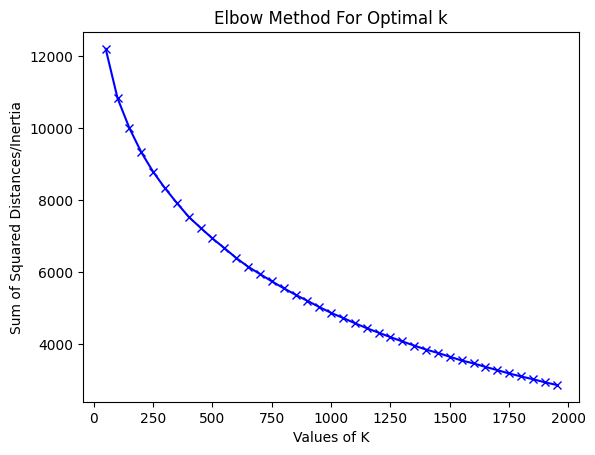

In [141]:
elbow_plot(male_question_vectors_1std)

100%|██████████| 39/39 [40:57<00:00, 63.01s/it] 


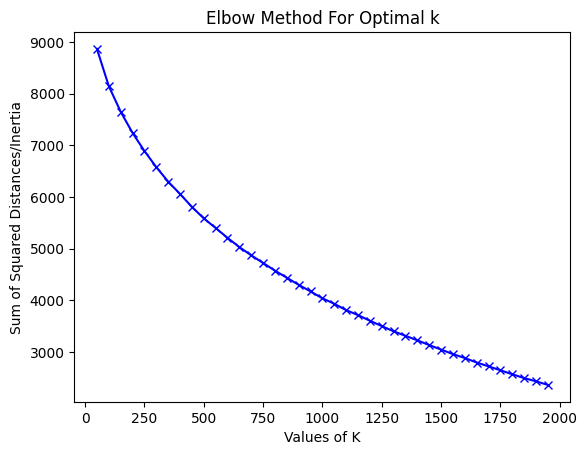

In [142]:
elbow_plot(male_question_vectors_0std)

100%|██████████| 39/39 [10:57<00:00, 16.87s/it]


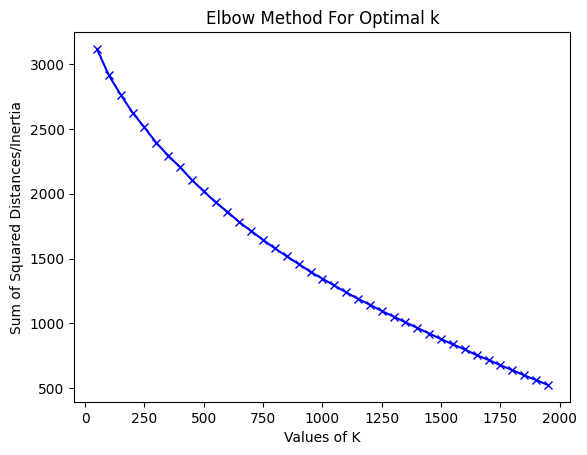

In [143]:
elbow_plot(male_question_vectors_neg_3std)

100%|██████████| 39/39 [45:07<00:00, 69.41s/it] 


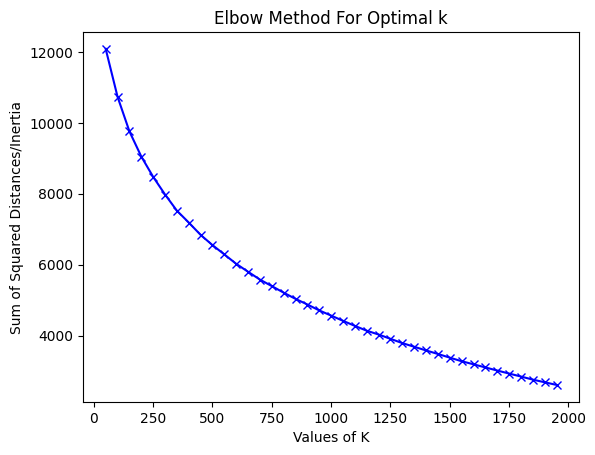

In [144]:
elbow_plot(female_question_vectors_1std)

100%|██████████| 39/39 [28:02<00:00, 43.14s/it]


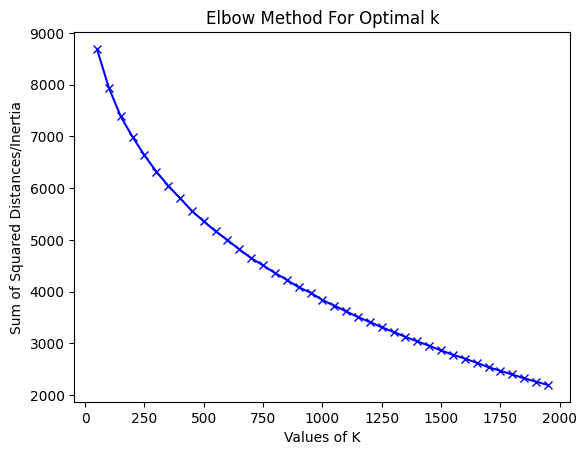

In [145]:
elbow_plot(female_question_vectors_0std)

100%|██████████| 39/39 [10:16<00:00, 15.80s/it]


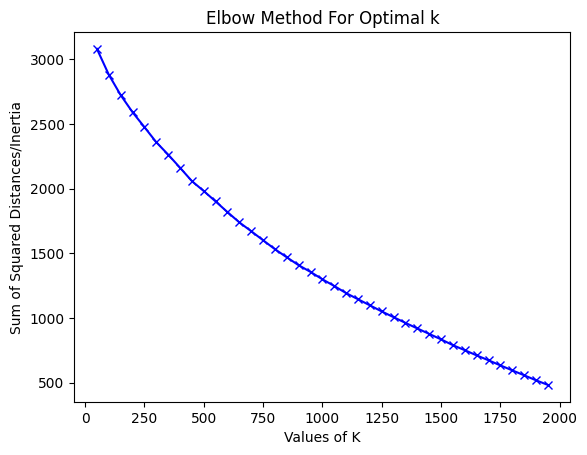

In [146]:
elbow_plot(female_question_vectors_neg_3std)

Get most similar word to each cluster centroid

In [149]:
def get_centroid_similar_word(vector_lst):
    """
    Get the most similar words to each cluster centroid from KMeans clustering.

    This function performs KMeans clustering on the provided list of vectors and 
    retrieves the most similar word for each centroid based on the trained model.

    Args:
        vector_lst (list): A list of vectors to be clustered. Each vector should 
                           represent a word or a term in the embedding space.

    Returns:
        list: A list of the most similar words corresponding to each centroid 
              from the KMeans clustering.
    """
    # Initialize KMeans with specified parameters
    kmeans = KMeans(init='k-means++', n_clusters=1250, random_state=0, n_init=10)
    
    # Fit the KMeans model to the vector list
    kmeans.fit(vector_lst)
    
    # Initialize a list to hold the most similar words for each centroid
    most_similar = []
    
    # Iterate over each centroid to find the most similar word
    for centroid in kmeans.cluster_centers_:
        similar = vectors.most_similar_approx(centroid)[0]  # Get the most similar word
        most_similar.append(similar)  # Append the similar word to the list
    
    return most_similar  # Return the list of most similar words

In [150]:
c_sim_male_1std = get_centroid_similar_word(male_question_vectors_1std)
c_sim_male_0std = get_centroid_similar_word(male_question_vectors_0std)
c_sim_male_neg_3std = get_centroid_similar_word(male_question_vectors_neg_3std)

c_sim_female_1std = get_centroid_similar_word(female_question_vectors_1std)
c_sim_female_0std = get_centroid_similar_word(female_question_vectors_0std)
c_sim_female_neg_3std = get_centroid_similar_word(female_question_vectors_neg_3std)

This function looks for matches between male/female cluster centroids (the word with the most similar vector) and a given set (commentary or GPT generated tennis terms). There are two methods by which it can get matches:

1.) looking at the 10 most similar word vectors to the centroids and checking if any of those are in the comparison list (only one per centroid can be counted)

2.) looking at each word in the comparison list, calculating the cosine similarity score between it and the centroid's most similar word, and checking if this is beyond some passed threshold

In [151]:
def get_per_words_in_lst(male_words, female_words, check_words, type: str, method: str = 'sim_match', threshold: float = 0.5) -> np.ndarray:
    """
    Compares male and female words against a set of check words using specified methods 
    to determine the inclusion of words based on similarity.

    Args:
        male_words (list): A list of tuples containing male words and their counts.
        female_words (list): A list of tuples containing female words and their counts.
        check_words (set): A set of words to check against.
        type (str): A string representing the type of comparison being made.
        method (str, optional): The method to use for comparison. 
                                Options are 'sim_match' for similarity matching 
                                and 'cosine' for cosine similarity. Defaults to 'sim_match'.
        threshold (float, optional): The cosine similarity threshold for inclusion. 
                                      Defaults to 0.5.

    Returns:
        np.ndarray: A 2D numpy array containing the percentages of included words for 
                    males and females, along with their respective types and p-values.
    """
    
    # Initialize counters for male words
    if method == 'sim_match':
        male_included = 0
        male_excluded = 0
        
        # Iterate through male words to check for inclusion
        for word, count in tqdm(male_words):
            if word.lower() in check_words:
                male_included += 1
            else:
                # Get similar words and check for inclusion
                similar_words = [word[0].lower() for word in vectors.most_similar_approx(word)]
                for similar_word in similar_words:
                    if similar_word.lower() in check_words:
                        male_included += 1
                        break
                male_excluded += 1

        # Initialize counters for female words
        female_included = 0
        female_excluded = 0
        
        # Iterate through female words to check for inclusion
        for word, count in tqdm(female_words):
            if word.lower() in check_words:
                female_included += 1
            else:
                # Get similar words and check for inclusion
                similar_words = [word[0].lower() for word in vectors.most_similar_approx(word)]
                for similar_word in similar_words:
                    if similar_word.lower() in check_words:
                        female_included += 1
                        break
                female_excluded += 1

    elif method == 'cosine':
        # Initialize counters for male words
        male_included = 0
        male_excluded = 0
        
        # Iterate through male words to check for cosine similarity
        for word, count in tqdm(male_words):
            for check_word in check_words:
                if vectors.similarity(word.lower(), check_word.lower()) > threshold:
                    male_included += 1
                    break
            male_excluded += 1

        # Initialize counters for female words
        female_included = 0
        female_excluded = 0
        
        # Iterate through female words to check for cosine similarity
        for word, count in tqdm(female_words):
            for check_word in check_words:
                if vectors.similarity(word.lower(), check_word.lower()) > threshold:
                    female_included += 1
                    break
            female_excluded += 1

    # Calculate totals and percentages
    male_total = male_included + male_excluded
    female_total = female_included + female_excluded

    male_p = male_included / male_total
    female_p = female_included / female_total

    p_star = (male_included + female_included) / (male_total + female_total)
    z_stat = (male_p - female_p) / math.sqrt(p_star * (1 - p_star) * ((1 / male_total) + (1 / female_total)))

    # Print statistics
    print("Z-stat:", z_stat)
    p_value = stats.norm.sf(abs(z_stat))
    print("p-value:", p_value)

    print("Male Included Percentage:", male_p)
    print("Female Included Percentage:", female_p)

    print("Percentage of Male Words Included:", male_p)
    print("Percentage of Female Words Included:", female_p)

    # Return results as a numpy array
    return np.array([[round(male_p, 4), 'M', type, round(p_value, 4)],
                     [round(female_p, 4), 'F', type, round(p_value, 4)]])

Compare men's/women's words with the tennis commentary using method 1

In [163]:
print("After Removing Words with Frequency > 1 std:")
c_1std_array = get_per_words_in_lst(
    c_sim_male_1std,
    c_sim_female_1std,
    commentary_words,
    "Centroid 10 Most Similar Words in Commentary\n(word freq < 1 STDs, 0.3747 p-val)",
    method="sim_match",
)
print()
print('--------------------------------------------------')
print()
print("After Removing Words with Frequency > the Mean:")
c_0std_array = get_per_words_in_lst(
    c_sim_male_0std,
    c_sim_female_0std,
    commentary_words,
    "Centroid 10 Most Similar Words in Commentary\n(word freq < 0 STDs, 0.3327 p-val)",
    method="sim_match",
)
print()
print('--------------------------------------------------')
print()
print("After Removing Words with Frequency > -3 std:")
c_neg_3std_array = get_per_words_in_lst(
    c_sim_male_neg_3std,
    c_sim_female_neg_3std,
    commentary_words,
    "Centroid 10 Most Similar Words in Commentary\n(word freq < -3 STDs, 0.1794 p-val)",
    method="sim_match",
)

After Removing Words with Frequency > 1 std:


100%|██████████| 1250/1250 [00:00<00:00, 2839.85it/s]


Z-stat: 0.31936194852693217
p-value: 0.3747260309366175
Male Included Percentage: 0.5768576290414067
Female Included Percentage: 0.5715112912565142
Percentage of Male Words Included: 0.5768576290414067
Percentage of Female Words Included: 0.5715112912565142

--------------------------------------------------

After Removing Words with Frequency > the Mean:


100%|██████████| 1250/1250 [00:00<00:00, 2386.39it/s]


Z-stat: 0.43248013162298593
p-value: 0.33269624474918463
Male Included Percentage: 0.5225274725274726
Female Included Percentage: 0.5153374233128835
Percentage of Male Words Included: 0.5225274725274726
Percentage of Female Words Included: 0.5153374233128835

--------------------------------------------------

After Removing Words with Frequency > -3 std:


100%|██████████| 1250/1250 [00:00<00:00, 1586.13it/s]

Z-stat: 0.9176977366036806
p-value: 0.17938856648555918
Male Included Percentage: 0.3658395845354876
Female Included Percentage: 0.3508464681844717
Percentage of Male Words Included: 0.3658395845354876
Percentage of Female Words Included: 0.3508464681844717


Compare men's/women's words with the GPT generated tennis terms using method 2

In [164]:
print("After Removing Words with Frequency > 1 std:")
tw_1std_array = get_per_words_in_lst(
    c_sim_male_1std,
    c_sim_female_1std,
    tennis_related_words,
    "Centroid Cosine-Sim w/ GPT Tennis Words\n(word freq < 1 STDs, 0.3 threshold, 0.3383 p-val)",
    method="cosine",
    threshold=0.3,
)
print()
print('--------------------------------------------------')
print()
print("After Removing Words with Frequency > the Mean:")
tw_0std_array = get_per_words_in_lst(
    c_sim_male_0std,
    c_sim_female_0std,
    tennis_related_words,
    "Centroid Cosine-Sim w/ GPT Tennis Words\n(word freq < 0 STDs, 0.3 threshold, 0.3236 p-val)",
    method="cosine",
    threshold=0.3,
)
print()
print('--------------------------------------------------')
print()
print("After Removing Words with Frequency > -3 std:")
tw_neg_3std_array = get_per_words_in_lst(
    c_sim_male_neg_3std,
    c_sim_female_neg_3std,
    tennis_related_words,
    "Centroid Cosine-Sim w/ GPT Tennis Words\n(word freq < -3 STDs, 0.3 threshold, 0.1093 p-val)",
    method="cosine",
    threshold=0.3,
)

After Removing Words with Frequency > 1 std:


100%|██████████| 1250/1250 [00:02<00:00, 433.67it/s]


Z-stat: 0.4171485909975608
p-value: 0.3382848626115129
Male Included Percentage: 0.4186046511627907
Female Included Percentage: 0.4123178185237424
Percentage of Male Words Included: 0.4186046511627907
Percentage of Female Words Included: 0.4123178185237424

--------------------------------------------------

After Removing Words with Frequency > the Mean:


100%|██████████| 1250/1250 [00:04<00:00, 275.28it/s]


Z-stat: 0.4575704917020388
p-value: 0.32363052373490525
Male Included Percentage: 0.3872549019607843
Female Included Percentage: 0.3802677243430838
Percentage of Male Words Included: 0.3872549019607843
Percentage of Female Words Included: 0.3802677243430838

--------------------------------------------------

After Removing Words with Frequency > -3 std:


100%|██████████| 1250/1250 [00:04<00:00, 251.15it/s]

Z-stat: 1.2304006865415202
p-value: 0.10927354819976853
Male Included Percentage: 0.25903971547125076
Female Included Percentage: 0.24058323207776428
Percentage of Male Words Included: 0.25903971547125076
Percentage of Female Words Included: 0.24058323207776428


Visualize the results

The p-values in the graph below need to be updated...

The above graph uses the following criteria of comparison:

- Centroid 10 Most Similar Words in Commentary
    - For each cluster centroid, we compare the ten most similar words via embeddings and check if any are included in the commentary data. If at least one of the ten most similar words appears in the commentary data, we increment the success count by 1. If more than one of the ten words appears in the commentary, we do not increment the success count further. If every centroid has all ten nearest words in the commentary data, the percentage will max out at 100%.

- Centroid Cosine-Similarity with GPT Tennis Words
    - For each cluster centroid, we compare its cosine similarity score with each GPT-generated tennis term. If at least one of the GPT-generated tennis terms produces a similarity score above the threshold, then we increment the success count by 1. If more than one GPT-generated tennis word appears in the commentary, we do not increment the success count further. This way, if every centroid produces multiple cosine similarity scores above the threshold with the GPT words, the percentage will max out at 100%.
- Appearing in Tennis Commentary
    - The percentage of the question words that appear in the tennis commentary

Guide to the graph terms:
- word freq: shows which words are being considered (e.g., word freq < 0 STDs only include the bottom half of the frequency distribution)
- clusters: number of clusters used to group the embeddings
- p-value: p-value from two-sample z-test for proportions

Table used to produce the above graph:

In [171]:
tw_1std_array

array([['0.4186', 'M',
        'Centroid Cosine-Sim w/ GPT Tennis Words\n(word freq < 1 STDs, 0.3 threshold, 0.3383 p-val)',
        '0.3383'],
       ['0.4123', 'F',
        'Centroid Cosine-Sim w/ GPT Tennis Words\n(word freq < 1 STDs, 0.3 threshold, 0.3383 p-val)',
        '0.3383']], dtype='<U89')

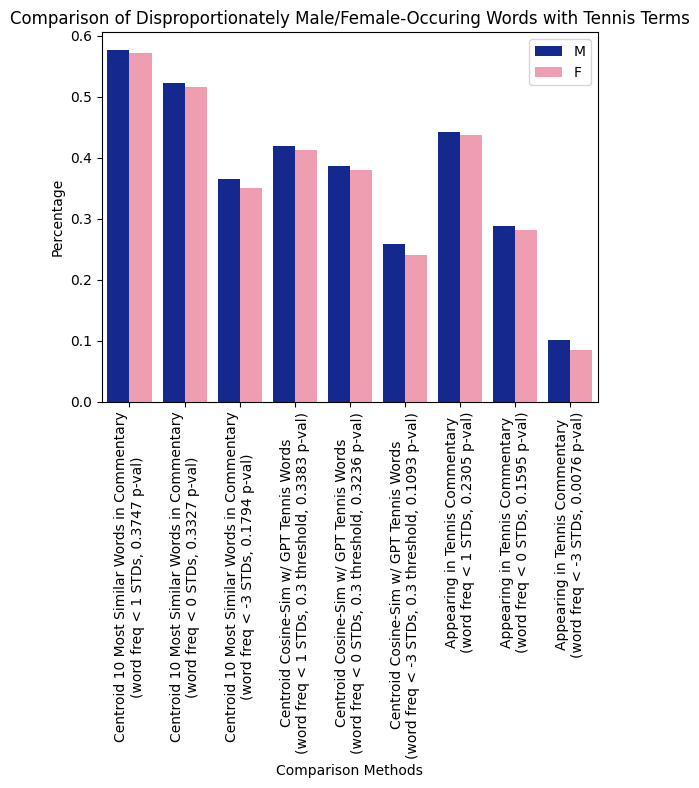

In [201]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming combined_array is already defined
combined_array = np.concatenate(
    (
        c_1std_array,
        c_0std_array,
        c_neg_3std_array,
        tw_1std_array,
        tw_0std_array,
        tw_neg_3std_array,
        bl_tc_1std_array,
        bl_tc_0std_array,
        bl_tc_neg_3std_array,
    ),
    axis=0,
)

vector_results_df = pd.DataFrame(
    combined_array, columns=["Percentage", "Gender", "Comparison Set", "P-Value"]
)
vector_results_df["Percentage"] = vector_results_df["Percentage"].astype(float)

# Create the plot with specific parameters
ax = sns.barplot(
    data=vector_results_df, x="Comparison Set", y="Percentage", hue="Gender", dodge=True
)

# Get the unique comparison sets
comparison_sets = vector_results_df["Comparison Set"].unique()

# Get the container of bars
containers = ax.containers

# Calculate the middle position between each pair of bars
tick_positions = []
for i in range(len(comparison_sets)):
    # Get the middle position between each pair of bars
    middle = (containers[0][i].get_x() + containers[1][i].get_x() + containers[1][i].get_width()) / 2
    tick_positions.append(middle)

# Set the tick positions and labels
plt.xticks(ticks=tick_positions, labels=comparison_sets, rotation=90, ha="center")

# Create custom colors array
colors = ["#001ba1", "#fc90ab"]
# Set custom color palette
sns.set_palette(sns.color_palette(colors))

# Adding labels and title
plt.xlabel("Comparison Methods")
plt.title(
    "Comparison of Disproportionately Male/Female-Occuring Words with Tennis Terms"
)

# Adding a legend
plt.legend()

# Display the plot
plt.show()

In [202]:
vector_results_df

,Percentage,Gender,Comparison Set,P-Value
0,0.5769,M,Centroid 10 Most Similar Words in Commentary\n...,0.3747
1,0.5715,F,Centroid 10 Most Similar Words in Commentary\n...,0.3747
2,0.5225,M,Centroid 10 Most Similar Words in Commentary\n...,0.3327
3,0.5153,F,Centroid 10 Most Similar Words in Commentary\n...,0.3327
4,0.3658,M,Centroid 10 Most Similar Words in Commentary\n...,0.1794
5,0.3508,F,Centroid 10 Most Similar Words in Commentary\n...,0.1794
6,0.4186,M,Centroid Cosine-Sim w/ GPT Tennis Words\n(word...,0.3383
7,0.4123,F,Centroid Cosine-Sim w/ GPT Tennis Words\n(word...,0.3383
8,0.3873,M,Centroid Cosine-Sim w/ GPT Tennis Words\n(word...,0.3236
9,0.3803,F,Centroid Cosine-Sim w/ GPT Tennis Words\n(word...,0.3236
